# Step 1 — Project Setup and Dataset Download

# Rainfall Time Series Forecasting

## Business Case

Develop a Machine Learning model to predict rainfall for the next one year
using historical rainfall data. The project also aims to forecast the
highest rainfall occurring in a day for a single month.

## Project Goals

1. Perform comprehensive data understanding and preprocessing.
2. Analyze temporal patterns such as trend and seasonality.
3. Develop forecasting models for future rainfall.
4. Forecast rainfall for the next one year.
5. Analyze and forecast the highest daily rainfall for a selected month.
6. Compare multiple forecasting models.
7. Evaluate model performance using appropriate forecasting metrics.
8. Perform residual and error analysis.
9. Prevent temporal data leakage throughout the workflow.

# Step 1.1 — Import the Basic Libraries

In [ ]:

import os
import zipfile
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

print("Basic libraries imported successfully.")

Basic libraries imported successfully.



os will help us inspect folders and files.

zipfile will extract the downloaded rainfall dataset.

Pandas and NumPy were used for data manipulation and numerical computation, while Matplotlib and Seaborn were used for exploratory data visualization.

Python's OS and ZIP utilities were used to programmatically manage and extract the supplied dataset, supporting an end-to-end reproducible workflow.

#Step 1.2 — Set Reproducibility and Plot Settings

In [ ]:


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

print("Random state:", RANDOM_STATE)
print("Plot settings configured.")

Random state: 42
Plot settings configured.


#

I used a fixed random seed to improve reproducibility, so stochastic operations can produce consistent results across repeated runs. The value 42 itself is arbitrary; consistency is what matters. However, because rainfall forecasting is a time-series problem, I did not use random shuffling for the train-test split. The temporal order must be preserved to prevent future information from leaking into training.

# Step 1.3 — Download the Rainfall Dataset

In [ ]:

dataset_url = "https://d3ilbtxij3aepc.cloudfront.net/projects/AI-Capstone-Projects/PRAICP-1004-RainfallTS.zip"

zip_path = "/content/PRAICP-1004-RainfallTS.zip"

!wget -q "$dataset_url" -O "$zip_path"

print("Dataset downloaded successfully.")
print("ZIP file path:", zip_path)

Dataset downloaded successfully.
ZIP file path: /content/PRAICP-1004-RainfallTS.zip


# Step 1.4 — Verifying That the ZIP Actually Downloaded

In [ ]:

if os.path.exists(zip_path):
    file_size_mb = os.path.getsize(zip_path) / (1024 * 1024)

    print("ZIP file exists: True")
    print(f"ZIP file size: {file_size_mb:.2f} MB")
else:
    print("ZIP file was not found.")

ZIP file exists: True
ZIP file size: 0.01 MB


# VERIFY ZIP FILE INTEGRITY

In [ ]:


print("Is it a valid ZIP file?:", zipfile.is_zipfile(zip_path))

file_size_bytes = os.path.getsize(zip_path)
print("Exact file size (bytes):", file_size_bytes)
print(f"Exact file size (KB): {file_size_bytes / 1024:.2f}")

Is it a valid ZIP file?: True
Exact file size (bytes): 9351
Exact file size (KB): 9.13


Actually checks whether Python recognizes the downloaded file as a valid ZIP archive.

# Step 1.5 — Extract the Rainfall Dataset

In [ ]:

extract_path = "/content/RainfallTS"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")
print("Extraction path:", extract_path)

Dataset extracted successfully.
Extraction path: /content/RainfallTS


# Step 1.6 — Inspect the Extracted Directory Structure

In [ ]:

for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, "").count(os.sep)
    indent = "    " * level

    print(f"{indent}{os.path.basename(root)}/")

    subindent = "    " * (level + 1)

    for file in files:
        print(f"{subindent}{file}")

RainfallTS/
    Data/
        rainfall-monthly-total.csv
        rainfall-monthly-highest-daily-total.csv
        rainfall-monthly-number-of-rain-days.csv
        metadata-rainfall-monthly-number-of-rain-days.txt
        metadata-rainfall-monthly-total.txt
        metadata-rainfall-monthly-maximum-daily-total.txt


## Dataset Acquisition and Directory Inspection

The rainfall dataset was downloaded and extracted programmatically in Google Colab to ensure reproducibility. The downloaded ZIP file was verified as valid before extraction.

Directory inspection identified three rainfall datasets along with their corresponding metadata files:

* Monthly total rainfall
* Monthly highest daily rainfall
* Monthly number of rain days

The metadata files will be examined before further analysis to correctly understand the variables, units, and dataset structure. No preprocessing or modeling was performed at this stage.


# Step 2 — Read the Metadata Files

In [ ]:

data_path = os.path.join(extract_path, "Data")

print("Data directory:", data_path)
print("Directory exists:", os.path.exists(data_path))

Data directory: /content/RainfallTS/Data
Directory exists: True


# Step 2.2 — Identify the Metadata Files

In [ ]:

metadata_files = [
    file for file in os.listdir(data_path)
    if file.endswith(".txt")
]

print("Number of metadata files:", len(metadata_files))

for file in metadata_files:
    print(file)

Number of metadata files: 3
metadata-rainfall-monthly-number-of-rain-days.txt
metadata-rainfall-monthly-total.txt
metadata-rainfall-monthly-maximum-daily-total.txt


# Step 2.3 — Read the Metadata Contents

In [ ]:

for file in metadata_files:

    file_path = os.path.join(data_path, file)

    print("=" * 70)
    print("METADATA FILE:", file)
    print("=" * 70)

    with open(file_path, "r", encoding="utf-8") as f:
        content = f.read()

    print(content)
    print()

METADATA FILE: metadata-rainfall-monthly-number-of-rain-days.txt
# Metadata for Rainfall - Monthly Number of Rain Days
---
Identifier: 'f0b330c4-18c5-4d8e-ba95-7c7739297bd2'
Name: 'rainfall-monthly-number-of-rain-days'
Title: 'Rainfall - Monthly Number of Rain Days'
Description: 'The number of rain days (day with rainfall amount of 0.2mm or more)
  in a month recorded at the Changi Climate Station.'
Topics:
  - 'Environment'
Keywords:
  - 'Climate'
  - 'NEA'
  - 'Precipitation'
  - 'Rainfall'
  - 'Weather'
Publisher:
  Name: 'National Environment Agency'
  Admin 1:
    Name: 'Ong Chin Hong'
    Department: 'CCRS'
    Email: 'ong_chin_hong@nea.gov.sg'
  Admin 2:
    Name: 'Ang Chieng Hai'
    Department: 'CCRS'
    Email: 'ang_chieng_hai@nea.gov.sg'
Sources:
  - 'National Environment Agency'
License: 'https://data.gov.sg/open-data-licence'
Frequency: 'Monthly'
Coverage: '1982-01-01 to 2020-06-30'
Last Updated: '2020-07-21T02:20:59.773063'
Resources:
  -
    Identifier: '8b94f596-91fd-45

# ## Metadata Understanding

The metadata confirms that all three datasets contain monthly rainfall observations recorded at the Changi Climate Station from January 1982 to June 2020.

The available variables are:

* **Monthly Total Rainfall (`total_rainfall`)** — total rainfall accumulated during the month, measured in millimetres.
* **Highest Daily Rainfall (`maximum_rainfall_in_a_day`)** — the maximum rainfall recorded in a single day within each month, measured in millimetres.
* **Number of Rainy Days (`no_of_rainy_days`)** — number of days in the month with rainfall of at least 0.2 mm.

Since the data frequency is monthly, the one-year forecasting objective will likely involve predicting the next 12 monthly observations. The highest-daily-rainfall dataset directly supports the second business objective.


# Step 3 — Load and Inspect the Three CSV Files

In [ ]:
# ============================================
# STEP 3.1: DEFINE CSV FILE PATHS
# ============================================

total_rainfall_file = os.path.join(
    data_path,
    "rainfall-monthly-total.csv"
)

max_daily_rainfall_file = os.path.join(
    data_path,
    "rainfall-monthly-highest-daily-total.csv"
)

rainy_days_file = os.path.join(
    data_path,
    "rainfall-monthly-number-of-rain-days.csv"
)

print("CSV file paths defined successfully.")

CSV file paths defined successfully.


In [ ]:
# ============================================
# STEP 3.2: LOAD CSV DATASETS
# ============================================

df_total = pd.read_csv(total_rainfall_file)

df_max_daily = pd.read_csv(max_daily_rainfall_file)

df_rainy_days = pd.read_csv(rainy_days_file)

print("All three datasets loaded successfully.")

All three datasets loaded successfully.


In [ ]:
# ============================================
# STEP 3.3: CHECK DATASET SHAPES
# ============================================

print("Monthly Total Rainfall shape:", df_total.shape)
print("Highest Daily Rainfall shape:", df_max_daily.shape)
print("Number of Rainy Days shape:", df_rainy_days.shape)

Monthly Total Rainfall shape: (462, 2)
Highest Daily Rainfall shape: (462, 2)
Number of Rainy Days shape: (462, 2)


In [ ]:
# ============================================
# STEP 3.4: CHECK COLUMN NAMES
# ============================================

print("Monthly Total Rainfall columns:")
print(df_total.columns.tolist())

print("\nHighest Daily Rainfall columns:")
print(df_max_daily.columns.tolist())

print("\nNumber of Rainy Days columns:")
print(df_rainy_days.columns.tolist())

Monthly Total Rainfall columns:
['month', 'total_rainfall']

Highest Daily Rainfall columns:
['month', 'maximum_rainfall_in_a_day']

Number of Rainy Days columns:
['month', 'no_of_rainy_days']


In [ ]:
# ============================================
# STEP 3.5: DISPLAY FIRST FIVE ROWS
# ============================================

print("Monthly Total Rainfall:")
display(df_total.head())

print("\nHighest Daily Rainfall:")
display(df_max_daily.head())

print("\nNumber of Rainy Days:")
display(df_rainy_days.head())

Monthly Total Rainfall:


,month,total_rainfall
0,1982-01,107.1
1,1982-02,27.8
2,1982-03,160.8
3,1982-04,157.0
4,1982-05,102.2



Highest Daily Rainfall:


,month,maximum_rainfall_in_a_day
0,1982-01,36.5
1,1982-02,9.4
2,1982-03,61.7
3,1982-04,45.1
4,1982-05,33.0



Number of Rainy Days:


,month,no_of_rainy_days
0,1982-01,10
1,1982-02,5
2,1982-03,11
3,1982-04,14
4,1982-05,10


In [ ]:
# ============================================
# STEP 3.6: DISPLAY LAST FIVE ROWS
# ============================================

print("Monthly Total Rainfall:")
display(df_total.tail())

print("\nHighest Daily Rainfall:")
display(df_max_daily.tail())

print("\nNumber of Rainy Days:")
display(df_rainy_days.tail())

Monthly Total Rainfall:


,month,total_rainfall
457,2020-02,65.0
458,2020-03,108.8
459,2020-04,188.0
460,2020-05,255.6
461,2020-06,233.8



Highest Daily Rainfall:


,month,maximum_rainfall_in_a_day
457,2020-02,23.8
458,2020-03,47.4
459,2020-04,51.8
460,2020-05,53.8
461,2020-06,41.0



Number of Rainy Days:


,month,no_of_rainy_days
457,2020-02,8
458,2020-03,8
459,2020-04,12
460,2020-05,16
461,2020-06,21


In [ ]:
# ============================================
# STEP 3.7: CHECK DATA TYPES
# ============================================

print("Monthly Total Rainfall data types:")
print(df_total.dtypes)

print("\nHighest Daily Rainfall data types:")
print(df_max_daily.dtypes)

print("\nNumber of Rainy Days data types:")
print(df_rainy_days.dtypes)

Monthly Total Rainfall data types:
month              object
total_rainfall    float64
dtype: object

Highest Daily Rainfall data types:
month                         object
maximum_rainfall_in_a_day    float64
dtype: object

Number of Rainy Days data types:
month               object
no_of_rainy_days     int64
dtype: object


In [ ]:
# ============================================
# STEP 3.8: DATASET INFORMATION
# ============================================

print("MONTHLY TOTAL RAINFALL")
df_total.info()

print("\nHIGHEST DAILY RAINFALL")
df_max_daily.info()

print("\nNUMBER OF RAINY DAYS")
df_rainy_days.info()

MONTHLY TOTAL RAINFALL
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 462 entries, 0 to 461
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   month           462 non-null    object 
 1   total_rainfall  462 non-null    float64
dtypes: float64(1), object(1)
memory usage: 7.3+ KB

HIGHEST DAILY RAINFALL
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 462 entries, 0 to 461
Data columns (total 2 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   month                      462 non-null    object 
 1   maximum_rainfall_in_a_day  462 non-null    float64
dtypes: float64(1), object(1)
memory usage: 7.3+ KB

NUMBER OF RAINY DAYS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 462 entries, 0 to 461
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   month         

In [ ]:
# ============================================
# STEP 3.9: CHECK FIRST AND LAST MONTH
# ============================================

datasets = {
    "Monthly Total Rainfall": df_total,
    "Highest Daily Rainfall": df_max_daily,
    "Number of Rainy Days": df_rainy_days
}

for name, df in datasets.items():
    print(name)
    print("First month:", df["month"].iloc[0])
    print("Last month :", df["month"].iloc[-1])
    print("-" * 50)

Monthly Total Rainfall
First month: 1982-01
Last month : 2020-06
--------------------------------------------------
Highest Daily Rainfall
First month: 1982-01
Last month : 2020-06
--------------------------------------------------
Number of Rainy Days
First month: 1982-01
Last month : 2020-06
--------------------------------------------------


## Initial Dataset Inspection

All three rainfall datasets contain 462 monthly observations covering January 1982 to June 2020. Each dataset contains a common `month` column and one rainfall-related variable.

The rainfall variables are already numeric, while the `month` column is currently stored as an object and will later be converted to datetime format. Initial inspection shows no missing values, and all three datasets share the same record count and time coverage. Exact temporal alignment will be verified before combining the datasets.


# Step 4 — Data Quality Audit

In [ ]:
# ============================================
# STEP 4.1: CHECK MISSING VALUES
# ============================================

print("Monthly Total Rainfall:")
print(df_total.isnull().sum())

print("\nHighest Daily Rainfall:")
print(df_max_daily.isnull().sum())

print("\nNumber of Rainy Days:")
print(df_rainy_days.isnull().sum())

Monthly Total Rainfall:
month             0
total_rainfall    0
dtype: int64

Highest Daily Rainfall:
month                        0
maximum_rainfall_in_a_day    0
dtype: int64

Number of Rainy Days:
month               0
no_of_rainy_days    0
dtype: int64


### Missing Value Analysis

Missing values were checked in all three rainfall datasets. No missing values were found in the `month`, `total_rainfall`, `maximum_rainfall_in_a_day`, or `no_of_rainy_days` columns. Therefore, no missing-value imputation or row removal is required.


In [ ]:
# ============================================
# STEP 4.2: CHECK DUPLICATE ROWS
# ============================================

print("Duplicate rows in Monthly Total Rainfall:",
      df_total.duplicated().sum())

print("Duplicate rows in Highest Daily Rainfall:",
      df_max_daily.duplicated().sum())

print("Duplicate rows in Number of Rainy Days:",
      df_rainy_days.duplicated().sum())

Duplicate rows in Monthly Total Rainfall: 0
Duplicate rows in Highest Daily Rainfall: 0
Duplicate rows in Number of Rainy Days: 0


### Duplicate Row Analysis

No duplicate rows were identified in any of the three rainfall datasets. Therefore, all 462 observations in each dataset were retained without duplicate removal.


In [ ]:
# ============================================
# STEP 4.3: CHECK DUPLICATE MONTHS
# ============================================

print("Duplicate months in Monthly Total Rainfall:",
      df_total["month"].duplicated().sum())

print("Duplicate months in Highest Daily Rainfall:",
      df_max_daily["month"].duplicated().sum())

print("Duplicate months in Number of Rainy Days:",
      df_rainy_days["month"].duplicated().sum())

Duplicate months in Monthly Total Rainfall: 0
Duplicate months in Highest Daily Rainfall: 0
Duplicate months in Number of Rainy Days: 0


### Duplicate Month Analysis

No duplicate months were found in any of the three datasets. Each month therefore has a single observation, confirming that there are no repeated timestamps requiring removal.


In [ ]:
# ============================================
# STEP 4.4: CHECK NEGATIVE VALUES
# ============================================

print("Negative total rainfall values:",
      (df_total["total_rainfall"] < 0).sum())

print("Negative maximum daily rainfall values:",
      (df_max_daily["maximum_rainfall_in_a_day"] < 0).sum())

print("Negative rainy-day values:",
      (df_rainy_days["no_of_rainy_days"] < 0).sum())

Negative total rainfall values: 0
Negative maximum daily rainfall values: 0
Negative rainy-day values: 0


### Negative Value Check

No negative values were detected in monthly total rainfall, maximum daily rainfall, or number of rainy days. All observations therefore satisfy the basic physical validity requirement for rainfall data.


In [ ]:
# ============================================
# STEP 4.5: CHECK RAINY-DAY RANGE
# ============================================

print("Minimum number of rainy days:",
      df_rainy_days["no_of_rainy_days"].min())

print("Maximum number of rainy days:",
      df_rainy_days["no_of_rainy_days"].max())

print("Values greater than 31 days:",
      (df_rainy_days["no_of_rainy_days"] > 31).sum())

Minimum number of rainy days: 1
Maximum number of rainy days: 27
Values greater than 31 days: 0


### Rainy-Day Range Validation

The number of rainy days ranged from 1 to 27 days per month, with no observations exceeding 31 days. The values are therefore within a plausible monthly range, with no obvious invalid rainy-day counts detected.


In [ ]:
# ============================================
# STEP 4.6: CREATE AUDIT COPIES AND CONVERT MONTH
# ============================================

df_total_check = df_total.copy()
df_max_daily_check = df_max_daily.copy()
df_rainy_days_check = df_rainy_days.copy()

df_total_check["month"] = pd.to_datetime(
    df_total_check["month"],
    format="%Y-%m"
)

df_max_daily_check["month"] = pd.to_datetime(
    df_max_daily_check["month"],
    format="%Y-%m"
)

df_rainy_days_check["month"] = pd.to_datetime(
    df_rainy_days_check["month"],
    format="%Y-%m"
)

print("Month columns converted successfully for audit.")

Month columns converted successfully for audit.


### Datetime Conversion for Audit

Copies of the three datasets were created, and their `month` columns were converted from object format to datetime format. This enables reliable chronological ordering, temporal alignment, and missing-month checks while preserving the original raw datasets.


In [ ]:
# ============================================
# STEP 4.7: CHECK CHRONOLOGICAL ORDER
# ============================================

print("Monthly Total Rainfall sorted:",
      df_total_check["month"].is_monotonic_increasing)

print("Highest Daily Rainfall sorted:",
      df_max_daily_check["month"].is_monotonic_increasing)

print("Number of Rainy Days sorted:",
      df_rainy_days_check["month"].is_monotonic_increasing)

Monthly Total Rainfall sorted: True
Highest Daily Rainfall sorted: True
Number of Rainy Days sorted: True


### Chronological Order Check

All three datasets were confirmed to be sorted in increasing chronological order. This ensures that the temporal sequence is preserved for subsequent time-series analysis and forecasting.


In [ ]:
# ============================================
# STEP 4.8: VERIFY MONTH-BY-MONTH ALIGNMENT
# ============================================

alignment_total_max = df_total_check["month"].equals(
    df_max_daily_check["month"]
)

alignment_total_days = df_total_check["month"].equals(
    df_rainy_days_check["month"]
)

print("Total rainfall vs highest daily rainfall aligned:",
      alignment_total_max)

print("Total rainfall vs rainy days aligned:",
      alignment_total_days)

Total rainfall vs highest daily rainfall aligned: True
Total rainfall vs rainy days aligned: True


### Temporal Alignment Check

The month values were found to be exactly aligned across all three rainfall datasets. This confirms that corresponding rows represent the same monthly periods and supports reliable integration of the datasets after completion of the remaining temporal quality checks.


In [ ]:
# ============================================
# STEP 4.9: CHECK FOR MISSING MONTHS
# ============================================

expected_months = pd.date_range(
    start=df_total_check["month"].min(),
    end=df_total_check["month"].max(),
    freq="MS"
)

actual_months = pd.DatetimeIndex(df_total_check["month"])

missing_months = expected_months.difference(actual_months)

print("Expected number of monthly observations:",
      len(expected_months))

print("Actual number of observations:",
      len(actual_months))

print("Number of missing months:",
      len(missing_months))

if len(missing_months) > 0:
    print("\nMissing months:")
    print(missing_months)
else:
    print("No monthly gaps detected.")

Expected number of monthly observations: 462
Actual number of observations: 462
Number of missing months: 0
No monthly gaps detected.


### Temporal Gap Analysis

The expected and actual number of monthly observations were both 462, with no missing months detected between January 1982 and June 2020. The time series is therefore continuous and free from temporal gaps.


# Step 5 — Merge the Three Rainfall Datasets

In [ ]:
# ============================================
# STEP 5.1: MERGE THE THREE DATASETS
# ============================================

df_merged = (
    df_total_check
    .merge(
        df_max_daily_check,
        on="month",
        how="inner"
    )
    .merge(
        df_rainy_days_check,
        on="month",
        how="inner"
    )
)

print("Datasets merged successfully.")
print("Merged dataset shape:", df_merged.shape)

Datasets merged successfully.
Merged dataset shape: (462, 4)


### Dataset Integration

The three rainfall datasets were successfully merged using the common `month` field. The resulting dataset contains 462 monthly observations and four columns, confirming that all records were preserved during integration.


In [ ]:
# ============================================
# STEP 5.2: INSPECT MERGED DATASET
# ============================================

display(df_merged.head())

print("\nLast five rows:")
display(df_merged.tail())

,month,total_rainfall,maximum_rainfall_in_a_day,no_of_rainy_days
0,1982-01-01,107.1,36.5,10
1,1982-02-01,27.8,9.4,5
2,1982-03-01,160.8,61.7,11
3,1982-04-01,157.0,45.1,14
4,1982-05-01,102.2,33.0,10



Last five rows:


,month,total_rainfall,maximum_rainfall_in_a_day,no_of_rainy_days
457,2020-02-01,65.0,23.8,8
458,2020-03-01,108.8,47.4,8
459,2020-04-01,188.0,51.8,12
460,2020-05-01,255.6,53.8,16
461,2020-06-01,233.8,41.0,21


### Merged Dataset Inspection

Inspection of the first and last records confirmed that the three rainfall variables were correctly aligned within the merged dataset. The series begins in January 1982 and ends in June 2020, consistent with the source metadata. The datetime representation uses the first day of each month while retaining the original monthly frequency.


In [ ]:
# ============================================
# STEP 5.3: CHECK SHAPE AND COLUMNS
# ============================================

print("Merged dataset shape:", df_merged.shape)

print("\nMerged dataset columns:")
print(df_merged.columns.tolist())

Merged dataset shape: (462, 4)

Merged dataset columns:
['month', 'total_rainfall', 'maximum_rainfall_in_a_day', 'no_of_rainy_days']


### Merged Dataset Structure

The merged dataset contains 462 monthly observations and four columns: `month`, `total_rainfall`, `maximum_rainfall_in_a_day`, and `no_of_rainy_days`. This confirms that the three rainfall variables were successfully integrated into a single time-series dataset.


In [ ]:
# ============================================
# STEP 5.4: CHECK MERGED DATA TYPES
# ============================================

print(df_merged.dtypes)

month                        datetime64[ns]
total_rainfall                      float64
maximum_rainfall_in_a_day           float64
no_of_rainy_days                      int64
dtype: object


### Data Type Verification

The `month` variable is stored in datetime format, while total rainfall and maximum daily rainfall are continuous numerical variables (`float64`) and the number of rainy days is an integer count (`int64`). The data types are appropriate for subsequent time-series analysis.


In [ ]:
# ============================================
# STEP 5.5: VALIDATE MERGED DATASET
# ============================================

print("Number of rows:", len(df_merged))

print("Missing values:")
print(df_merged.isnull().sum())

print("\nDuplicate months:",
      df_merged["month"].duplicated().sum())

print("\nChronologically sorted:",
      df_merged["month"].is_monotonic_increasing)

print("\nFirst month:", df_merged["month"].min())
print("Last month :", df_merged["month"].max())

Number of rows: 462
Missing values:
month                        0
total_rainfall               0
maximum_rainfall_in_a_day    0
no_of_rainy_days             0
dtype: int64

Duplicate months: 0

Chronologically sorted: True

First month: 1982-01-01 00:00:00
Last month : 2020-06-01 00:00:00


### Post-Merge Validation

Post-merge validation confirmed that all 462 monthly observations were preserved with no missing values or duplicate months. The dataset remains chronologically ordered and covers January 1982 to June 2020, confirming successful and reliable data integration.


# Step 5.6 — Rename Columns for Cleaner Analysis? Not Needed

####   Column Naming: The original column names were retained because they are clear, descriptive, and consistent with the source metadata. No column renaming was required.

In [ ]:
# ============================================
# STEP 5.7: CREATE TIME-SERIES INDEXED COPY
# ============================================

df_ts = df_merged.copy()

df_ts = df_ts.set_index("month")

print("Time-series indexed dataset created.")
print("Index type:", type(df_ts.index))

display(df_ts.head())

Time-series indexed dataset created.
Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


,total_rainfall,maximum_rainfall_in_a_day,no_of_rainy_days
month,,,
1982-01-01,107.1,36.5,10
1982-02-01,27.8,9.4,5
1982-03-01,160.8,61.7,11
1982-04-01,157.0,45.1,14
1982-05-01,102.2,33.0,10


### Time-Series Index Creation

A time-series copy of the merged dataset was created by setting `month` as a `DatetimeIndex`. This prepares the data for chronological analysis, temporal visualization, rolling statistics, lag analysis, and forecasting while retaining the original merged dataset separately.


# Step 6 — Descriptive Statistics and Exploratory Data Analysis

In [ ]:
# ============================================
# STEP 6.1: DESCRIPTIVE STATISTICS
# ============================================

descriptive_stats = df_ts.describe().T

display(descriptive_stats)

,count,mean,std,min,25%,50%,75%,max
total_rainfall,462.0,176.236580,113.296793,0.2,89.025,158.45,237.95,765.9
maximum_rainfall_in_a_day,462.0,52.358225,35.685122,0.2,30.625,43.45,63.15,216.2
no_of_rainy_days,462.0,13.958874,4.947494,1.0,11.000,14.00,18.00,27.0


### Descriptive Statistics

Descriptive statistics were calculated for the three rainfall variables across 462 monthly observations. Monthly total rainfall had a mean of 176.24 mm and a median of 158.45 mm, with values ranging from 0.2 mm to 765.9 mm. The relatively high standard deviation of 113.30 mm indicates substantial variability in monthly rainfall.

The maximum rainfall recorded in a single day had a mean of 52.36 mm and a median of 43.45 mm, ranging from 0.2 mm to 216.2 mm. For both rainfall variables, the mean was higher than the median, providing an initial indication of possible positive skewness caused by high-rainfall events.

The average number of rainy days was approximately 13.96 days per month, with a median of 14 days and a range of 1 to 27 days. The similarity between its mean and median suggests a comparatively more balanced distribution.

Overall, the descriptive statistics indicate substantial variation in rainfall intensity and the presence of potentially extreme rainfall observations, which will be investigated further through distribution and time-series analysis.


In [ ]:
# ============================================
# STEP 6.2: ADDITIONAL DESCRIPTIVE STATISTICS
# ============================================

additional_stats = pd.DataFrame({
    "Median": df_ts.median(),
    "Variance": df_ts.var(),
    "Skewness": df_ts.skew(),
    "Kurtosis": df_ts.kurt()
})

display(additional_stats.round(3))

,Median,Variance,Skewness,Kurtosis
total_rainfall,158.45,12836.163,1.237,2.353
maximum_rainfall_in_a_day,43.45,1273.428,1.862,4.350
no_of_rainy_days,14.00,24.478,-0.152,-0.472


### Additional Distribution Statistics

Additional descriptive statistics were calculated to examine variability and distribution shape. Monthly total rainfall showed positive skewness (1.237) and positive kurtosis (2.353), indicating a right-skewed distribution with some extreme high-rainfall observations.

Maximum daily rainfall showed stronger positive skewness (1.862) and higher kurtosis (4.350), suggesting a greater concentration of extreme rainfall events in this variable.

In contrast, the number of rainy days showed near-zero skewness (-0.152) and slightly negative kurtosis (-0.472), indicating a comparatively balanced and flatter distribution. These findings suggest that rainfall-amount variables contain significant extremes, which should be investigated further through visual distribution analysis rather than removed automatically.


In [ ]:
# ============================================
# STEP 6.3: COMPARE MEAN AND MEDIAN
# ============================================

mean_median = pd.DataFrame({
    "Mean": df_ts.mean(),
    "Median": df_ts.median()
})

mean_median["Difference"] = (
    mean_median["Mean"] - mean_median["Median"]
)

display(mean_median.round(2))

,Mean,Median,Difference
total_rainfall,176.24,158.45,17.79
maximum_rainfall_in_a_day,52.36,43.45,8.91
no_of_rainy_days,13.96,14.00,-0.04


### Mean and Median Comparison

The mean and median were compared to further assess the distribution of the rainfall variables. Monthly total rainfall had a mean of 176.24 mm and a median of 158.45 mm, while maximum daily rainfall had a mean of 52.36 mm and a median of 43.45 mm. In both cases, the higher mean supports the presence of positive skewness caused by high-rainfall observations.

For the number of rainy days, the mean (13.96 days) and median (14 days) were nearly identical, indicating a comparatively symmetric distribution. These findings are consistent with the skewness statistics obtained in the previous analysis.


In [ ]:
# ============================================
# STEP 6.4: CHECK NUMBER OF UNIQUE VALUES
# ============================================

for column in df_ts.columns:
    print(f"{column}: {df_ts[column].nunique()} unique values")

total_rainfall: 431 unique values
maximum_rainfall_in_a_day: 352 unique values
no_of_rainy_days: 26 unique values


### Unique Value Analysis

Unique-value analysis identified 431 distinct monthly total rainfall values and 352 distinct maximum daily rainfall values, consistent with their continuous numerical nature. The number of rainy days contained 26 unique values, reflecting its discrete count-based structure. Repeated rainfall measurements are considered valid observations and do not represent duplicate records.


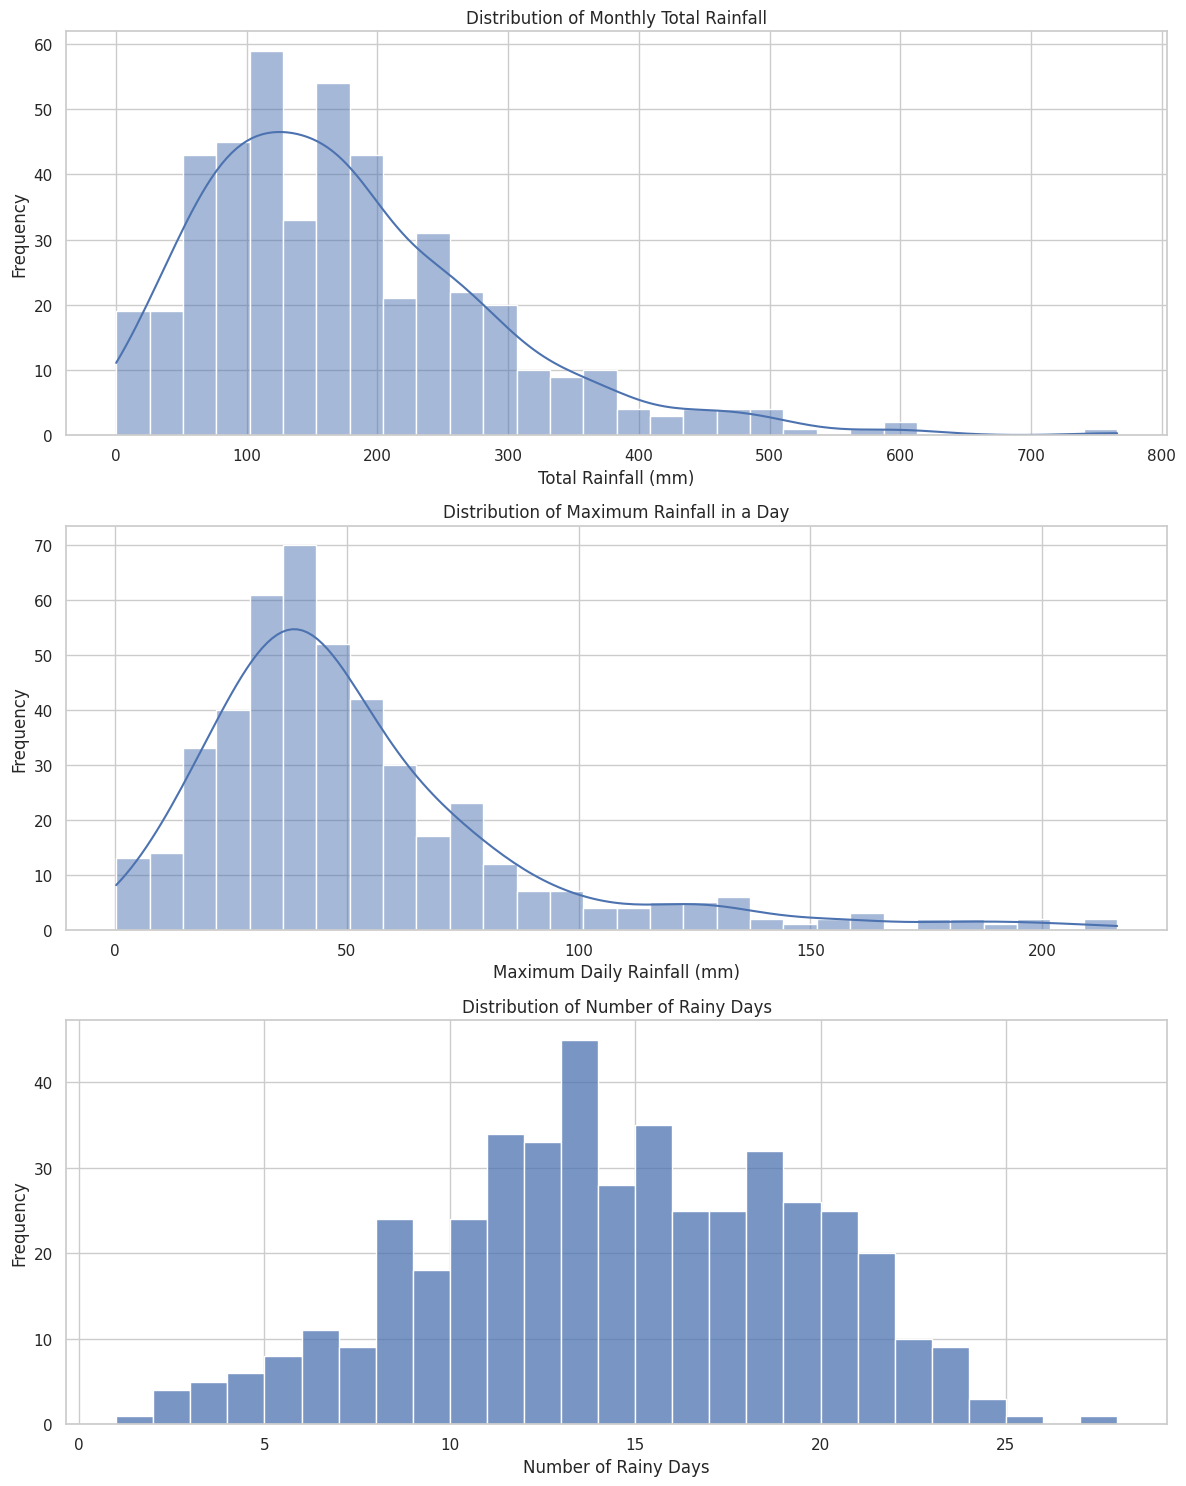

In [ ]:
# ============================================
# STEP 6.5: DISTRIBUTION ANALYSIS - HISTOGRAMS
# ============================================

fig, axes = plt.subplots(3, 1, figsize=(12, 15))

# Monthly Total Rainfall
sns.histplot(
    df_ts["total_rainfall"],
    bins=30,
    kde=True,
    ax=axes[0]
)
axes[0].set_title("Distribution of Monthly Total Rainfall")
axes[0].set_xlabel("Total Rainfall (mm)")
axes[0].set_ylabel("Frequency")

# Maximum Rainfall in a Day
sns.histplot(
    df_ts["maximum_rainfall_in_a_day"],
    bins=30,
    kde=True,
    ax=axes[1]
)
axes[1].set_title("Distribution of Maximum Rainfall in a Day")
axes[1].set_xlabel("Maximum Daily Rainfall (mm)")
axes[1].set_ylabel("Frequency")

# Number of Rainy Days
sns.histplot(
    df_ts["no_of_rainy_days"],
    bins=range(1, 29),
    kde=False,
    ax=axes[2]
)
axes[2].set_title("Distribution of Number of Rainy Days")
axes[2].set_xlabel("Number of Rainy Days")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### Rainfall Distribution Analysis

Histogram analysis showed that monthly total rainfall and maximum daily rainfall are positively skewed, with long right tails representing relatively infrequent high-rainfall events. Maximum daily rainfall exhibited stronger right skewness, consistent with its higher skewness and kurtosis statistics.

In contrast, the number of rainy days showed a comparatively symmetric distribution centered around moderate monthly rainy-day counts. The visual findings are consistent with the descriptive statistics and confirm that extreme rainfall observations require further investigation rather than automatic removal.


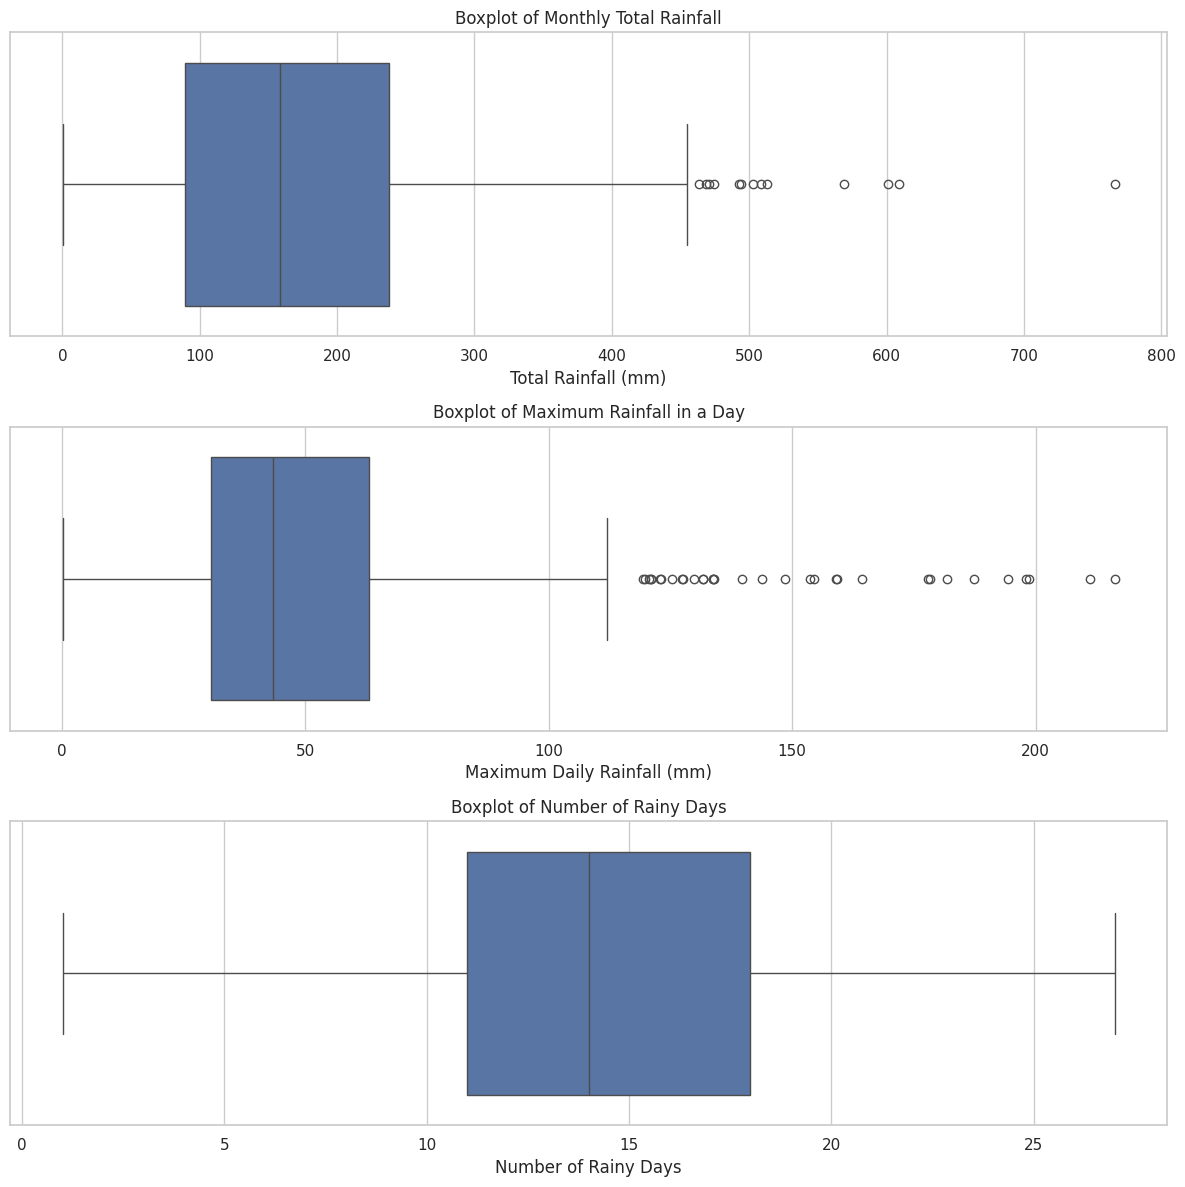

In [ ]:
# ============================================
# STEP 6.6A: BOXPLOT ANALYSIS
# ============================================

fig, axes = plt.subplots(3, 1, figsize=(12, 12))

# Monthly Total Rainfall
sns.boxplot(
    x=df_ts["total_rainfall"],
    ax=axes[0]
)
axes[0].set_title("Boxplot of Monthly Total Rainfall")
axes[0].set_xlabel("Total Rainfall (mm)")

# Maximum Rainfall in a Day
sns.boxplot(
    x=df_ts["maximum_rainfall_in_a_day"],
    ax=axes[1]
)
axes[1].set_title("Boxplot of Maximum Rainfall in a Day")
axes[1].set_xlabel("Maximum Daily Rainfall (mm)")

# Number of Rainy Days
sns.boxplot(
    x=df_ts["no_of_rainy_days"],
    ax=axes[2]
)
axes[2].set_title("Boxplot of Number of Rainy Days")
axes[2].set_xlabel("Number of Rainy Days")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# STEP 6.6B: IQR-BASED POTENTIAL OUTLIER CHECK
# ============================================

for column in df_ts.columns:

    Q1 = df_ts[column].quantile(0.25)
    Q3 = df_ts[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    potential_outliers = df_ts[
        (df_ts[column] < lower_bound) |
        (df_ts[column] > upper_bound)
    ]

    print(f"\n{column}")
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Lower Bound: {lower_bound:.2f}")
    print(f"Upper Bound: {upper_bound:.2f}")
    print(f"Number of Potential Outliers: {len(potential_outliers)}")


total_rainfall
Q1: 89.03
Q3: 237.95
IQR: 148.92
Lower Bound: -134.36
Upper Bound: 461.34
Number of Potential Outliers: 13

maximum_rainfall_in_a_day
Q1: 30.62
Q3: 63.15
IQR: 32.53
Lower Bound: -18.16
Upper Bound: 111.94
Number of Potential Outliers: 33

no_of_rainy_days
Q1: 11.00
Q3: 18.00
IQR: 7.00
Lower Bound: 0.50
Upper Bound: 28.50
Number of Potential Outliers: 0


In [ ]:
# ============================================
# STEP 6.6C: DISPLAY POTENTIAL OUTLIERS
# ============================================

for column in df_ts.columns:

    Q1 = df_ts[column].quantile(0.25)
    Q3 = df_ts[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    potential_outliers = df_ts[
        (df_ts[column] < lower_bound) |
        (df_ts[column] > upper_bound)
    ]

    print(f"\nPotential outliers for {column}:")
    display(potential_outliers[[column]])


Potential outliers for total_rainfall:


,total_rainfall
month,
1982-12-01,494.1
1984-02-01,470.4
1987-01-01,568.6
1989-11-01,508.4
1991-12-01,492.3
1992-11-01,474.3
1992-12-01,502.7
1998-12-01,463.4
2001-12-01,609.0



Potential outliers for maximum_rainfall_in_a_day:


,maximum_rainfall_in_a_day
month,
1983-08-01,181.8
1983-12-01,164.4
1984-02-01,154.4
1984-03-01,119.4
1984-06-01,121.1
1986-12-01,131.7
1987-01-01,127.4
1988-09-01,187.3
1989-11-01,148.6



Potential outliers for no_of_rainy_days:


,no_of_rainy_days
month,


### Boxplot and Potential Outlier Analysis

Boxplot and IQR analysis identified 13 potential outliers in monthly total rainfall above the upper IQR threshold of 461.34 mm and 33 potential outliers in maximum daily rainfall above 111.94 mm. No IQR-based outliers were identified for the number of rainy days.

The rainfall-related outliers predominantly represent unusually high observations and are consistent with the positive skewness and long right tails observed in the earlier distribution analysis. Since extreme rainfall can represent genuine meteorological events and is relevant to the forecasting objectives, these observations were retained rather than automatically removed. Their temporal and seasonal patterns will be investigated further during time-series analysis.


# Step 6.7 — Time-Series Trend Visualization

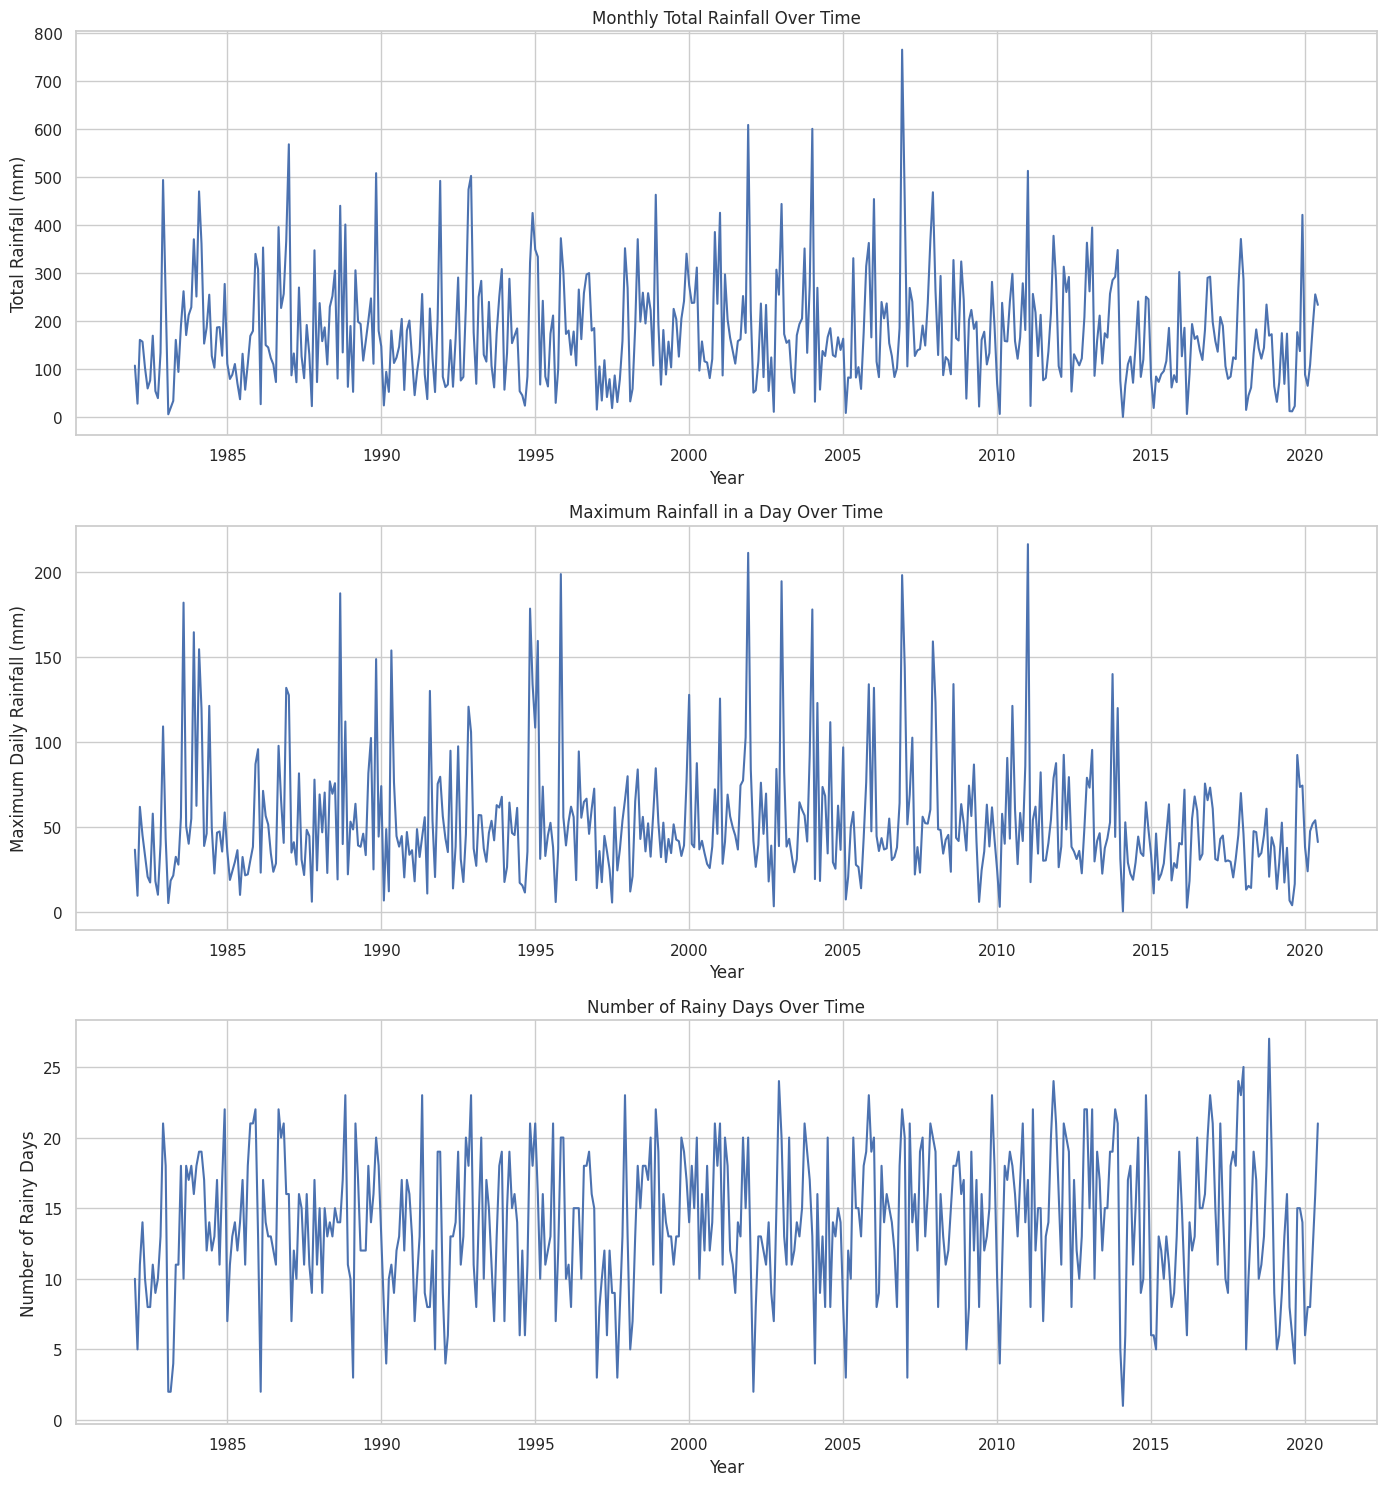

In [ ]:
# ============================================
# STEP 6.7: TIME-SERIES TREND VISUALIZATION
# ============================================

fig, axes = plt.subplots(3, 1, figsize=(14, 15))

# Monthly Total Rainfall
axes[0].plot(
    df_ts.index,
    df_ts["total_rainfall"]
)
axes[0].set_title("Monthly Total Rainfall Over Time")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Total Rainfall (mm)")

# Maximum Rainfall in a Day
axes[1].plot(
    df_ts.index,
    df_ts["maximum_rainfall_in_a_day"]
)
axes[1].set_title("Maximum Rainfall in a Day Over Time")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Maximum Daily Rainfall (mm)")

# Number of Rainy Days
axes[2].plot(
    df_ts.index,
    df_ts["no_of_rainy_days"]
)
axes[2].set_title("Number of Rainy Days Over Time")
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Number of Rainy Days")

plt.tight_layout()
plt.show()

### Time-Series Trend Visualization

Time-series plots revealed substantial month-to-month variability in monthly total rainfall, maximum daily rainfall, and the number of rainy days between 1982 and 2020. Several pronounced rainfall spikes were observed, consistent with the extreme values identified during the distribution and outlier analyses.

No clear sustained upward or downward long-term trend was visually apparent in the raw monthly series. However, this observation will be investigated further using rolling statistics and statistical methods. Seasonal patterns were also not clearly distinguishable from the long-term plots and will therefore be examined separately through calendar-month and seasonal analyses.


# Step 6.8 — 12-Month Rolling Mean and Rolling Standard Deviation

In [ ]:
# ============================================
# STEP 6.8A: 12-MONTH ROLLING STATISTICS
# ============================================

rolling_mean_12 = df_ts.rolling(window=12).mean()

rolling_std_12 = df_ts.rolling(window=12).std()

print("12-month rolling statistics calculated successfully.")

display(rolling_mean_12.head(15))

12-month rolling statistics calculated successfully.


,total_rainfall,maximum_rainfall_in_a_day,no_of_rainy_days
month,,,
1982-01-01,NaN,NaN,NaN
1982-02-01,NaN,NaN,NaN
1982-03-01,NaN,NaN,NaN
1982-04-01,NaN,NaN,NaN
1982-05-01,NaN,NaN,NaN
1982-06-01,NaN,NaN,NaN
1982-07-01,NaN,NaN,NaN
1982-08-01,NaN,NaN,NaN
1982-09-01,NaN,NaN,NaN


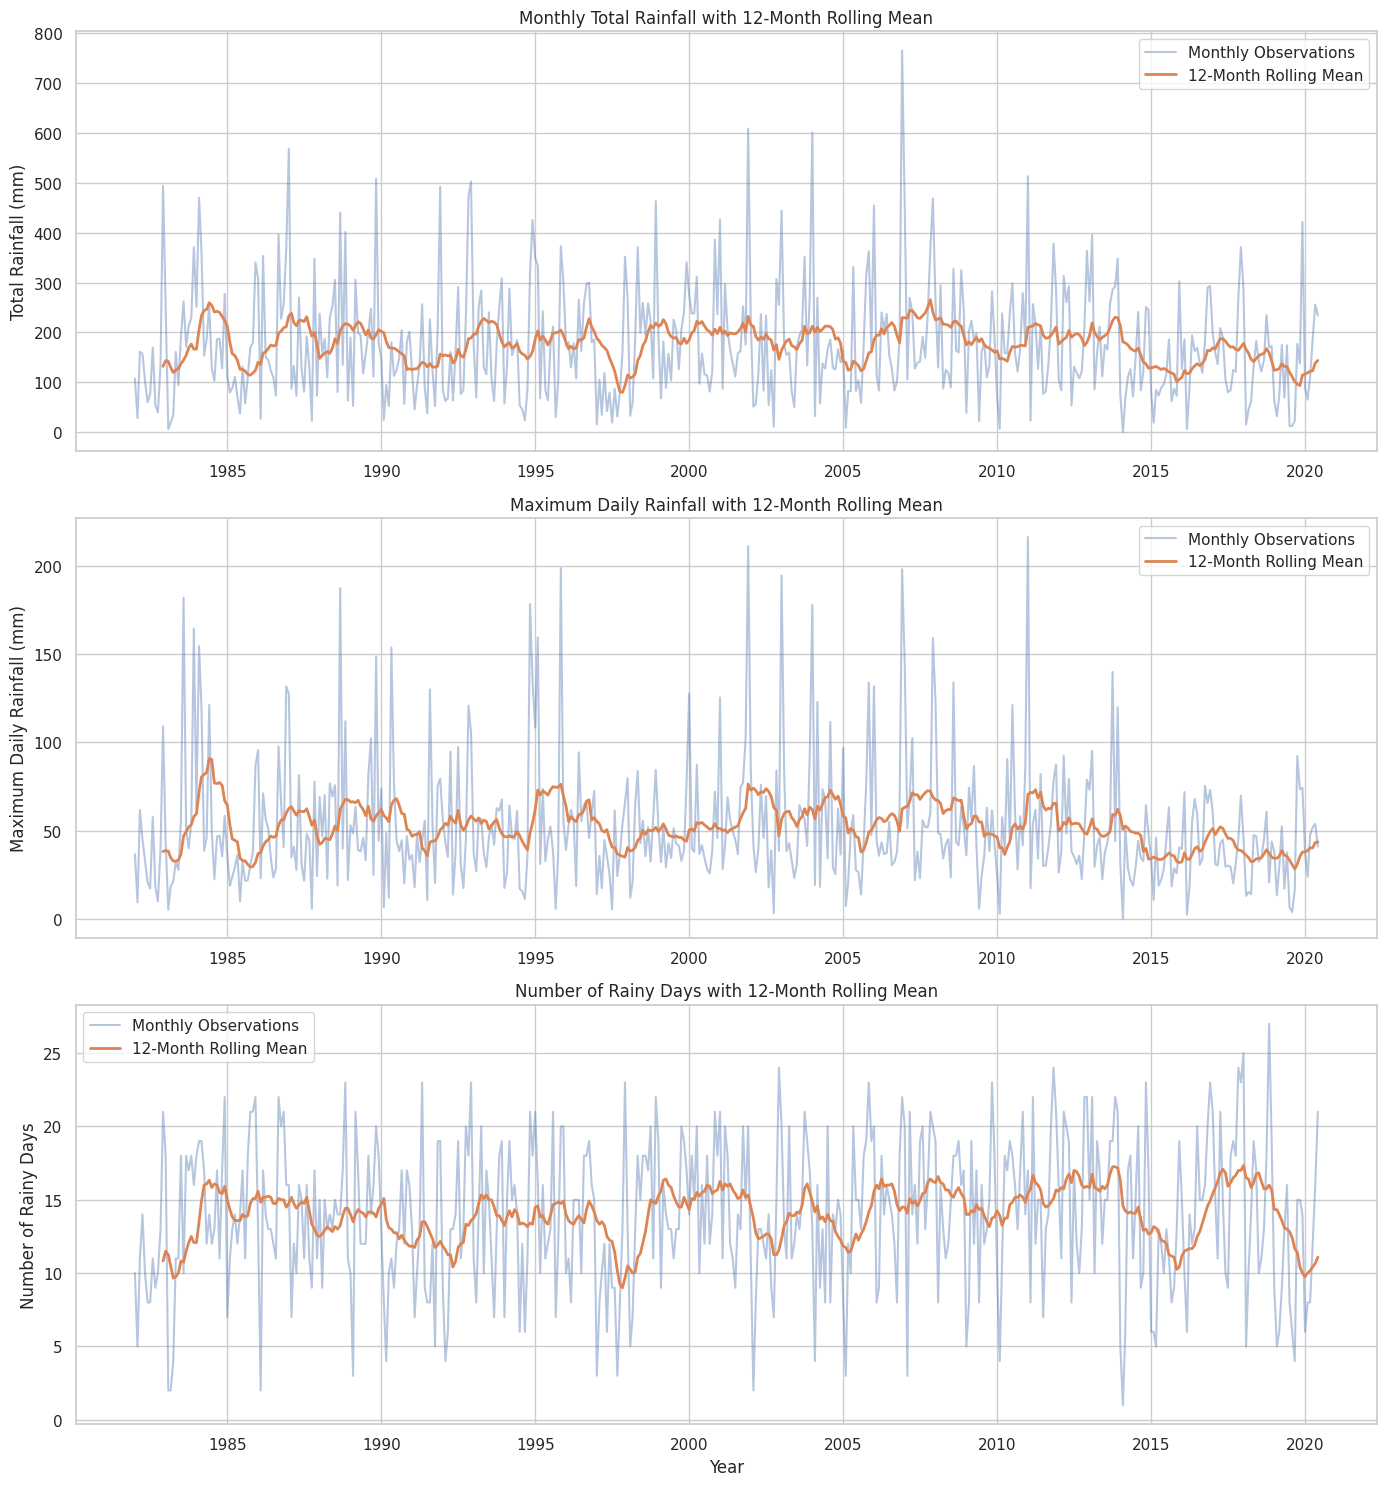

In [ ]:
# ============================================
# STEP 6.8B: PLOT 12-MONTH ROLLING MEAN
# ============================================

fig, axes = plt.subplots(3, 1, figsize=(14, 15))

# Total Rainfall
axes[0].plot(
    df_ts.index,
    df_ts["total_rainfall"],
    alpha=0.4,
    label="Monthly Observations"
)

axes[0].plot(
    rolling_mean_12.index,
    rolling_mean_12["total_rainfall"],
    linewidth=2,
    label="12-Month Rolling Mean"
)

axes[0].set_title("Monthly Total Rainfall with 12-Month Rolling Mean")
axes[0].set_ylabel("Total Rainfall (mm)")
axes[0].legend()


# Maximum Daily Rainfall
axes[1].plot(
    df_ts.index,
    df_ts["maximum_rainfall_in_a_day"],
    alpha=0.4,
    label="Monthly Observations"
)

axes[1].plot(
    rolling_mean_12.index,
    rolling_mean_12["maximum_rainfall_in_a_day"],
    linewidth=2,
    label="12-Month Rolling Mean"
)

axes[1].set_title(
    "Maximum Daily Rainfall with 12-Month Rolling Mean"
)
axes[1].set_ylabel("Maximum Daily Rainfall (mm)")
axes[1].legend()


# Number of Rainy Days
axes[2].plot(
    df_ts.index,
    df_ts["no_of_rainy_days"],
    alpha=0.4,
    label="Monthly Observations"
)

axes[2].plot(
    rolling_mean_12.index,
    rolling_mean_12["no_of_rainy_days"],
    linewidth=2,
    label="12-Month Rolling Mean"
)

axes[2].set_title(
    "Number of Rainy Days with 12-Month Rolling Mean"
)
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Number of Rainy Days")
axes[2].legend()

plt.tight_layout()
plt.show()

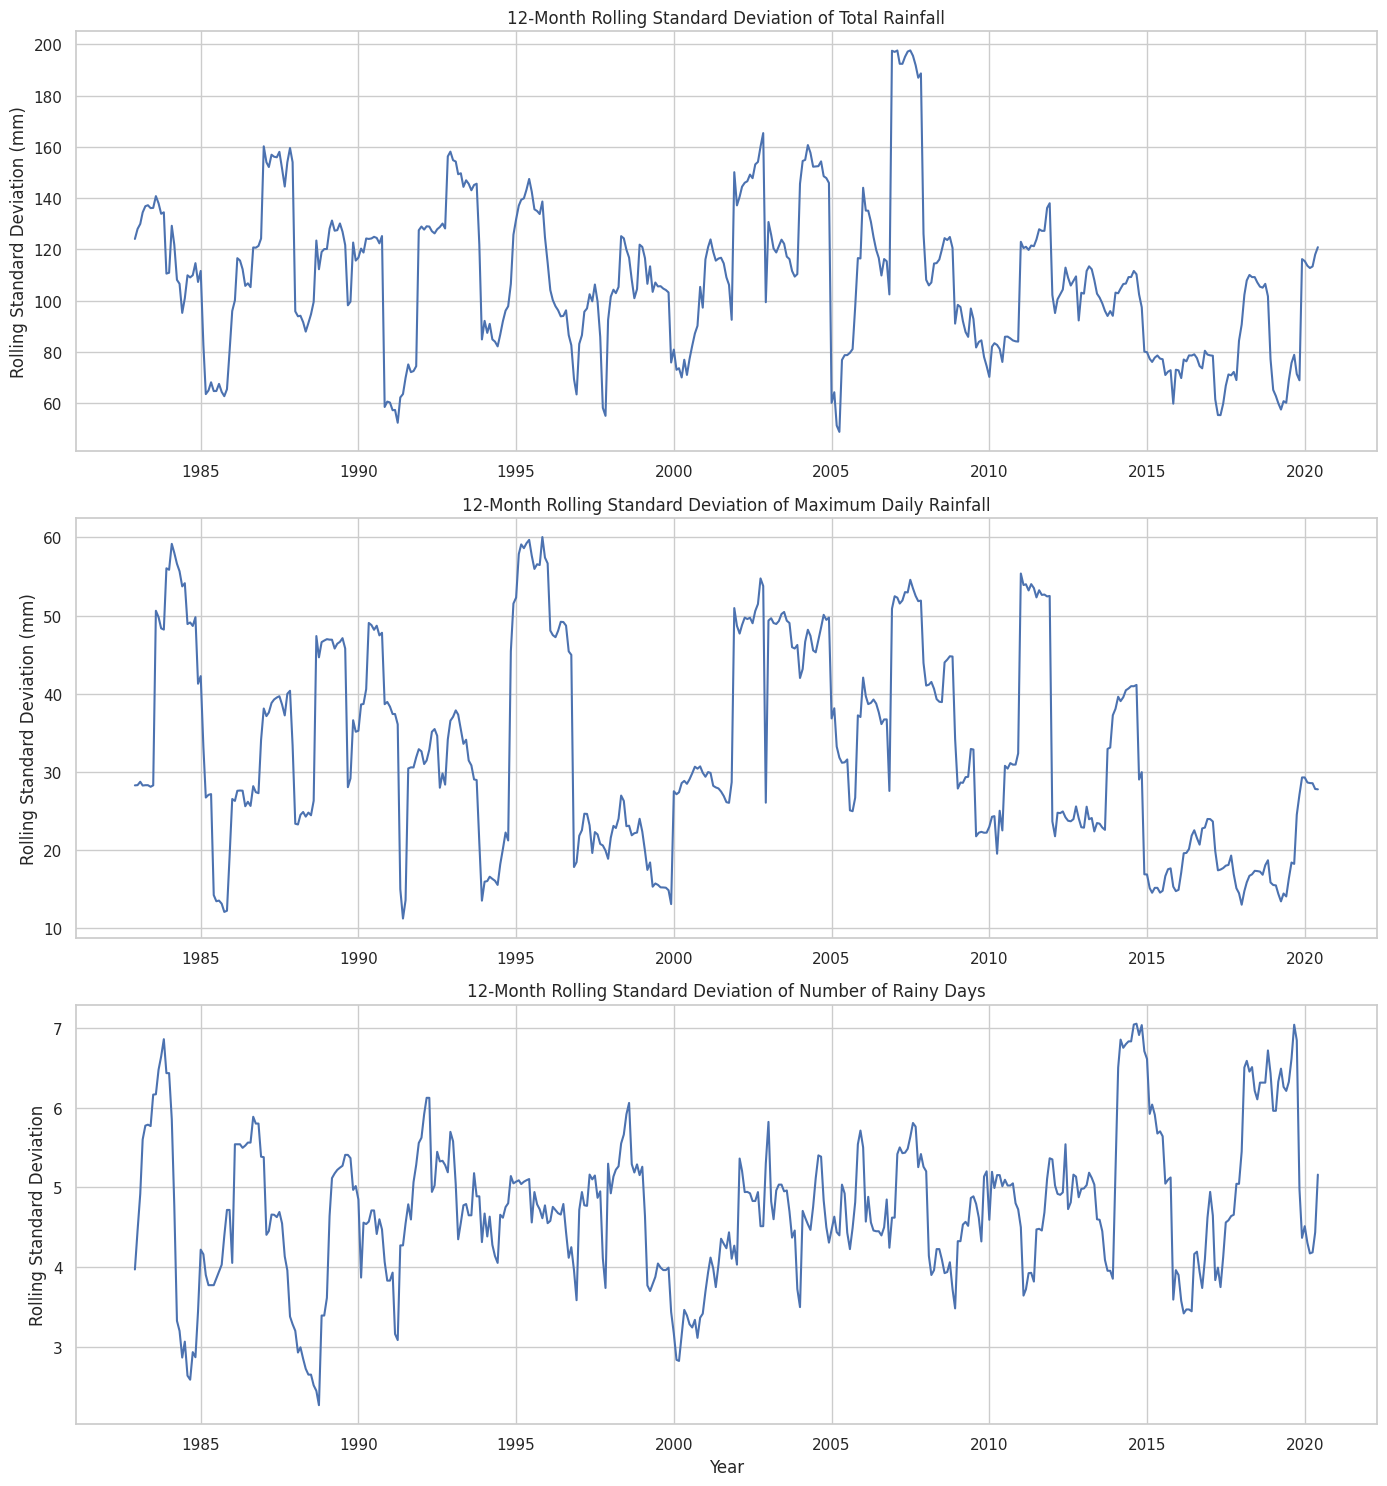

In [ ]:
# ============================================
# STEP 6.8C: PLOT 12-MONTH ROLLING STD
# ============================================

fig, axes = plt.subplots(3, 1, figsize=(14, 15))

axes[0].plot(
    rolling_std_12.index,
    rolling_std_12["total_rainfall"]
)
axes[0].set_title(
    "12-Month Rolling Standard Deviation of Total Rainfall"
)
axes[0].set_ylabel("Rolling Standard Deviation (mm)")


axes[1].plot(
    rolling_std_12.index,
    rolling_std_12["maximum_rainfall_in_a_day"]
)
axes[1].set_title(
    "12-Month Rolling Standard Deviation of Maximum Daily Rainfall"
)
axes[1].set_ylabel("Rolling Standard Deviation (mm)")


axes[2].plot(
    rolling_std_12.index,
    rolling_std_12["no_of_rainy_days"]
)
axes[2].set_title(
    "12-Month Rolling Standard Deviation of Number of Rainy Days"
)
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Rolling Standard Deviation")

plt.tight_layout()
plt.show()

# Step 6.9 — Calendar-Month Seasonality Analysis

In [ ]:
# ============================================
# STEP 6.9A: CREATE CALENDAR-MONTH FEATURES
# ============================================

df_seasonal = df_ts.copy()

df_seasonal["month_number"] = df_seasonal.index.month
df_seasonal["month_name"] = df_seasonal.index.strftime("%b")

display(df_seasonal.head())

,total_rainfall,maximum_rainfall_in_a_day,no_of_rainy_days,month_number,month_name
month,,,,,
1982-01-01,107.1,36.5,10,1,Jan
1982-02-01,27.8,9.4,5,2,Feb
1982-03-01,160.8,61.7,11,3,Mar
1982-04-01,157.0,45.1,14,4,Apr
1982-05-01,102.2,33.0,10,5,May


In [ ]:
# ============================================
# STEP 6.9B: AVERAGE VALUES BY CALENDAR MONTH
# ============================================

monthly_average = (
    df_seasonal
    .groupby("month_number")[
        [
            "total_rainfall",
            "maximum_rainfall_in_a_day",
            "no_of_rainy_days"
        ]
    ]
    .mean()
)

monthly_average.index = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

display(monthly_average.round(2))

,total_rainfall,maximum_rainfall_in_a_day,no_of_rainy_days
Jan,225.99,74.46,13.38
Feb,104.74,38.68,8.26
Mar,160.29,47.64,12.23
Apr,153.02,45.68,14.36
May,165.83,48.48,14.00
Jun,134.29,43.59,12.92
Jul,146.34,40.46,13.26
Aug,147.05,49.18,13.66
Sep,145.68,45.13,13.08
Oct,161.35,44.06,14.95


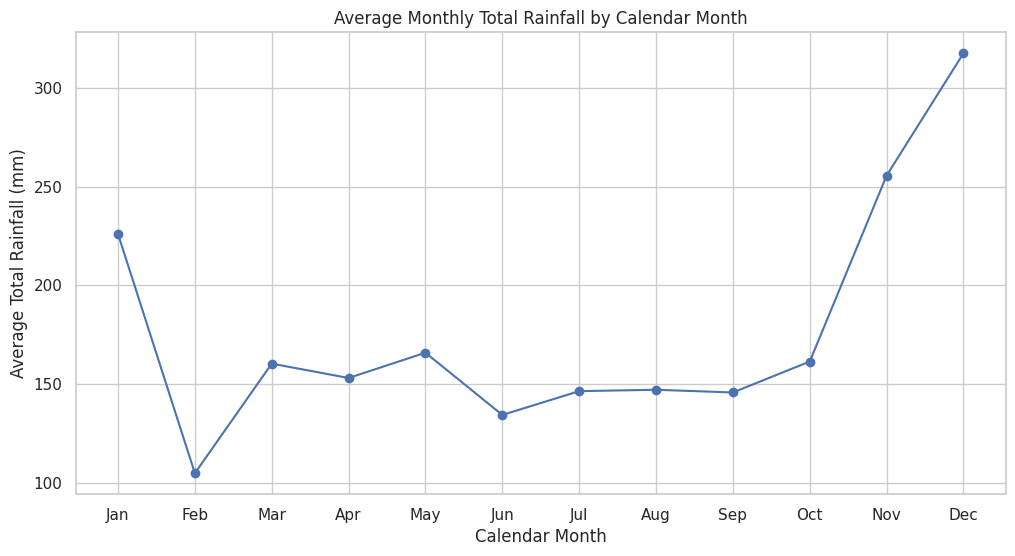

In [ ]:
# ============================================
# STEP 6.9C: MONTHLY TOTAL RAINFALL SEASONALITY
# ============================================

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_average.index,
    monthly_average["total_rainfall"],
    marker="o"
)

plt.title("Average Monthly Total Rainfall by Calendar Month")
plt.xlabel("Calendar Month")
plt.ylabel("Average Total Rainfall (mm)")

plt.show()

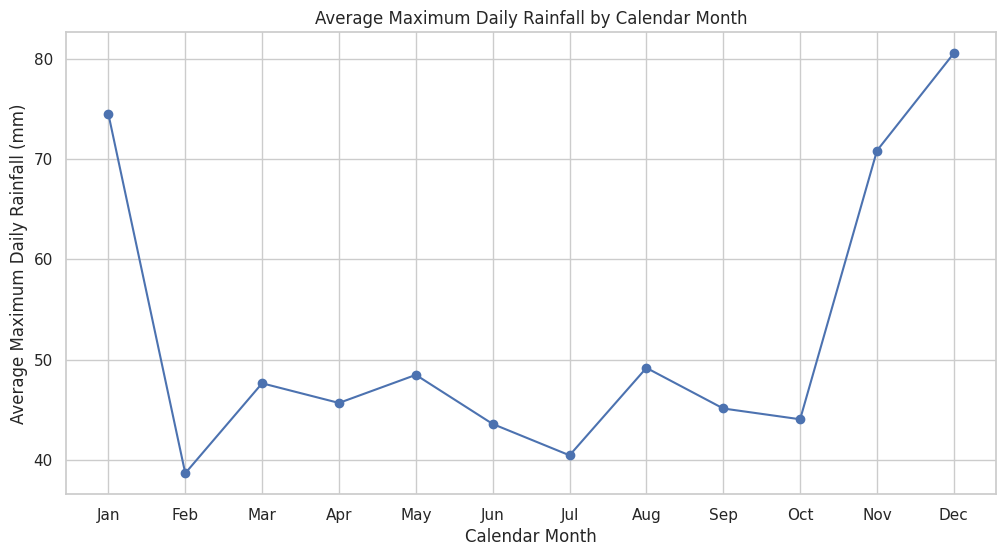

In [ ]:
# ============================================
# STEP 6.9D: MAXIMUM DAILY RAINFALL SEASONALITY
# ============================================

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_average.index,
    monthly_average["maximum_rainfall_in_a_day"],
    marker="o"
)

plt.title("Average Maximum Daily Rainfall by Calendar Month")
plt.xlabel("Calendar Month")
plt.ylabel("Average Maximum Daily Rainfall (mm)")

plt.show()

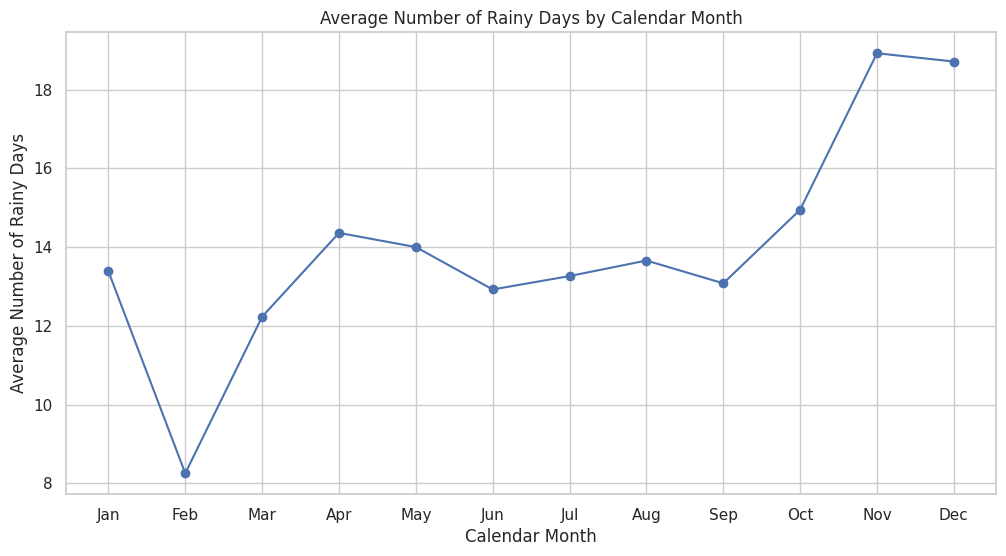

In [ ]:
# ============================================
# STEP 6.9E: RAINY-DAY SEASONALITY
# ============================================

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_average.index,
    monthly_average["no_of_rainy_days"],
    marker="o"
)

plt.title("Average Number of Rainy Days by Calendar Month")
plt.xlabel("Calendar Month")
plt.ylabel("Average Number of Rainy Days")

plt.show()

### Calendar-Month Seasonality Analysis

Calendar-month analysis revealed clear differences in rainfall behavior throughout the year. December recorded the highest average monthly total rainfall (317.61 mm) and maximum daily rainfall (80.53 mm), while November recorded the highest average number of rainy days (18.92 days). January also showed relatively high rainfall levels.

February was the driest calendar month across all three measures, with average total rainfall of 104.74 mm, maximum daily rainfall of 38.68 mm, and 8.26 rainy days.

The pronounced differences across calendar months provide strong descriptive evidence of annual seasonality, particularly the wetter November–January period. This seasonal structure will be examined further using time-series decomposition and autocorrelation analysis before forecasting.


# Step 6.10 — Yearly Rainfall Analysis

In [ ]:
# ============================================
# STEP 6.10A: CHECK MONTHS AVAILABLE PER YEAR
# ============================================

months_per_year = df_ts.groupby(df_ts.index.year).size()

print("Number of monthly observations per year:")
display(months_per_year.to_frame(name="Number_of_Months"))

Number of monthly observations per year:


,Number_of_Months
month,
1982,12
1983,12
1984,12
1985,12
1986,12
1987,12
1988,12
1989,12
1990,12


In [ ]:
# ============================================
# STEP 6.10B: CREATE YEARLY RAINFALL SUMMARY
# ============================================

yearly_summary = df_ts.resample("YE").agg({
    "total_rainfall": "sum",
    "maximum_rainfall_in_a_day": "max",
    "no_of_rainy_days": "sum"
})

yearly_summary["months_available"] = (
    df_ts["total_rainfall"]
    .resample("YE")
    .count()
)

display(yearly_summary)

,total_rainfall,maximum_rainfall_in_a_day,no_of_rainy_days,months_available
month,,,,
1982-12-31,1581.7,109.0,130,12
1983-12-31,1993.7,181.8,145,12
1984-12-31,2686.7,154.4,191,12
1985-12-31,1483.9,86.8,181,12
1986-12-31,2536.1,131.7,174,12
1987-12-31,2102.8,127.4,151,12
1988-12-31,2598.6,187.3,173,12
1989-12-31,2463.2,148.6,173,12
1990-12-31,1523.8,153.7,142,12


In [ ]:
# ============================================
# STEP 6.10C: KEEP COMPLETE YEARS
# ============================================

yearly_complete = yearly_summary[
    yearly_summary["months_available"] == 12
].copy()

print("Number of complete years:", len(yearly_complete))

print(
    "Complete-year range:",
    yearly_complete.index.min().year,
    "to",
    yearly_complete.index.max().year
)

display(yearly_complete.head())

Number of complete years: 38
Complete-year range: 1982 to 2019


,total_rainfall,maximum_rainfall_in_a_day,no_of_rainy_days,months_available
month,,,,
1982-12-31,1581.7,109.0,130,12
1983-12-31,1993.7,181.8,145,12
1984-12-31,2686.7,154.4,191,12
1985-12-31,1483.9,86.8,181,12
1986-12-31,2536.1,131.7,174,12


In [ ]:
# ============================================
# STEP 6.10D: IDENTIFY EXTREME YEARS
# ============================================

wettest_year = yearly_complete["total_rainfall"].idxmax()
driest_year = yearly_complete["total_rainfall"].idxmin()

highest_annual_rainfall = yearly_complete["total_rainfall"].max()
lowest_annual_rainfall = yearly_complete["total_rainfall"].min()

print(
    "Wettest complete year:",
    wettest_year.year,
    f"({highest_annual_rainfall:.1f} mm)"
)

print(
    "Driest complete year:",
    driest_year.year,
    f"({lowest_annual_rainfall:.1f} mm)"
)

Wettest complete year: 2007 (2886.2 mm)
Driest complete year: 1997 (1118.9 mm)


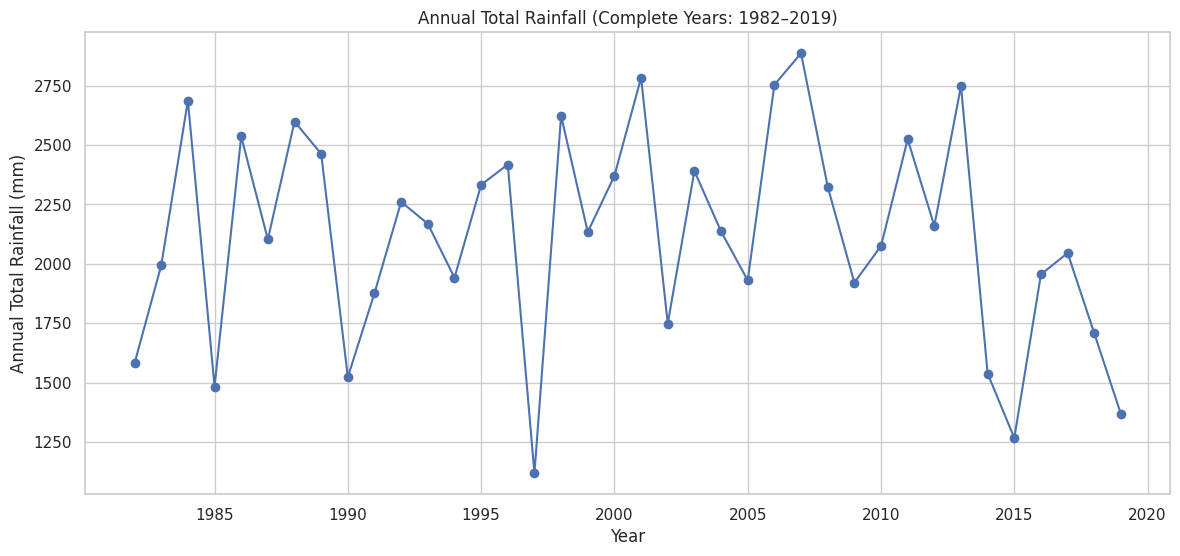

In [ ]:
# ============================================
# STEP 6.10E: ANNUAL TOTAL RAINFALL
# ============================================

plt.figure(figsize=(14, 6))

plt.plot(
    yearly_complete.index.year,
    yearly_complete["total_rainfall"],
    marker="o"
)

plt.title("Annual Total Rainfall (Complete Years: 1982–2019)")
plt.xlabel("Year")
plt.ylabel("Annual Total Rainfall (mm)")

plt.grid(True)
plt.show()

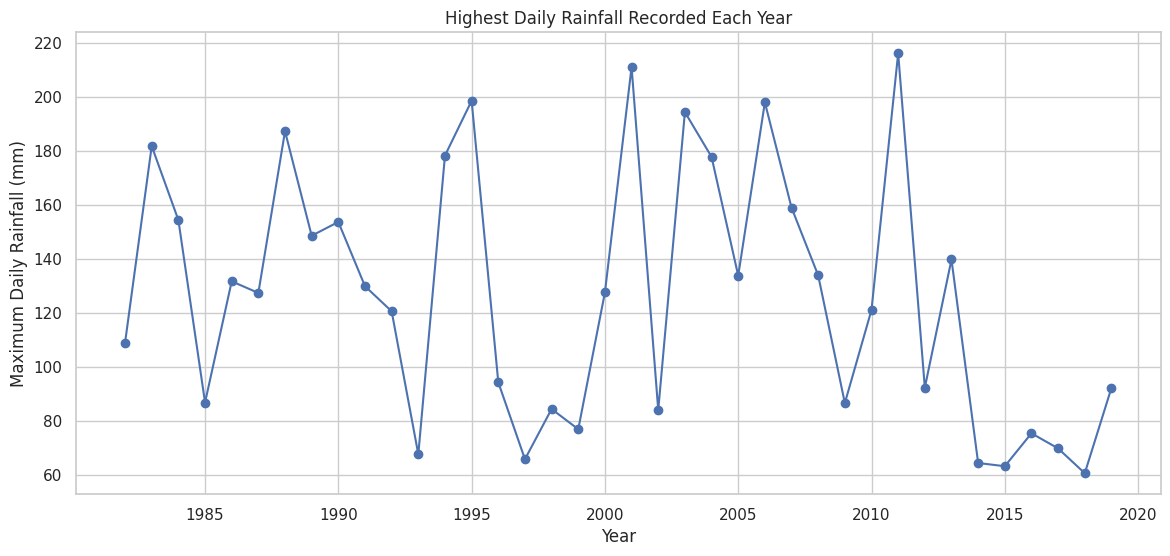

In [ ]:
# ============================================
# STEP 6.10F: ANNUAL MAXIMUM DAILY RAINFALL
# ============================================

plt.figure(figsize=(14, 6))

plt.plot(
    yearly_complete.index.year,
    yearly_complete["maximum_rainfall_in_a_day"],
    marker="o"
)

plt.title("Highest Daily Rainfall Recorded Each Year")
plt.xlabel("Year")
plt.ylabel("Maximum Daily Rainfall (mm)")

plt.grid(True)
plt.show()

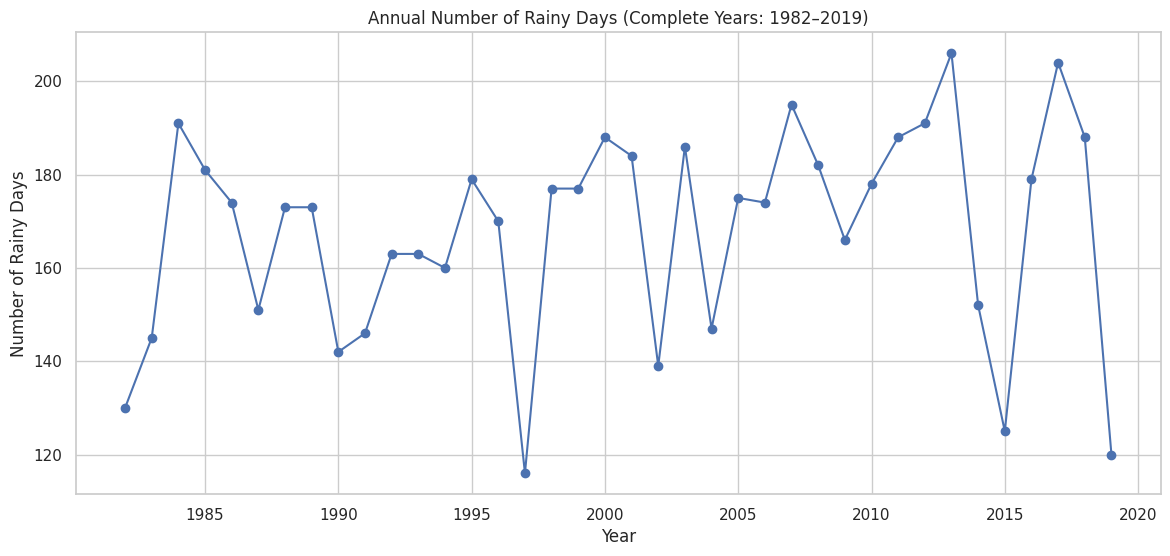

In [ ]:
# ============================================
# STEP 6.10G: ANNUAL NUMBER OF RAINY DAYS
# ============================================

plt.figure(figsize=(14, 6))

plt.plot(
    yearly_complete.index.year,
    yearly_complete["no_of_rainy_days"],
    marker="o"
)

plt.title("Annual Number of Rainy Days (Complete Years: 1982–2019)")
plt.xlabel("Year")
plt.ylabel("Number of Rainy Days")

plt.grid(True)
plt.show()

### Yearly Rainfall Analysis

Yearly rainfall analysis was conducted using the 38 complete years from 1982 to 2019. The year 2020 was excluded only from full-year comparisons because the dataset contains observations through June 2020.

Annual total rainfall showed substantial interannual variability without an obvious persistent long-term upward or downward trend. The wettest complete year was 2007 with 2886.2 mm of rainfall, while 1997 was the driest with 1118.9 mm.

The highest daily rainfall event was recorded in 2011 at 216.2 mm, demonstrating that the year with the greatest annual rainfall does not necessarily contain the most extreme single-day rainfall event. Annual rainy-day counts also varied considerably across years, indicating the need to further examine relationships among rainfall amount, rainfall intensity, and rainfall frequency.


# Step 6.11 — Relationship and Correlation Analysis

In [ ]:
# ============================================
# STEP 6.11A: CORRELATION MATRIX
# ============================================

correlation_matrix = df_ts[
    [
        "total_rainfall",
        "maximum_rainfall_in_a_day",
        "no_of_rainy_days"
    ]
].corr()

print("Correlation Matrix:")
display(correlation_matrix.round(3))

Correlation Matrix:


,total_rainfall,maximum_rainfall_in_a_day,no_of_rainy_days
total_rainfall,1.000,0.803,0.702
maximum_rainfall_in_a_day,0.803,1.000,0.411
no_of_rainy_days,0.702,0.411,1.000


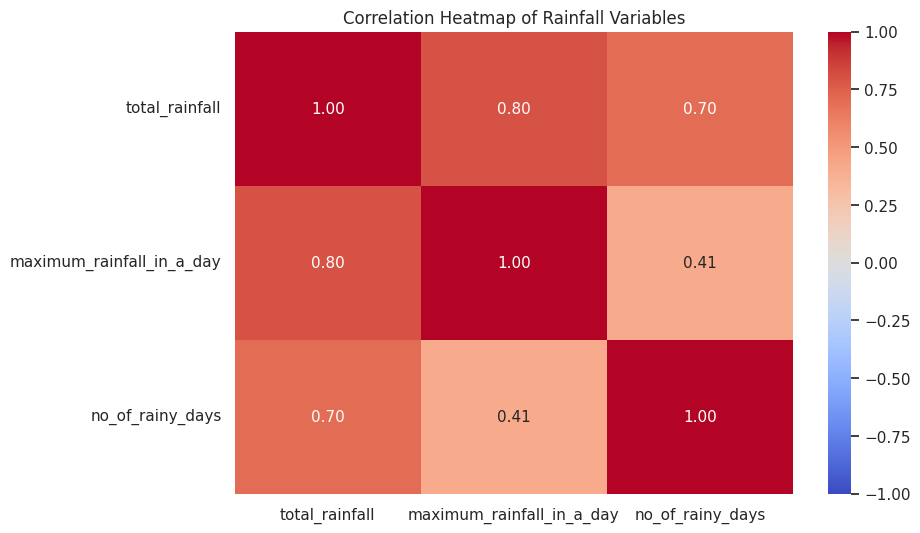

In [ ]:
# ============================================
# STEP 6.11B: CORRELATION HEATMAP
# ============================================

plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Heatmap of Rainfall Variables")
plt.show()

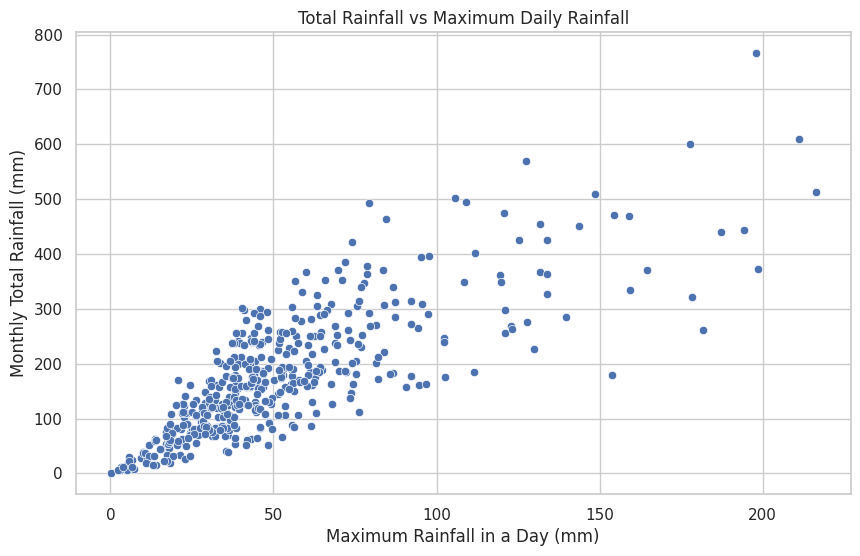

In [ ]:
# ============================================
# STEP 6.11C: TOTAL RAINFALL VS MAX DAILY
# ============================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_ts,
    x="maximum_rainfall_in_a_day",
    y="total_rainfall"
)

plt.title("Total Rainfall vs Maximum Daily Rainfall")
plt.xlabel("Maximum Rainfall in a Day (mm)")
plt.ylabel("Monthly Total Rainfall (mm)")

plt.show()

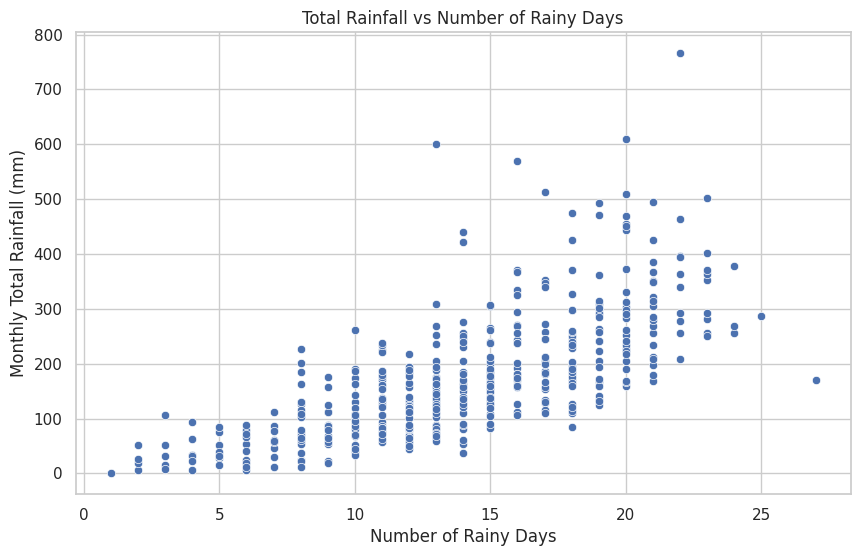

In [ ]:
# ============================================
# STEP 6.11D: TOTAL RAINFALL VS RAINY DAYS
# ============================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_ts,
    x="no_of_rainy_days",
    y="total_rainfall"
)

plt.title("Total Rainfall vs Number of Rainy Days")
plt.xlabel("Number of Rainy Days")
plt.ylabel("Monthly Total Rainfall (mm)")

plt.show()

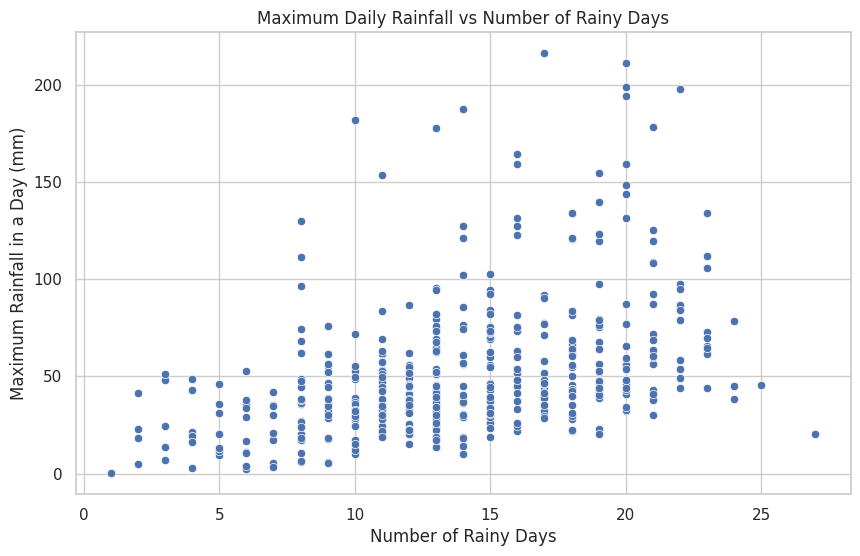

In [ ]:
# ============================================
# STEP 6.11E: MAX DAILY RAINFALL VS RAINY DAYS
# ============================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_ts,
    x="no_of_rainy_days",
    y="maximum_rainfall_in_a_day"
)

plt.title("Maximum Daily Rainfall vs Number of Rainy Days")
plt.xlabel("Number of Rainy Days")
plt.ylabel("Maximum Rainfall in a Day (mm)")

plt.show()

### Relationship and Correlation Analysis

Pearson correlation analysis identified positive relationships among all three rainfall variables. Monthly total rainfall showed a strong positive correlation with maximum daily rainfall (r = 0.803) and with the number of rainy days (r = 0.702). Maximum daily rainfall and the number of rainy days exhibited a comparatively moderate positive correlation (r = 0.411).

The findings indicate that monthly rainfall accumulation is associated with both rainfall intensity and rainfall frequency, while the weaker relationship between maximum daily rainfall and rainy-day count highlights their distinct characteristics. Scatter plots supported these correlation patterns and also showed variability around the relationships. Correlation was interpreted as association rather than causation.


# Step 7 — Formal Time-Series Analysis

### Step 7.1 — Seasonal Decomposition of Monthly Total Rainfall

The purpose of decomposition is to separate the rainfall series into:


Observed Series
      =
Trend
+
Seasonality
+
Residual / Random variation

In [ ]:
# ============================================
# STEP 7.1A: IMPORT SEASONAL DECOMPOSITION
# ============================================

from statsmodels.tsa.seasonal import seasonal_decompose

print("Seasonal decomposition library imported successfully.")

Seasonal decomposition library imported successfully.


In [ ]:
# ============================================
# STEP 7.1B: SEASONAL DECOMPOSITION
# ============================================

decomposition_total = seasonal_decompose(
    df_ts["total_rainfall"],
    model="additive",
    period=12
)

print("Seasonal decomposition completed successfully.")

Seasonal decomposition completed successfully.


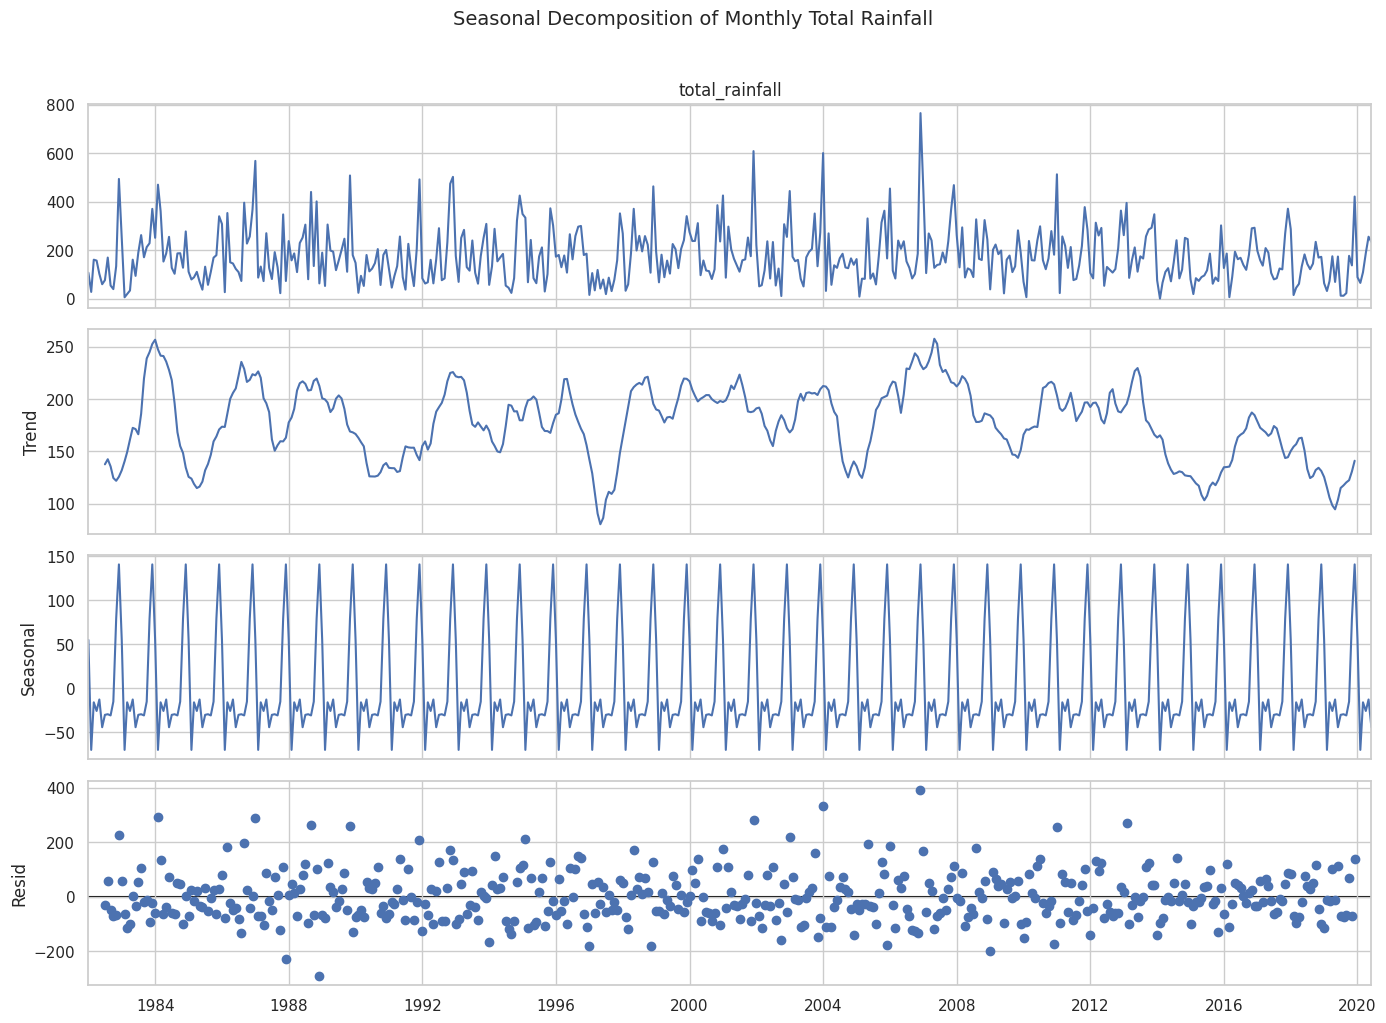

In [ ]:
# ============================================
# STEP 7.1C: PLOT SEASONAL DECOMPOSITION
# ============================================

fig = decomposition_total.plot()

fig.set_size_inches(14, 10)

plt.suptitle(
    "Seasonal Decomposition of Monthly Total Rainfall",
    fontsize=14,
    y=1.02
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# STEP 7.1D: INSPECT DECOMPOSITION COMPONENTS
# ============================================

decomposition_components = pd.DataFrame({
    "Observed": df_ts["total_rainfall"],
    "Trend": decomposition_total.trend,
    "Seasonal": decomposition_total.seasonal,
    "Residual": decomposition_total.resid
})

display(decomposition_components.head(15))

,Observed,Trend,Seasonal,Residual
month,,,,
1982-01-01,107.1,NaN,54.830628,NaN
1982-02-01,27.8,NaN,-69.949327,NaN
1982-03-01,160.8,NaN,-15.952705,NaN
1982-04-01,157.0,NaN,-25.780408,NaN
1982-05-01,102.2,NaN,-12.782322,NaN
1982-06-01,59.5,NaN,-44.207097,NaN
1982-07-01,76.3,137.595833,-30.171271,-31.124562
1982-08-01,169.5,142.458333,-29.483662,56.525328
1982-09-01,54.1,135.608333,-30.838486,-50.669847


### Seasonal Decomposition Analysis

Additive seasonal decomposition with a 12-month period was applied to monthly total rainfall to separate the observed series into trend, seasonal, and residual components.

The trend component exhibited gradual periods of increase and decrease without a clearly sustained long-term direction. The seasonal component showed a pronounced and consistently repeating annual pattern. December had the strongest positive seasonal effect (+140.55 mm), followed by November and January, while February showed the strongest negative seasonal effect (-69.95 mm). These findings are consistent with the earlier calendar-month analysis and provide further evidence of annual rainfall seasonality.

The residual component was generally distributed around zero but contained several large deviations, indicating that extreme rainfall events cannot be fully explained by the regular trend and seasonal structure. Edge `NaN` values in the trend and residual components resulted from the centered decomposition procedure and do not represent missing observations in the original dataset.


# Step 7.2 — Stationarity Testing Using the ADF Test

In [ ]:
# ============================================
# STEP 7.2B: IMPORT ADF TEST
# ============================================

from statsmodels.tsa.stattools import adfuller

print("ADF test imported successfully.")

ADF test imported successfully.


In [ ]:
# ============================================
# STEP 7.2C: ADF TEST — TOTAL RAINFALL
# ============================================

adf_result = adfuller(df_ts["total_rainfall"])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Number of Lags Used:", adf_result[2])
print("Number of Observations Used:", adf_result[3])

print("\nCritical Values:")

for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -5.316803062036406
p-value: 5.05345668949158e-06
Number of Lags Used: 14
Number of Observations Used: 447

Critical Values:
1%: -3.4450642060791097
5%: -2.868027634065253
10%: -2.5702256691640515


In [ ]:
# ============================================
# STEP 7.2F: INTERPRET ADF RESULT
# ============================================

significance_level = 0.05

if adf_result[1] < significance_level:
    print("Result: Reject the null hypothesis (H0).")
    print("Conclusion: The total rainfall series is stationary according to the ADF test.")
else:
    print("Result: Fail to reject the null hypothesis (H0).")
    print("Conclusion: The total rainfall series is non-stationary according to the ADF test.")

Result: Reject the null hypothesis (H0).
Conclusion: The total rainfall series is stationary according to the ADF test.


### ADF Stationarity Test

The Augmented Dickey-Fuller (ADF) test was applied to monthly total rainfall to assess stationarity. The test produced an ADF statistic of -5.317 and a p-value of approximately 0.000005, which is below the 5% significance level. The ADF statistic was also more negative than the 1%, 5%, and 10% critical values.

Therefore, the null hypothesis of a unit root was rejected, providing strong evidence that the monthly total rainfall series is stationary under the ADF test. The test used 14 lagged difference terms and 447 effective observations.


# Step 7.3 — ACF (Autocorrelation Function) Analysis

In [ ]:
# ============================================
# STEP 7.3B: IMPORT ACF
# ============================================

from statsmodels.graphics.tsaplots import plot_acf

print("ACF plotting function imported successfully.")

ACF plotting function imported successfully.


<Figure size 1400x600 with 0 Axes>

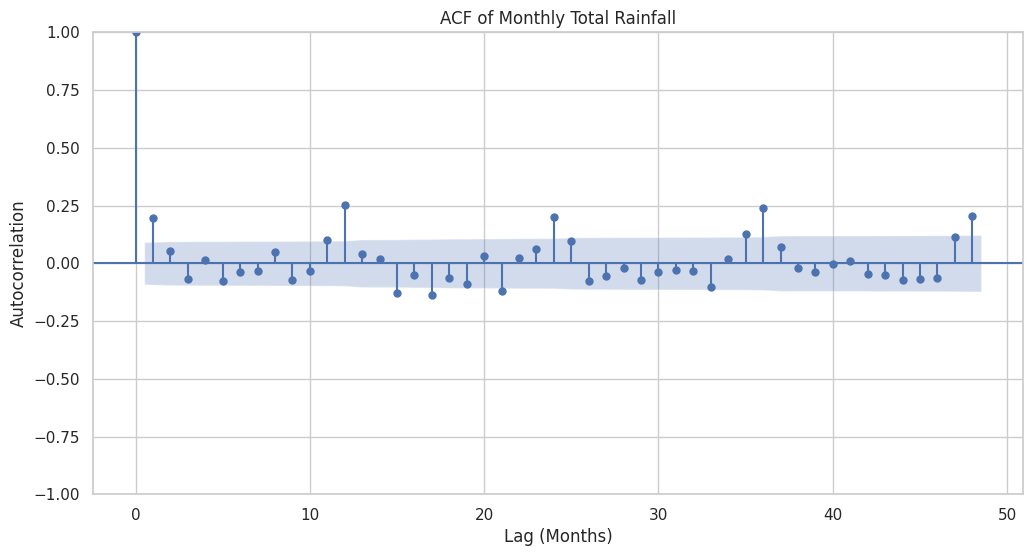

In [ ]:
# ============================================
# STEP 7.3C: ACF PLOT — TOTAL RAINFALL
# ============================================

plt.figure(figsize=(14, 6))

plot_acf(
    df_ts["total_rainfall"],
    lags=48,
    alpha=0.05
)

plt.title("ACF of Monthly Total Rainfall")
plt.xlabel("Lag (Months)")
plt.ylabel("Autocorrelation")

plt.show()

In [ ]:
# ============================================
# STEP 7.3E: CALCULATE ACF VALUES
# ============================================

from statsmodels.tsa.stattools import acf

acf_values = acf(
    df_ts["total_rainfall"],
    nlags=48,
    fft=True
)

acf_table = pd.DataFrame({
    "Lag": range(len(acf_values)),
    "ACF": acf_values
})

display(acf_table.round(3))

,Lag,ACF
0,0,1.000
1,1,0.197
2,2,0.053
3,3,-0.067
4,4,0.013
5,5,-0.079
6,6,-0.037
7,7,-0.033
8,8,0.047
9,9,-0.073


In [ ]:
# ============================================
# STEP 7.3F: INSPECT SEASONAL ACF LAGS
# ============================================

seasonal_lags = [12, 24, 36, 48]

print("ACF at Seasonal Lags:")

for lag in seasonal_lags:
    print(
        f"Lag {lag:2d}: {acf_values[lag]:.3f}"
    )

ACF at Seasonal Lags:
Lag 12: 0.252
Lag 24: 0.200
Lag 36: 0.239
Lag 48: 0.206


Objective: Analyze how monthly rainfall relates to its past values.

Findings:

Weak autocorrelation was observed at short lags (1–11 months).

Significant positive spikes occurred at 12, 24, 36, and 48 months, confirming a repeating yearly rainfall cycle.

The ACF pattern supports the presence of 12-month seasonality, making seasonal forecasting models suitable.

Conclusion: Monthly rainfall has limited short-term memory but a clear annual seasonal pattern that should be incorporated into forecasting.

# Step 7.4 — PACF (Partial Autocorrelation Function)

In [ ]:
# ============================================
# STEP 7.4E: IMPORT PACF
# ============================================

from statsmodels.graphics.tsaplots import plot_pacf

print("PACF plotting function imported successfully.")

PACF plotting function imported successfully.


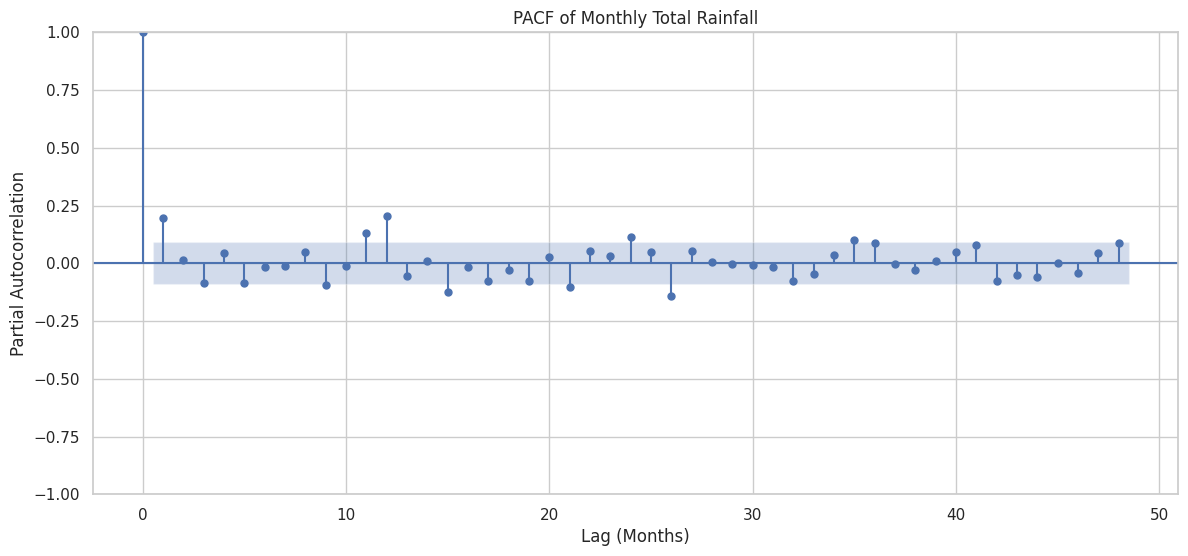

In [ ]:
# ============================================
# STEP 7.4F: PACF PLOT — TOTAL RAINFALL
# ============================================

fig, ax = plt.subplots(figsize=(14, 6))

plot_pacf(
    df_ts["total_rainfall"],
    lags=48,
    alpha=0.05,
    method="ywm",
    ax=ax
)

ax.set_title("PACF of Monthly Total Rainfall")
ax.set_xlabel("Lag (Months)")
ax.set_ylabel("Partial Autocorrelation")

plt.show()

In [ ]:
# ============================================
# STEP 7.4J: CALCULATE PACF VALUES
# ============================================

from statsmodels.tsa.stattools import pacf

pacf_values = pacf(
    df_ts["total_rainfall"],
    nlags=48,
    method="ywm"
)

pacf_table = pd.DataFrame({
    "Lag": range(len(pacf_values)),
    "PACF": pacf_values
})

display(pacf_table.round(3))

,Lag,PACF
0,0,1.000
1,1,0.197
2,2,0.015
3,3,-0.084
4,4,0.043
5,5,-0.087
6,6,-0.014
7,7,-0.012
8,8,0.047
9,9,-0.094


In [ ]:
# ============================================
# STEP 7.4K: PACF AT SEASONAL LAGS
# ============================================

seasonal_lags = [12, 24, 36, 48]

print("PACF at Seasonal Lags:")

for lag in seasonal_lags:
    print(f"Lag {lag:2d}: {pacf_values[lag]:.3f}")

PACF at Seasonal Lags:
Lag 12: 0.204
Lag 24: 0.113
Lag 36: 0.088
Lag 48: 0.089


PACF Analysis: Partial autocorrelation analysis was performed for monthly total rainfall up to 48 lags. Lag 12 retained a noticeable positive partial autocorrelation (0.204), supporting the presence of annual seasonal dependence. In contrast, the partial autocorrelations at Lags 24, 36, and 48 decreased to 0.113, 0.088, and 0.089 respectively, despite stronger correlations at these lags in the ACF. This indicates that the 12-month seasonal lag is more prominent, while much of the longer seasonal correlation is accounted for by intervening lag relationships. These findings support consideration of a 12-month seasonal structure in subsequent forecasting models.

# Step 7.5 — Lag Relationship Analysis

In [ ]:
# ============================================
# STEP 7.5A: CREATE SELECTED LAG VARIABLES
# ============================================

lag_df = df_ts[["total_rainfall"]].copy()

selected_lags = [1, 3, 6, 12, 24]

for lag in selected_lags:
    lag_df[f"lag_{lag}"] = lag_df["total_rainfall"].shift(lag)

display(lag_df.head(15))

,total_rainfall,lag_1,lag_3,lag_6,lag_12,lag_24
month,,,,,,
1982-01-01,107.1,NaN,NaN,NaN,NaN,NaN
1982-02-01,27.8,107.1,NaN,NaN,NaN,NaN
1982-03-01,160.8,27.8,NaN,NaN,NaN,NaN
1982-04-01,157.0,160.8,107.1,NaN,NaN,NaN
1982-05-01,102.2,157.0,27.8,NaN,NaN,NaN
1982-06-01,59.5,102.2,160.8,NaN,NaN,NaN
1982-07-01,76.3,59.5,157.0,107.1,NaN,NaN
1982-08-01,169.5,76.3,102.2,27.8,NaN,NaN
1982-09-01,54.1,169.5,59.5,160.8,NaN,NaN


In [ ]:
# ============================================
# STEP 7.5B: VERIFY LAG VARIABLES
# ============================================

print("Missing values created by lagging:\n")
print(lag_df.isnull().sum())

print("\nExample rows after sufficient history is available:")
display(lag_df.iloc[24:30].round(2))

Missing values created by lagging:

total_rainfall     0
lag_1              1
lag_3              3
lag_6              6
lag_12            12
lag_24            24
dtype: int64

Example rows after sufficient history is available:


,total_rainfall,lag_1,lag_3,lag_6,lag_12,lag_24
month,,,,,,
1984-01-01,251.2,370.6,212.7,190.0,246.0,107.1
1984-02-01,470.4,251.2,228.8,262.2,5.6,27.8
1984-03-01,361.3,470.4,370.6,170.8,18.6,160.8
1984-04-01,153.1,361.3,251.2,212.7,33.6,157.0
1984-05-01,186.5,153.1,470.4,228.8,160.8,102.2
1984-06-01,255.0,186.5,361.3,370.6,94.0,59.5


In [ ]:
# ============================================
# STEP 7.5C: LAG CORRELATION ANALYSIS
# ============================================

lag_correlations = {}

for lag in selected_lags:
    correlation = lag_df["total_rainfall"].corr(
        lag_df[f"lag_{lag}"]
    )

    lag_correlations[f"Lag {lag}"] = correlation

lag_correlation_table = pd.DataFrame(
    list(lag_correlations.items()),
    columns=["Lag", "Correlation"]
)

display(lag_correlation_table.round(3))

,Lag,Correlation
0,Lag 1,0.197
1,Lag 3,-0.067
2,Lag 6,-0.037
3,Lag 12,0.260
4,Lag 24,0.210


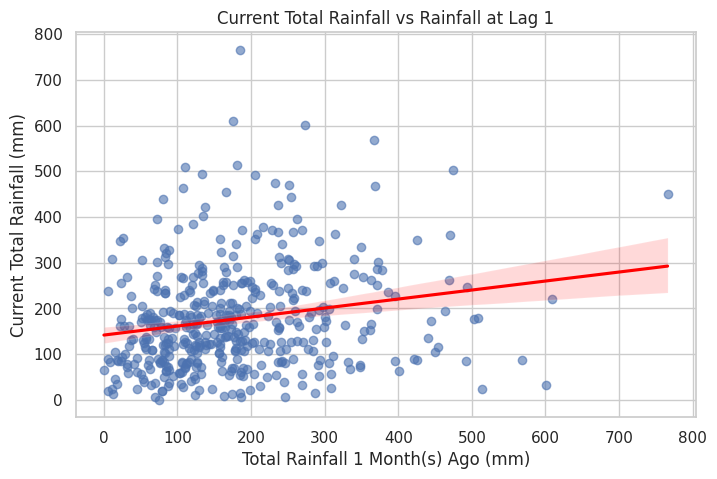

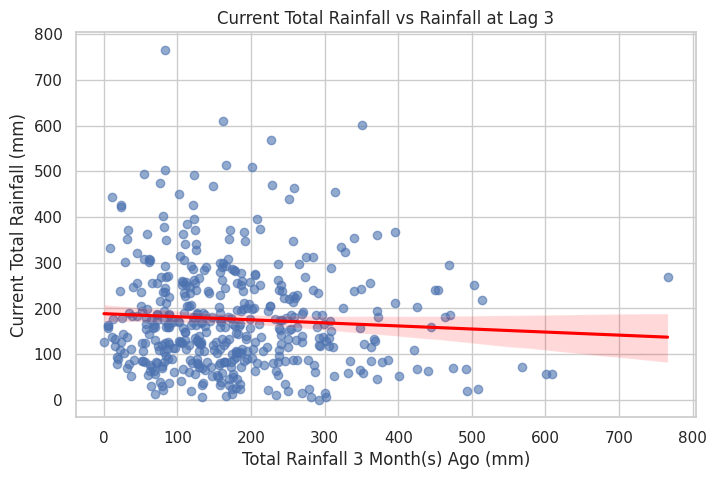

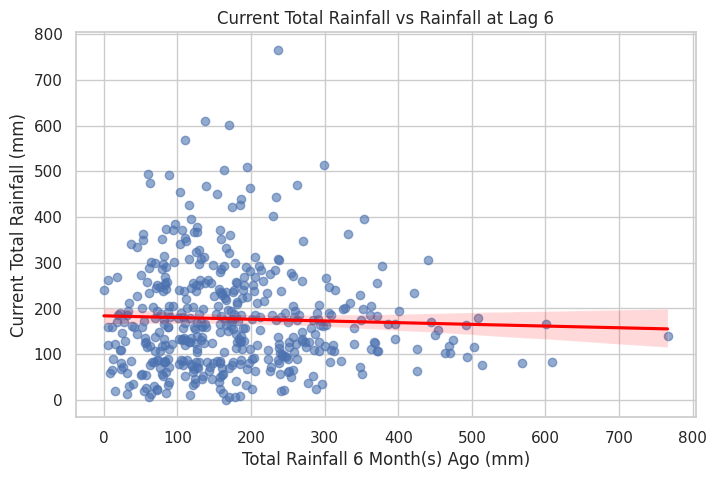

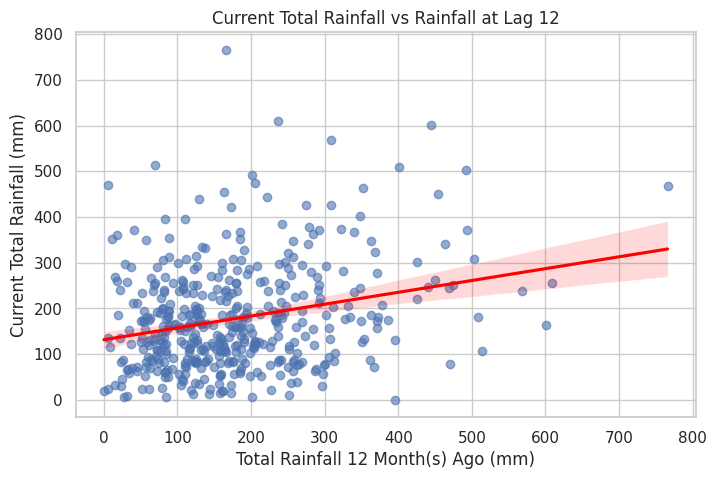

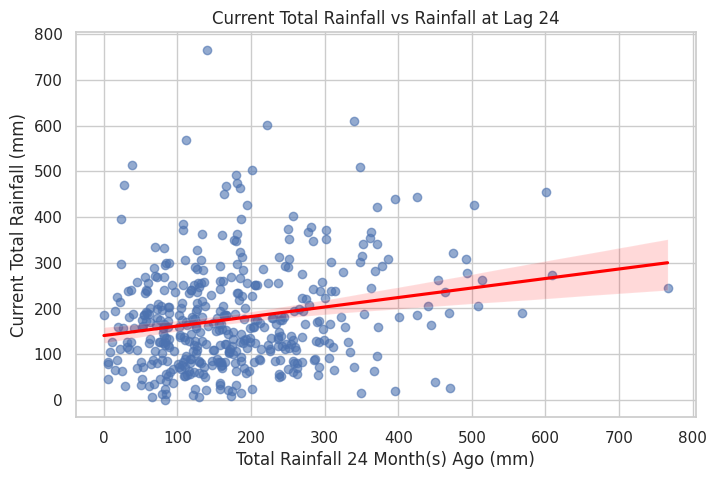

In [ ]:
# ============================================
# STEP 7.5D: SCATTER PLOTS FOR SELECTED LAGS
# ============================================

for lag in selected_lags:

    plt.figure(figsize=(8, 5))

    sns.regplot(
        data=lag_df,
        x=f"lag_{lag}",
        y="total_rainfall",
        scatter_kws={"alpha": 0.6},
        line_kws={"color": "red"}
    )

    plt.title(
        f"Current Total Rainfall vs Rainfall at Lag {lag}"
    )

    plt.xlabel(
        f"Total Rainfall {lag} Month(s) Ago (mm)"
    )

    plt.ylabel(
        "Current Total Rainfall (mm)"
    )

    plt.show()

Lag Relationship Analysis: Selected lag relationships were examined at 1, 3, 6, 12, and 24 months. Lag 12 showed the strongest positive correlation with current monthly rainfall (r = 0.260), followed by Lag 24 (r = 0.210) and Lag 1 (r = 0.197). Lags 3 and 6 showed negligible negative correlations of −0.067 and −0.037, respectively. Scatter plots supported these findings, with the clearest positive relationship observed at the 12-month lag. The results reinforce the annual seasonal structure identified through decomposition, ACF, and PACF, while also showing substantial variability between years.

# Step 8 — Forecasting Preparation and Feature Engineering

In [ ]:
# ============================================
# STEP 8.1: CREATE MODELING DATAFRAME
# ============================================

df_model = df_ts[["total_rainfall"]].copy()

print("Modeling dataframe created successfully.")
display(df_model.head())

Modeling dataframe created successfully.


,total_rainfall
month,
1982-01-01,107.1
1982-02-01,27.8
1982-03-01,160.8
1982-04-01,157.0
1982-05-01,102.2


In [ ]:
# ============================================
# STEP 8.2: CREATE CALENDAR FEATURES
# ============================================

df_model["month"] = df_model.index.month
df_model["quarter"] = df_model.index.quarter

display(df_model.head(15))

,total_rainfall,month,quarter
month,,,
1982-01-01,107.1,1,1
1982-02-01,27.8,2,1
1982-03-01,160.8,3,1
1982-04-01,157.0,4,2
1982-05-01,102.2,5,2
1982-06-01,59.5,6,2
1982-07-01,76.3,7,3
1982-08-01,169.5,8,3
1982-09-01,54.1,9,3


In [ ]:
# ============================================
# STEP 8.3: CREATE LAG FEATURES
# ============================================

lag_features = [1, 2, 3, 6, 12, 24]

for lag in lag_features:
    df_model[f"lag_{lag}"] = df_model["total_rainfall"].shift(lag)

display(df_model.head(30))

,total_rainfall,month,quarter,lag_1,lag_2,lag_3,lag_6,lag_12,lag_24
month,,,,,,,,,
1982-01-01,107.1,1,1,NaN,NaN,NaN,NaN,NaN,NaN
1982-02-01,27.8,2,1,107.1,NaN,NaN,NaN,NaN,NaN
1982-03-01,160.8,3,1,27.8,107.1,NaN,NaN,NaN,NaN
1982-04-01,157.0,4,2,160.8,27.8,107.1,NaN,NaN,NaN
1982-05-01,102.2,5,2,157.0,160.8,27.8,NaN,NaN,NaN
1982-06-01,59.5,6,2,102.2,157.0,160.8,NaN,NaN,NaN
1982-07-01,76.3,7,3,59.5,102.2,157.0,107.1,NaN,NaN
1982-08-01,169.5,8,3,76.3,59.5,102.2,27.8,NaN,NaN
1982-09-01,54.1,9,3,169.5,76.3,59.5,160.8,NaN,NaN


In [ ]:
# ============================================
# STEP 8.4: CREATE ROLLING FEATURES
# ============================================

df_model["rolling_mean_3"] = (
    df_model["total_rainfall"]
    .shift(1)
    .rolling(window=3)
    .mean()
)

df_model["rolling_mean_6"] = (
    df_model["total_rainfall"]
    .shift(1)
    .rolling(window=6)
    .mean()
)

df_model["rolling_mean_12"] = (
    df_model["total_rainfall"]
    .shift(1)
    .rolling(window=12)
    .mean()
)

display(df_model.head(20))

,total_rainfall,month,quarter,lag_1,lag_2,lag_3,lag_6,lag_12,lag_24,rolling_mean_3,rolling_mean_6,rolling_mean_12
month,,,,,,,,,,,,
1982-01-01,107.1,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1982-02-01,27.8,2,1,107.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1982-03-01,160.8,3,1,27.8,107.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1982-04-01,157.0,4,2,160.8,27.8,107.1,NaN,NaN,NaN,98.566667,NaN,NaN
1982-05-01,102.2,5,2,157.0,160.8,27.8,NaN,NaN,NaN,115.200000,NaN,NaN
1982-06-01,59.5,6,2,102.2,157.0,160.8,NaN,NaN,NaN,140.000000,NaN,NaN
1982-07-01,76.3,7,3,59.5,102.2,157.0,107.1,NaN,NaN,106.233333,102.400000,NaN
1982-08-01,169.5,8,3,76.3,59.5,102.2,27.8,NaN,NaN,79.333333,97.266667,NaN
1982-09-01,54.1,9,3,169.5,76.3,59.5,160.8,NaN,NaN,101.766667,120.883333,NaN


In [ ]:
# ============================================
# STEP 8.5: CREATE ROLLING VARIABILITY FEATURE
# ============================================

df_model["rolling_std_12"] = (
    df_model["total_rainfall"]
    .shift(1)
    .rolling(window=12)
    .std()
)

display(df_model.head(20))

,total_rainfall,month,quarter,lag_1,lag_2,lag_3,lag_6,lag_12,lag_24,rolling_mean_3,rolling_mean_6,rolling_mean_12,rolling_std_12
month,,,,,,,,,,,,,
1982-01-01,107.1,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1982-02-01,27.8,2,1,107.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1982-03-01,160.8,3,1,27.8,107.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1982-04-01,157.0,4,2,160.8,27.8,107.1,NaN,NaN,NaN,98.566667,NaN,NaN,NaN
1982-05-01,102.2,5,2,157.0,160.8,27.8,NaN,NaN,NaN,115.200000,NaN,NaN,NaN
1982-06-01,59.5,6,2,102.2,157.0,160.8,NaN,NaN,NaN,140.000000,NaN,NaN,NaN
1982-07-01,76.3,7,3,59.5,102.2,157.0,107.1,NaN,NaN,106.233333,102.400000,NaN,NaN
1982-08-01,169.5,8,3,76.3,59.5,102.2,27.8,NaN,NaN,79.333333,97.266667,NaN,NaN
1982-09-01,54.1,9,3,169.5,76.3,59.5,160.8,NaN,NaN,101.766667,120.883333,NaN,NaN


In [ ]:
# ============================================
# STEP 8.6: CYCLICAL MONTH ENCODING
# ============================================

df_model["month_sin"] = np.sin(
    2 * np.pi * df_model["month"] / 12
)

df_model["month_cos"] = np.cos(
    2 * np.pi * df_model["month"] / 12
)

display(
    df_model[
        ["month", "month_sin", "month_cos"]
    ].head(12).round(3)
)

,month,month_sin,month_cos
month,,,
1982-01-01,1,0.500,0.866
1982-02-01,2,0.866,0.500
1982-03-01,3,1.000,0.000
1982-04-01,4,0.866,-0.500
1982-05-01,5,0.500,-0.866
1982-06-01,6,0.000,-1.000
1982-07-01,7,-0.500,-0.866
1982-08-01,8,-0.866,-0.500
1982-09-01,9,-1.000,-0.000


In [ ]:
# ============================================
# STEP 8.7: INSPECT FEATURE-ENGINEERED DATA
# ============================================

print("Shape before removing lag-created NaNs:")
print(df_model.shape)

print("\nMissing values per column:")
print(df_model.isnull().sum())

display(df_model.head(30))

Shape before removing lag-created NaNs:
(462, 15)

Missing values per column:
total_rainfall      0
month               0
quarter             0
lag_1               1
lag_2               2
lag_3               3
lag_6               6
lag_12             12
lag_24             24
rolling_mean_3      3
rolling_mean_6      6
rolling_mean_12    12
rolling_std_12     12
month_sin           0
month_cos           0
dtype: int64


,total_rainfall,month,quarter,lag_1,lag_2,lag_3,lag_6,lag_12,lag_24,rolling_mean_3,rolling_mean_6,rolling_mean_12,rolling_std_12,month_sin,month_cos
month,,,,,,,,,,,,,,,
1982-01-01,107.1,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000e-01,8.660254e-01
1982-02-01,27.8,2,1,107.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.660254e-01,5.000000e-01
1982-03-01,160.8,3,1,27.8,107.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+00,6.123234e-17
1982-04-01,157.0,4,2,160.8,27.8,107.1,NaN,NaN,NaN,98.566667,NaN,NaN,NaN,8.660254e-01,-5.000000e-01
1982-05-01,102.2,5,2,157.0,160.8,27.8,NaN,NaN,NaN,115.200000,NaN,NaN,NaN,5.000000e-01,-8.660254e-01
1982-06-01,59.5,6,2,102.2,157.0,160.8,NaN,NaN,NaN,140.000000,NaN,NaN,NaN,1.224647e-16,-1.000000e+00
1982-07-01,76.3,7,3,59.5,102.2,157.0,107.1,NaN,NaN,106.233333,102.400000,NaN,NaN,-5.000000e-01,-8.660254e-01
1982-08-01,169.5,8,3,76.3,59.5,102.2,27.8,NaN,NaN,79.333333,97.266667,NaN,NaN,-8.660254e-01,-5.000000e-01
1982-09-01,54.1,9,3,169.5,76.3,59.5,160.8,NaN,NaN,101.766667,120.883333,NaN,NaN,-1.000000e+00,-1.836970e-16


In [ ]:
# ============================================
# STEP 8.8: REMOVE ROWS WITHOUT FULL HISTORY
# ============================================

df_model_clean = df_model.dropna().copy()

print("Shape before dropna:", df_model.shape)
print("Shape after dropna :", df_model_clean.shape)

print("\nFirst usable date:")
print(df_model_clean.index.min())

print("\nLast usable date:")
print(df_model_clean.index.max())

display(df_model_clean.head())

Shape before dropna: (462, 15)
Shape after dropna : (438, 15)

First usable date:
1984-01-01 00:00:00

Last usable date:
2020-06-01 00:00:00


,total_rainfall,month,quarter,lag_1,lag_2,lag_3,lag_6,lag_12,lag_24,rolling_mean_3,rolling_mean_6,rolling_mean_12,rolling_std_12,month_sin,month_cos
month,,,,,,,,,,,,,,,
1984-01-01,251.2,1,1,370.6,228.8,212.7,190.0,246.0,107.1,270.700000,239.183333,166.141667,110.550214,0.500000,8.660254e-01
1984-02-01,470.4,2,1,251.2,370.6,228.8,262.2,5.6,27.8,283.533333,249.383333,166.575000,110.901333,0.866025,5.000000e-01
1984-03-01,361.3,3,1,470.4,251.2,370.6,170.8,18.6,160.8,364.066667,284.083333,205.308333,129.222707,1.000000,6.123234e-17
1984-04-01,153.1,4,2,361.3,470.4,251.2,212.7,33.6,157.0,360.966667,315.833333,233.866667,121.868053,0.866025,-5.000000e-01
1984-05-01,186.5,5,2,153.1,361.3,470.4,228.8,160.8,102.2,328.266667,305.900000,243.825000,108.123054,0.500000,-8.660254e-01


In [ ]:
# ============================================
# STEP 8.9: DEFINE FEATURES AND TARGET
# ============================================

feature_columns = [
    "month",
    "quarter",
    "month_sin",
    "month_cos",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_6",
    "lag_12",
    "lag_24",
    "rolling_mean_3",
    "rolling_mean_6",
    "rolling_mean_12",
    "rolling_std_12"
]

X = df_model_clean[feature_columns].copy()
y = df_model_clean["total_rainfall"].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())
display(y.head())

Feature matrix shape: (438, 14)
Target shape: (438,)


,month,quarter,month_sin,month_cos,lag_1,lag_2,lag_3,lag_6,lag_12,lag_24,rolling_mean_3,rolling_mean_6,rolling_mean_12,rolling_std_12
month,,,,,,,,,,,,,,
1984-01-01,1,1,0.500000,8.660254e-01,370.6,228.8,212.7,190.0,246.0,107.1,270.700000,239.183333,166.141667,110.550214
1984-02-01,2,1,0.866025,5.000000e-01,251.2,370.6,228.8,262.2,5.6,27.8,283.533333,249.383333,166.575000,110.901333
1984-03-01,3,1,1.000000,6.123234e-17,470.4,251.2,370.6,170.8,18.6,160.8,364.066667,284.083333,205.308333,129.222707
1984-04-01,4,2,0.866025,-5.000000e-01,361.3,470.4,251.2,212.7,33.6,157.0,360.966667,315.833333,233.866667,121.868053
1984-05-01,5,2,0.500000,-8.660254e-01,153.1,361.3,470.4,228.8,160.8,102.2,328.266667,305.900000,243.825000,108.123054


,total_rainfall
month,
1984-01-01,251.2
1984-02-01,470.4
1984-03-01,361.3
1984-04-01,153.1
1984-05-01,186.5


Feature Engineering and Forecasting Preparation

A dedicated modeling dataset was created for monthly total rainfall. Calendar features (month and quarter) and cyclical month encodings using sine and cosine transformations were generated to represent the annual seasonal cycle. Historical rainfall information was incorporated through lag features at 1, 2, 3, 6, 12, and 24 months, with the 12-month lag particularly supported by the seasonal decomposition, ACF, PACF, and lag-correlation analyses.

Rolling mean features over 3, 6, and 12 months and a 12-month rolling standard deviation were also generated to represent recent rainfall levels and variability. All rolling features were shifted by one time step before calculation so that the current target value was excluded, preventing temporal leakage.

Feature generation naturally produced missing observations at the beginning of the series because sufficient historical data were unavailable. After removing these lag-generated missing rows, the modeling dataset contained 438 observations from January 1984 to June 2020. The final feature matrix contained 14 predictors, while monthly total rainfall was retained as the forecasting target.

# Step 9 — Chronological Train / Validation / Test Split

In [ ]:
# ---------------------------------------------------------
# STEP 9.3: Chronological Train / Validation / Test Split
# ---------------------------------------------------------

# Define the final 12 months as the untouched test period
test_start = pd.Timestamp("2019-07-01")

# Define the previous 12 months as the validation period
val_start = pd.Timestamp("2018-07-01")

# Chronological split
train_df = df_model_clean.loc[
    df_model_clean.index < val_start
].copy()

val_df = df_model_clean.loc[
    (df_model_clean.index >= val_start) &
    (df_model_clean.index < test_start)
].copy()

test_df = df_model_clean.loc[
    df_model_clean.index >= test_start
].copy()

print("Training shape  :", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape      :", test_df.shape)

print("\nTraining period:")
print(train_df.index.min(), "to", train_df.index.max())

print("\nValidation period:")
print(val_df.index.min(), "to", val_df.index.max())

print("\nTest period:")
print(test_df.index.min(), "to", test_df.index.max())

Training shape  : (414, 15)
Validation shape: (12, 15)
Test shape      : (12, 15)

Training period:
1984-01-01 00:00:00 to 2018-06-01 00:00:00

Validation period:
2018-07-01 00:00:00 to 2019-06-01 00:00:00

Test period:
2019-07-01 00:00:00 to 2020-06-01 00:00:00


In [ ]:
# ---------------------------------------------------------
# STEP 9.5: Verify Split Integrity
# ---------------------------------------------------------

print("Train and Validation overlap:",
      len(train_df.index.intersection(val_df.index)))

print("Train and Test overlap:",
      len(train_df.index.intersection(test_df.index)))

print("Validation and Test overlap:",
      len(val_df.index.intersection(test_df.index)))

print("\nTotal observations after split:",
      len(train_df) + len(val_df) + len(test_df))

print("Original modeling observations:",
      len(df_model_clean))

Train and Validation overlap: 0
Train and Test overlap: 0
Validation and Test overlap: 0

Total observations after split: 438
Original modeling observations: 438


In [ ]:
# ---------------------------------------------------------
# STEP 9.6: Chronological Integrity Check
# ---------------------------------------------------------

print("Training sorted:",
      train_df.index.is_monotonic_increasing)

print("Validation sorted:",
      val_df.index.is_monotonic_increasing)

print("Test sorted:",
      test_df.index.is_monotonic_increasing)

print("\nLast training date :", train_df.index.max())
print("First validation date:", val_df.index.min())

print("\nLast validation date:", val_df.index.max())
print("First test date      :", test_df.index.min())

Training sorted: True
Validation sorted: True
Test sorted: True

Last training date : 2018-06-01 00:00:00
First validation date: 2018-07-01 00:00:00

Last validation date: 2019-06-01 00:00:00
First test date      : 2019-07-01 00:00:00


In [ ]:
# ---------------------------------------------------------
# STEP 9.7: Separate Features and Target
# ---------------------------------------------------------

X_train = train_df[feature_columns].copy()
y_train = train_df["total_rainfall"].copy()

X_val = val_df[feature_columns].copy()
y_val = val_df["total_rainfall"].copy()

X_test = test_df[feature_columns].copy()
y_test = test_df["total_rainfall"].copy()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nX_val:", X_val.shape)
print("y_val:", y_val.shape)

print("\nX_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (414, 14)
y_train: (414,)

X_val: (12, 14)
y_val: (12,)

X_test: (12, 14)
y_test: (12,)


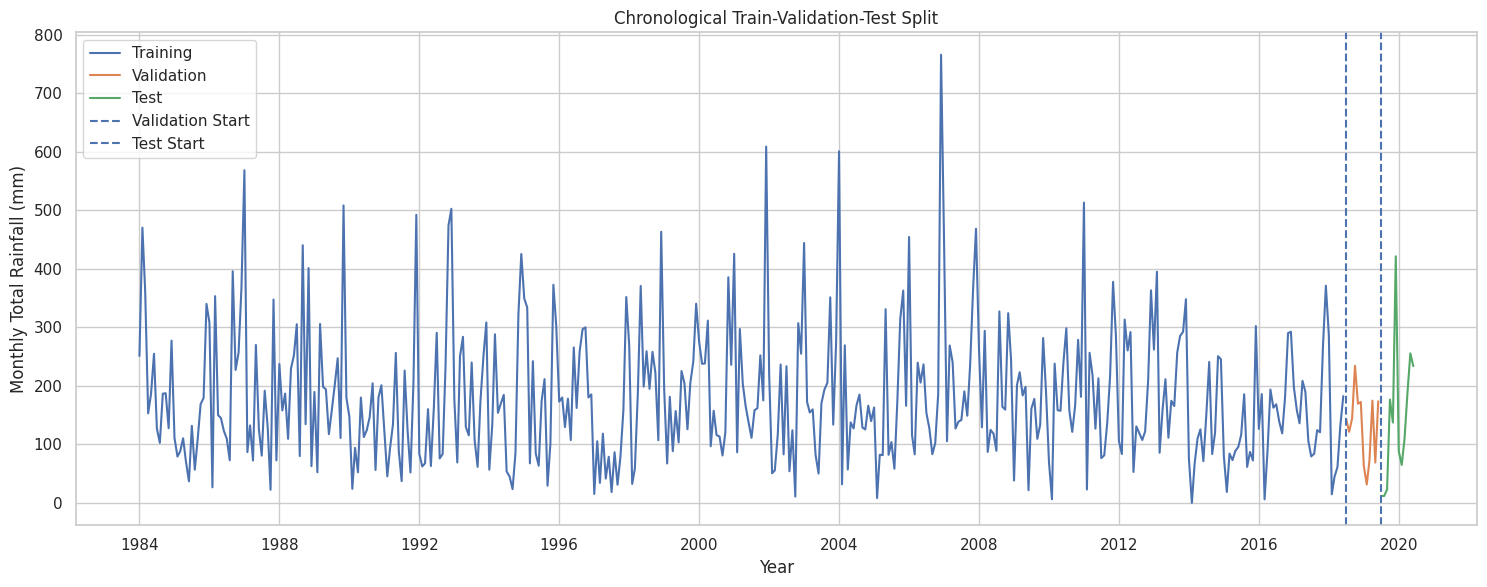

In [ ]:
# ---------------------------------------------------------
# STEP 9.8: Visualize Chronological Data Split
# ---------------------------------------------------------

plt.figure(figsize=(15, 6))

plt.plot(
    train_df.index,
    train_df["total_rainfall"],
    label="Training"
)

plt.plot(
    val_df.index,
    val_df["total_rainfall"],
    label="Validation"
)

plt.plot(
    test_df.index,
    test_df["total_rainfall"],
    label="Test"
)

plt.axvline(
    val_df.index.min(),
    linestyle="--",
    label="Validation Start"
)

plt.axvline(
    test_df.index.min(),
    linestyle="--",
    label="Test Start"
)

plt.title("Chronological Train-Validation-Test Split")
plt.xlabel("Year")
plt.ylabel("Monthly Total Rainfall (mm)")
plt.legend()
plt.tight_layout()
plt.show()

Chronological Train–Validation–Test Split

The feature-engineered dataset containing 438 monthly observations was divided chronologically to preserve temporal order and prevent future-data leakage. The training set contained 414 observations from January 1984 to June 2018. The subsequent 12 months from July 2018 to June 2019 were reserved for validation, while the final 12 months from July 2019 to June 2020 were retained as the test set. The 12-month test horizon was selected to align evaluation with the business objective of forecasting rainfall for one year. Integrity checks confirmed zero overlap among the three datasets, preservation of chronological ordering, and retention of all 438 modeling observations. Random shuffling was not used because it would violate the temporal structure of the forecasting problem.

# Step 10 — Baseline Forecasting Models

In [ ]:
# ---------------------------------------------------------
# STEP 10.3: Naive Baseline - Validation Forecast
# ---------------------------------------------------------

# Last actual rainfall available at the end of training
last_train_rainfall = y_train.iloc[-1]

# Use the same last observed value for all 12 validation months
naive_val_pred = np.repeat(
    last_train_rainfall,
    len(y_val)
)

print("Last training rainfall:")
print(last_train_rainfall)

print("\nNumber of validation forecasts:")
print(len(naive_val_pred))

print("\nNaive validation predictions:")
print(naive_val_pred)

Last training rainfall:
182.6

Number of validation forecasts:
12

Naive validation predictions:
[182.6 182.6 182.6 182.6 182.6 182.6 182.6 182.6 182.6 182.6 182.6 182.6]


In [ ]:
# ---------------------------------------------------------
# STEP 10.5: Seasonal Naive Baseline - Validation Forecast
# ---------------------------------------------------------

seasonal_naive_val_pred = (
    df_ts["total_rainfall"]
    .shift(12)
    .loc[y_val.index]
    .values
)

print("Number of seasonal naive forecasts:")
print(len(seasonal_naive_val_pred))

print("\nSeasonal Naive validation predictions:")
print(seasonal_naive_val_pred)

Number of seasonal naive forecasts:
12

Seasonal Naive validation predictions:
[ 79.6  84.2 124.4 120.8 268.6 371.2 287.   14.8  44.6  61.2 132.2 182.6]


In [ ]:
# ---------------------------------------------------------
# STEP 10.6: Verify Seasonal Naive Forecast Alignment
# ---------------------------------------------------------

seasonal_naive_check = pd.DataFrame({
    "Actual_Rainfall": y_val.values,
    "Seasonal_Naive_Prediction": seasonal_naive_val_pred
}, index=y_val.index)

seasonal_naive_check["Source_Month"] = (
    seasonal_naive_check.index - pd.DateOffset(months=12)
)

display(seasonal_naive_check)

,Actual_Rainfall,Seasonal_Naive_Prediction,Source_Month
month,,,
2018-07-01,143.2,79.6,2017-07-01
2018-08-01,121.6,84.2,2017-08-01
2018-09-01,144.4,124.4,2017-09-01
2018-10-01,234.4,120.8,2017-10-01
2018-11-01,169.6,268.6,2017-11-01
2018-12-01,172.6,371.2,2017-12-01
2019-01-01,63.6,287.0,2018-01-01
2019-02-01,31.6,14.8,2018-02-01
2019-03-01,72.2,44.6,2018-03-01


In [ ]:
# ---------------------------------------------------------
# STEP 10.8: Evaluate Baseline Models
# ---------------------------------------------------------

from sklearn.metrics import mean_absolute_error, mean_squared_error

# Naive baseline
naive_mae = mean_absolute_error(
    y_val,
    naive_val_pred
)

naive_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        naive_val_pred
    )
)

# Seasonal Naive baseline
seasonal_naive_mae = mean_absolute_error(
    y_val,
    seasonal_naive_val_pred
)

seasonal_naive_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        seasonal_naive_val_pred
    )
)

print("NAIVE BASELINE")
print("----------------")
print(f"MAE  : {naive_mae:.2f} mm")
print(f"RMSE : {naive_rmse:.2f} mm")

print("\nSEASONAL NAIVE BASELINE")
print("-----------------------")
print(f"MAE  : {seasonal_naive_mae:.2f} mm")
print(f"RMSE : {seasonal_naive_rmse:.2f} mm")

NAIVE BASELINE
----------------
MAE  : 60.33 mm
RMSE : 77.39 mm

SEASONAL NAIVE BASELINE
-----------------------
MAE  : 82.13 mm
RMSE : 106.43 mm


In [ ]:
# ---------------------------------------------------------
# STEP 10.9: Baseline Model Comparison
# ---------------------------------------------------------

baseline_results = pd.DataFrame({
    "Model": [
        "Naive",
        "Seasonal Naive"
    ],
    "MAE_mm": [
        naive_mae,
        seasonal_naive_mae
    ],
    "RMSE_mm": [
        naive_rmse,
        seasonal_naive_rmse
    ]
})

baseline_results = (
    baseline_results
    .sort_values("RMSE_mm")
    .reset_index(drop=True)
)

display(baseline_results.round(2))

,Model,MAE_mm,RMSE_mm
0,Naive,60.33,77.39
1,Seasonal Naive,82.13,106.43


In [ ]:
# ---------------------------------------------------------
# STEP 10.10: Actual vs Baseline Forecasts
# ---------------------------------------------------------

baseline_comparison = pd.DataFrame({
    "Actual": y_val.values,
    "Naive": naive_val_pred,
    "Seasonal_Naive": seasonal_naive_val_pred
}, index=y_val.index)

display(baseline_comparison.round(2))

,Actual,Naive,Seasonal_Naive
month,,,
2018-07-01,143.2,182.6,79.6
2018-08-01,121.6,182.6,84.2
2018-09-01,144.4,182.6,124.4
2018-10-01,234.4,182.6,120.8
2018-11-01,169.6,182.6,268.6
2018-12-01,172.6,182.6,371.2
2019-01-01,63.6,182.6,287.0
2019-02-01,31.6,182.6,14.8
2019-03-01,72.2,182.6,44.6


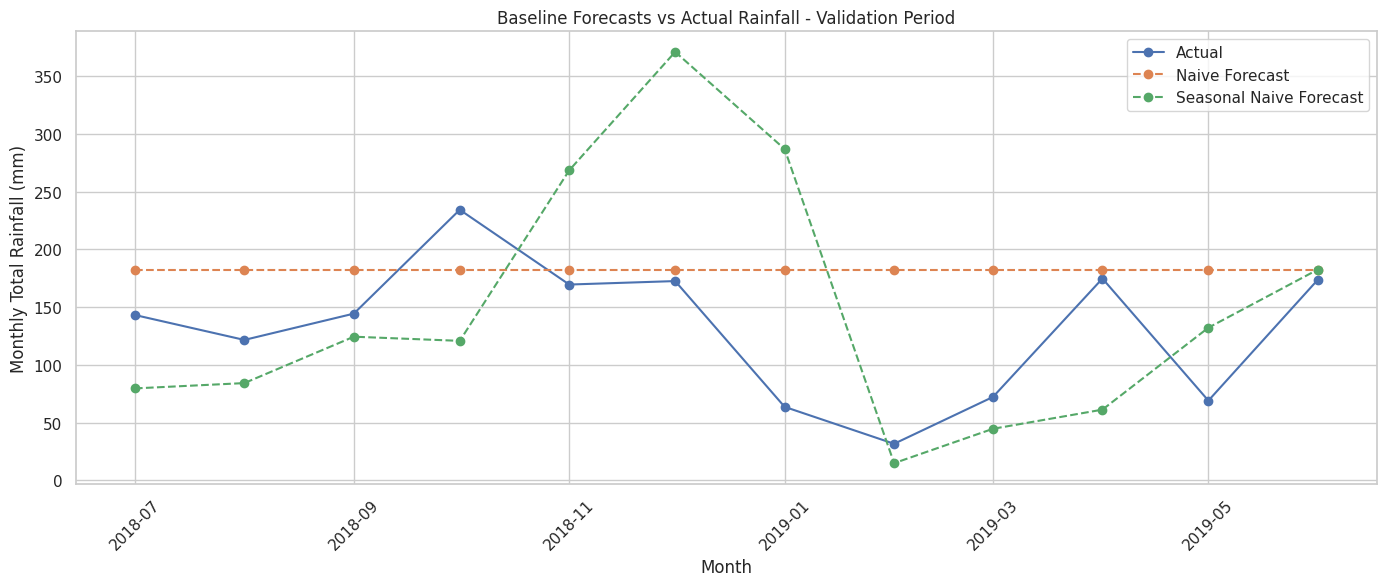

In [ ]:
# ---------------------------------------------------------
# STEP 10.11: Plot Baseline Forecasts
# ---------------------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    y_val.index,
    y_val.values,
    marker="o",
    label="Actual"
)

plt.plot(
    y_val.index,
    naive_val_pred,
    marker="o",
    linestyle="--",
    label="Naive Forecast"
)

plt.plot(
    y_val.index,
    seasonal_naive_val_pred,
    marker="o",
    linestyle="--",
    label="Seasonal Naive Forecast"
)

plt.title("Baseline Forecasts vs Actual Rainfall - Validation Period")
plt.xlabel("Month")
plt.ylabel("Monthly Total Rainfall (mm)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Step 11 — SARIMA Forecasting Model

In [ ]:
# ---------------------------------------------------------
# STEP 11.5: Prepare SARIMA Data
# ---------------------------------------------------------

sarima_train = df_ts.loc[
    df_ts.index < pd.Timestamp("2018-07-01"),
    "total_rainfall"
].copy()

sarima_val = df_ts.loc[
    (df_ts.index >= pd.Timestamp("2018-07-01")) &
    (df_ts.index < pd.Timestamp("2019-07-01")),
    "total_rainfall"
].copy()

print("SARIMA training observations :", len(sarima_train))
print("SARIMA validation observations:", len(sarima_val))

print("\nSARIMA training period:")
print(sarima_train.index.min(), "to", sarima_train.index.max())

print("\nSARIMA validation period:")
print(sarima_val.index.min(), "to", sarima_val.index.max())

SARIMA training observations : 438
SARIMA validation observations: 12

SARIMA training period:
1982-01-01 00:00:00 to 2018-06-01 00:00:00

SARIMA validation period:
2018-07-01 00:00:00 to 2019-06-01 00:00:00


In [ ]:
# ---------------------------------------------------------
# STEP 11.6: Verify Monthly Frequency
# ---------------------------------------------------------

print("Inferred training frequency:",
      pd.infer_freq(sarima_train.index))

print("Inferred validation frequency:",
      pd.infer_freq(sarima_val.index))

print("\nTraining missing values:",
      sarima_train.isnull().sum())

print("Validation missing values:",
      sarima_val.isnull().sum())

Inferred training frequency: MS
Inferred validation frequency: MS

Training missing values: 0
Validation missing values: 0


In [ ]:
# ---------------------------------------------------------
# STEP 11.8: Controlled SARIMA Candidate Search
# ---------------------------------------------------------

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

sarima_candidates = [
    ((0, 0, 0), (1, 0, 0, 12)),
    ((1, 0, 0), (1, 0, 0, 12)),
    ((0, 0, 1), (1, 0, 0, 12)),
    ((1, 0, 1), (1, 0, 0, 12)),
    ((1, 0, 0), (0, 0, 1, 12)),
    ((1, 0, 1), (0, 0, 1, 12)),
    ((1, 0, 1), (1, 0, 1, 12)),

    ((0, 0, 0), (1, 1, 0, 12)),
    ((1, 0, 0), (1, 1, 0, 12)),
    ((0, 0, 1), (1, 1, 0, 12)),
    ((1, 0, 1), (1, 1, 0, 12)),
    ((1, 0, 1), (0, 1, 1, 12))
]

sarima_results = []

for order, seasonal_order in sarima_candidates:

    try:
        model = SARIMAX(
            sarima_train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted_model = model.fit(disp=False)

        forecast = fitted_model.forecast(
            steps=len(sarima_val)
        )

        mae = mean_absolute_error(
            sarima_val,
            forecast
        )

        rmse = np.sqrt(
            mean_squared_error(
                sarima_val,
                forecast
            )
        )

        sarima_results.append({
            "order": order,
            "seasonal_order": seasonal_order,
            "AIC": fitted_model.aic,
            "MAE_mm": mae,
            "RMSE_mm": rmse
        })

    except Exception as e:
        print(
            f"Model {order} x {seasonal_order} failed: {e}"
        )

sarima_results_df = pd.DataFrame(sarima_results)

sarima_results_df = (
    sarima_results_df
    .sort_values("RMSE_mm")
    .reset_index(drop=True)
)

display(sarima_results_df.round(2))

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

,order,seasonal_order,AIC,MAE_mm,RMSE_mm
0,"(1, 0, 1)","(1, 0, 0, 12)",5229.24,52.39,66.33
1,"(1, 0, 1)","(0, 0, 1, 12)",5223.90,53.15,67.01
2,"(1, 0, 0)","(1, 0, 0, 12)",5323.50,64.32,78.99
3,"(0, 0, 1)","(1, 0, 0, 12)",5348.54,70.78,83.80
4,"(1, 0, 1)","(1, 0, 1, 12)",5154.62,68.78,84.61
5,"(1, 0, 1)","(0, 1, 1, 12)",4986.96,71.05,87.85
6,"(1, 0, 0)","(1, 1, 0, 12)",5150.39,67.91,88.16
7,"(0, 0, 1)","(1, 1, 0, 12)",5163.19,68.02,88.20
8,"(0, 0, 0)","(1, 0, 0, 12)",5367.77,74.51,88.24
9,"(0, 0, 0)","(1, 1, 0, 12)",5167.74,68.55,88.26


In [ ]:
# ---------------------------------------------------------
# STEP 11.10: Select Best SARIMA Candidate
# ---------------------------------------------------------

best_sarima_row = sarima_results_df.iloc[0]

best_order = best_sarima_row["order"]
best_seasonal_order = best_sarima_row["seasonal_order"]

print("Best SARIMA order:")
print(best_order)

print("\nBest seasonal order:")
print(best_seasonal_order)

print("\nValidation MAE:")
print(f"{best_sarima_row['MAE_mm']:.2f} mm")

print("\nValidation RMSE:")
print(f"{best_sarima_row['RMSE_mm']:.2f} mm")

print("\nAIC:")
print(f"{best_sarima_row['AIC']:.2f}")

Best SARIMA order:
(1, 0, 1)

Best seasonal order:
(1, 0, 0, 12)

Validation MAE:
52.39 mm

Validation RMSE:
66.33 mm

AIC:
5229.24


In [ ]:
# ---------------------------------------------------------
# STEP 11.11: Fit Best SARIMA Model
# ---------------------------------------------------------

best_sarima_model = SARIMAX(
    sarima_train,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

best_sarima_fit = best_sarima_model.fit(
    disp=False
)

print("Best SARIMA model fitted successfully.")
print("\nSelected order:", best_order)
print("Selected seasonal order:", best_seasonal_order)

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Best SARIMA model fitted successfully.

Selected order: (1, 0, 1)
Selected seasonal order: (1, 0, 0, 12)


In [ ]:
# ---------------------------------------------------------
# STEP 11.12: 12-Month SARIMA Validation Forecast
# ---------------------------------------------------------

sarima_val_forecast = best_sarima_fit.get_forecast(
    steps=12
)

sarima_val_pred = sarima_val_forecast.predicted_mean

sarima_val_pred.index = sarima_val.index

print("Number of forecasts:", len(sarima_val_pred))

display(
    pd.DataFrame({
        "Actual": sarima_val,
        "SARIMA_Prediction": sarima_val_pred
    }).round(2)
)

Number of forecasts: 12


,Actual,SARIMA_Prediction
month,,
2018-07-01,143.2,148.30
2018-08-01,121.6,149.44
2018-09-01,144.4,159.63
2018-10-01,234.4,158.69
2018-11-01,169.6,196.21
2018-12-01,172.6,222.25
2019-01-01,63.6,200.84
2019-02-01,31.6,131.65
2019-03-01,72.2,139.20


In [ ]:
# ---------------------------------------------------------
# STEP 11.13: Evaluate Best SARIMA
# ---------------------------------------------------------

sarima_mae = mean_absolute_error(
    sarima_val,
    sarima_val_pred
)

sarima_rmse = np.sqrt(
    mean_squared_error(
        sarima_val,
        sarima_val_pred
    )
)

print("BEST SARIMA VALIDATION PERFORMANCE")
print("----------------------------------")
print(f"MAE  : {sarima_mae:.2f} mm")
print(f"RMSE : {sarima_rmse:.2f} mm")

BEST SARIMA VALIDATION PERFORMANCE
----------------------------------
MAE  : 52.39 mm
RMSE : 66.33 mm


In [ ]:
# ---------------------------------------------------------
# STEP 11.14: SARIMA vs Baselines
# ---------------------------------------------------------

model_comparison = pd.DataFrame({
    "Model": [
        "Naive",
        "Seasonal Naive",
        "SARIMA"
    ],
    "MAE_mm": [
        naive_mae,
        seasonal_naive_mae,
        sarima_mae
    ],
    "RMSE_mm": [
        naive_rmse,
        seasonal_naive_rmse,
        sarima_rmse
    ]
})

model_comparison = (
    model_comparison
    .sort_values("RMSE_mm")
    .reset_index(drop=True)
)

display(model_comparison.round(2))

,Model,MAE_mm,RMSE_mm
0,SARIMA,52.39,66.33
1,Naive,60.33,77.39
2,Seasonal Naive,82.13,106.43


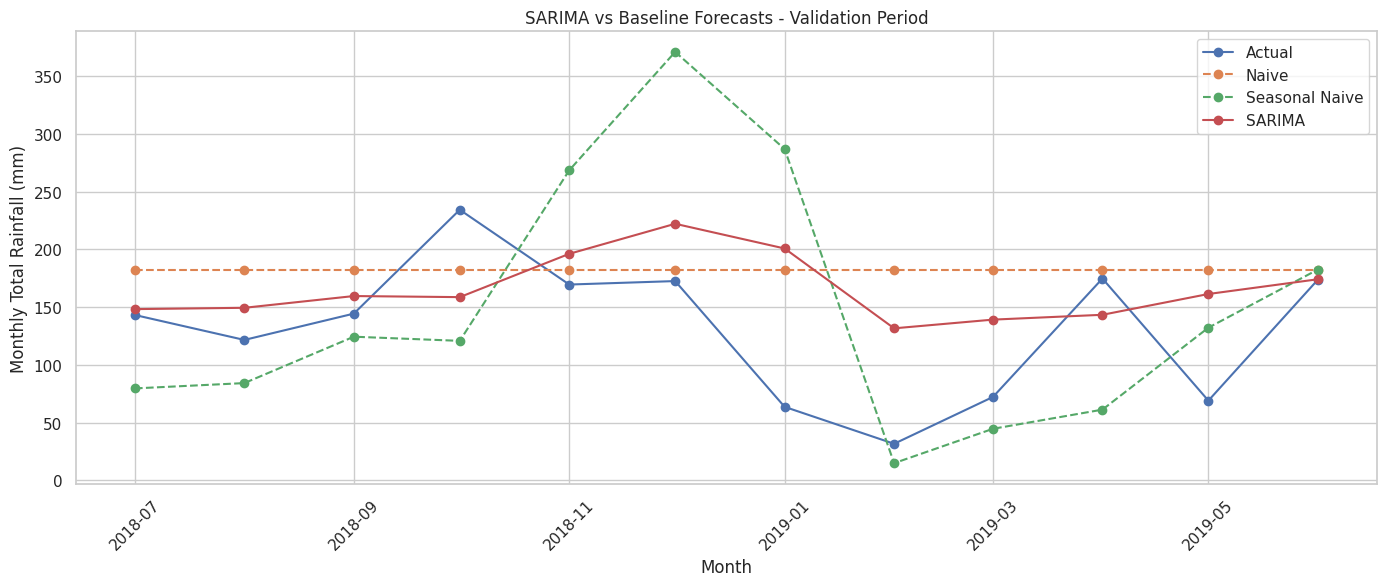

In [ ]:
# ---------------------------------------------------------
# STEP 11.15: Validation Forecast Comparison
# ---------------------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    sarima_val.index,
    sarima_val.values,
    marker="o",
    label="Actual"
)

plt.plot(
    sarima_val.index,
    naive_val_pred,
    marker="o",
    linestyle="--",
    label="Naive"
)

plt.plot(
    sarima_val.index,
    seasonal_naive_val_pred,
    marker="o",
    linestyle="--",
    label="Seasonal Naive"
)

plt.plot(
    sarima_val.index,
    sarima_val_pred.values,
    marker="o",
    label="SARIMA"
)

plt.title(
    "SARIMA vs Baseline Forecasts - Validation Period"
)

plt.xlabel("Month")
plt.ylabel("Monthly Total Rainfall (mm)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

Residual count: 438
Residual mean : 1.649
Residual std  : 112.039


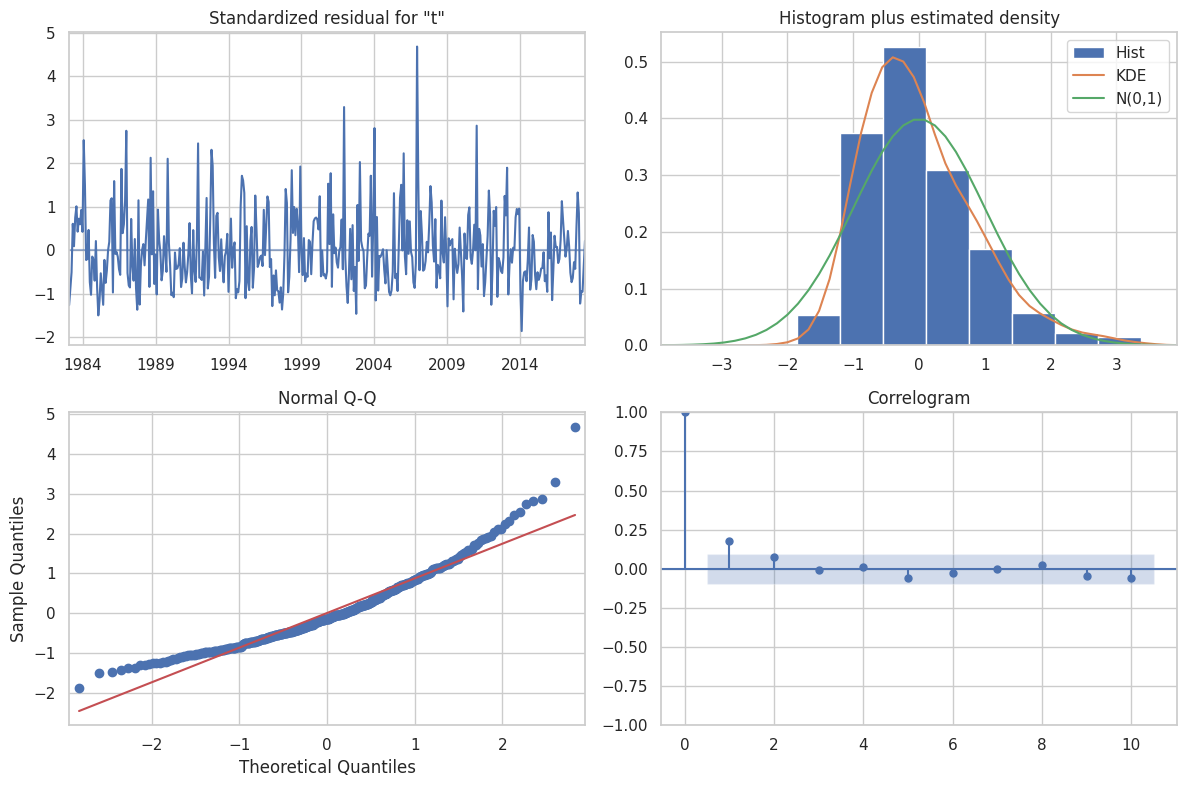

In [ ]:
# ---------------------------------------------------------
# STEP 11.16: SARIMA Training Residual Diagnostics
# ---------------------------------------------------------

sarima_residuals = best_sarima_fit.resid.dropna()

print("Residual count:", len(sarima_residuals))
print("Residual mean :", round(sarima_residuals.mean(), 3))
print("Residual std  :", round(sarima_residuals.std(), 3))

fig = best_sarima_fit.plot_diagnostics(
    figsize=(12, 8)
)

plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------
# STEP 11.17: Ljung-Box Test
# ---------------------------------------------------------

from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box_results = acorr_ljungbox(
    sarima_residuals,
    lags=[12, 24],
    return_df=True
)

display(ljung_box_results)

,lb_stat,lb_pvalue
12,20.253774,0.062435
24,47.785752,0.002683


SARIMA Modeling

A controlled search across 12 SARIMA configurations was performed using monthly total rainfall from January 1982 to June 2018, with July 2018–June 2019 retained for validation. The best forecasting performance was achieved by SARIMA(1,0,1)(1,0,0)₁₂, producing a validation MAE of 52.39 mm and RMSE of 66.33 mm. This represented approximately 13.2% lower MAE and 14.3% lower RMSE than the Naive baseline, making SARIMA the best-performing model at this stage.

Residual diagnostics showed a residual mean close to zero, although deviations from normality and extreme residuals remained. The Ljung–Box test showed no statistically significant residual autocorrelation through Lag 12 at the 5% level (p = 0.062), but significant autocorrelation remained through Lag 24 (p = 0.0027). Therefore, SARIMA captured meaningful seasonal and temporal structure but did not fully explain all longer-range dependencies and extreme rainfall variation.

# Step 12 — Machine Learning Forecasting Model

In [ ]:
# ---------------------------------------------------------
# STEP 12.4: Train Initial Random Forest Regressor
# ---------------------------------------------------------

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest model trained successfully.")
print("Number of training observations:", len(X_train))
print("Number of features:", X_train.shape[1])

Random Forest model trained successfully.
Number of training observations: 414
Number of features: 14


In [ ]:
# ---------------------------------------------------------
# STEP 12.5: Function to Create Features for One Future Month
# ---------------------------------------------------------

def create_future_features(history, forecast_date):

    history = pd.Series(history).astype(float)

    # Calendar features
    month = forecast_date.month
    quarter = forecast_date.quarter

    month_sin = np.sin(2 * np.pi * month / 12)
    month_cos = np.cos(2 * np.pi * month / 12)

    # Lag features
    lag_1 = history.iloc[-1]
    lag_2 = history.iloc[-2]
    lag_3 = history.iloc[-3]
    lag_6 = history.iloc[-6]
    lag_12 = history.iloc[-12]
    lag_24 = history.iloc[-24]

    # Rolling features
    rolling_mean_3 = history.iloc[-3:].mean()
    rolling_mean_6 = history.iloc[-6:].mean()
    rolling_mean_12 = history.iloc[-12:].mean()

    rolling_std_12 = history.iloc[-12:].std()

    features = pd.DataFrame({
        "month": [month],
        "quarter": [quarter],
        "month_sin": [month_sin],
        "month_cos": [month_cos],
        "lag_1": [lag_1],
        "lag_2": [lag_2],
        "lag_3": [lag_3],
        "lag_6": [lag_6],
        "lag_12": [lag_12],
        "lag_24": [lag_24],
        "rolling_mean_3": [rolling_mean_3],
        "rolling_mean_6": [rolling_mean_6],
        "rolling_mean_12": [rolling_mean_12],
        "rolling_std_12": [rolling_std_12]
    })

    # Guarantee same column order used during training
    features = features[feature_columns]

    return features

In [ ]:
# ---------------------------------------------------------
# STEP 12.7: Verify First Validation Feature Row
# ---------------------------------------------------------

history_before_validation = df_ts.loc[
    df_ts.index < pd.Timestamp("2018-07-01"),
    "total_rainfall"
].copy()

first_forecast_date = pd.Timestamp("2018-07-01")

first_future_features = create_future_features(
    history_before_validation,
    first_forecast_date
)

print("Last known historical date:")
print(history_before_validation.index.max())

print("\nForecast date:")
print(first_forecast_date)

print("\nGenerated features:")
display(first_future_features.round(3))

Last known historical date:
2018-06-01 00:00:00

Forecast date:
2018-07-01 00:00:00

Generated features:


,month,quarter,month_sin,month_cos,lag_1,lag_2,lag_3,lag_6,lag_12,lag_24,rolling_mean_3,rolling_mean_6,rolling_mean_12,rolling_std_12
0,7,3,-0.5,-0.866,182.6,132.2,61.2,287.0,79.6,168.6,125.333,120.4,147.6,109.188


In [ ]:
# ---------------------------------------------------------
# STEP 12.8: Recursive Multi-Step Forecast Function
# ---------------------------------------------------------

def recursive_forecast(
    model,
    initial_history,
    forecast_dates
):

    history = initial_history.copy().astype(float)
    predictions = []

    for forecast_date in forecast_dates:

        # Generate features using only currently available history
        X_future = create_future_features(
            history,
            forecast_date
        )

        # Predict rainfall
        prediction = model.predict(X_future)[0]

        # Rainfall cannot physically be negative
        prediction = max(0.0, prediction)

        predictions.append(prediction)

        # Add prediction to history for next recursive step
        history.loc[forecast_date] = prediction

    return pd.Series(
        predictions,
        index=forecast_dates,
        name="RF_Prediction"
    )

In [ ]:
# ---------------------------------------------------------
# STEP 12.9: Generate 12-Month Recursive RF Forecast
# ---------------------------------------------------------

rf_val_pred = recursive_forecast(
    model=rf_model,
    initial_history=history_before_validation,
    forecast_dates=y_val.index
)

print("Number of RF forecasts:", len(rf_val_pred))

rf_validation_comparison = pd.DataFrame({
    "Actual": y_val,
    "RF_Prediction": rf_val_pred
})

display(
    rf_validation_comparison.round(2)
)

Number of RF forecasts: 12


,Actual,RF_Prediction
month,,
2018-07-01,143.2,139.71
2018-08-01,121.6,135.43
2018-09-01,144.4,135.41
2018-10-01,234.4,141.94
2018-11-01,169.6,228.19
2018-12-01,172.6,273.54
2019-01-01,63.6,282.05
2019-02-01,31.6,146.70
2019-03-01,72.2,167.57


In [ ]:
# ---------------------------------------------------------
# STEP 12.10: Evaluate Random Forest
# ---------------------------------------------------------

rf_mae = mean_absolute_error(
    y_val,
    rf_val_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        rf_val_pred
    )
)

print("RANDOM FOREST VALIDATION PERFORMANCE")
print("------------------------------------")
print(f"MAE  : {rf_mae:.2f} mm")
print(f"RMSE : {rf_rmse:.2f} mm")

RANDOM FOREST VALIDATION PERFORMANCE
------------------------------------
MAE  : 69.63 mm
RMSE : 91.23 mm


### 12.11 — Update model comparison

In [ ]:
model_comparison_step12 = pd.DataFrame({
    "Model": [
        "Naive",
        "Seasonal Naive",
        "SARIMA",
        "Random Forest"
    ],
    "MAE_mm": [
        naive_mae,
        seasonal_naive_mae,
        sarima_mae,
        rf_mae
    ],
    "RMSE_mm": [
        naive_rmse,
        seasonal_naive_rmse,
        sarima_rmse,
        rf_rmse
    ]
})

model_comparison_step12 = (
    model_comparison_step12
    .sort_values("RMSE_mm")
    .reset_index(drop=True)
)

display(model_comparison_step12.round(2))

,Model,MAE_mm,RMSE_mm
0,SARIMA,52.39,66.33
1,Naive,60.33,77.39
2,Random Forest,69.63,91.23
3,Seasonal Naive,82.13,106.43


### 12.12 — Plot all models

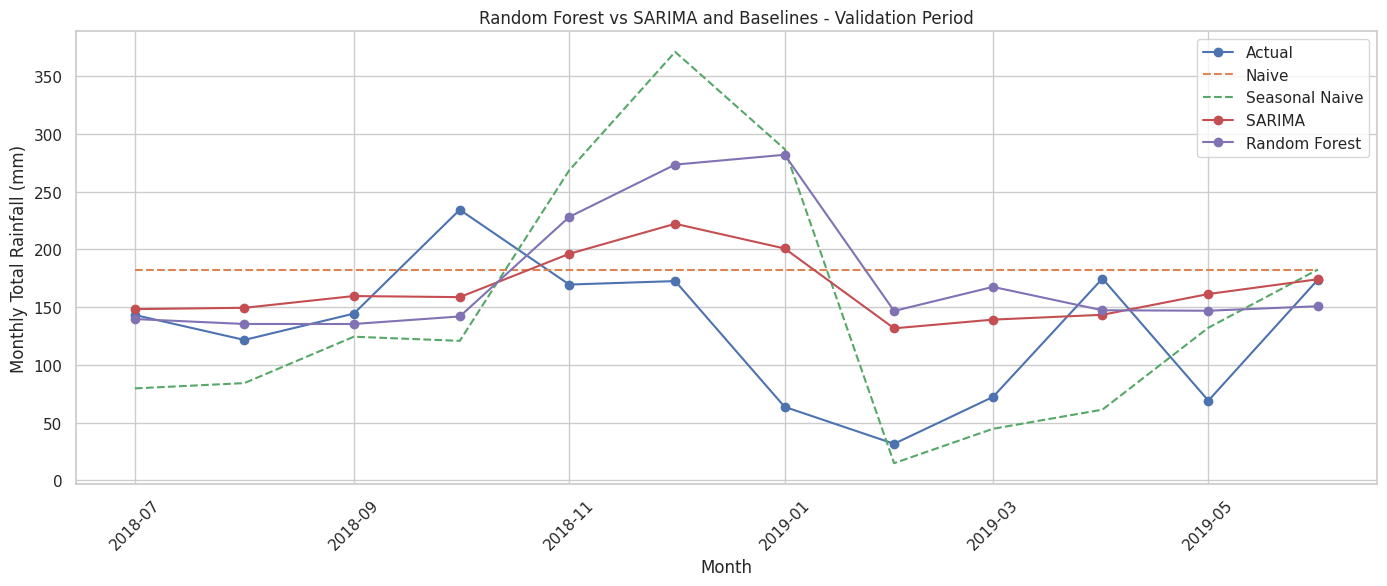

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    y_val.index,
    y_val.values,
    marker="o",
    label="Actual"
)

plt.plot(
    y_val.index,
    naive_val_pred,
    linestyle="--",
    label="Naive"
)

plt.plot(
    y_val.index,
    seasonal_naive_val_pred,
    linestyle="--",
    label="Seasonal Naive"
)

plt.plot(
    y_val.index,
    sarima_val_pred.values,
    marker="o",
    label="SARIMA"
)

plt.plot(
    y_val.index,
    rf_val_pred.values,
    marker="o",
    label="Random Forest"
)

plt.title(
    "Random Forest vs SARIMA and Baselines - Validation Period"
)

plt.xlabel("Month")
plt.ylabel("Monthly Total Rainfall (mm)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### 12.13 — Feature importance

In [ ]:
rf_feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": rf_model.feature_importances_
})

rf_feature_importance = (
    rf_feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(rf_feature_importance.round(4))

,Feature,Importance
0,month_cos,0.2015
1,lag_12,0.1076
2,lag_24,0.0899
3,lag_3,0.0807
4,rolling_std_12,0.0751
5,lag_2,0.0688
6,lag_1,0.0687
7,lag_6,0.0683
8,rolling_mean_6,0.0603
9,month,0.0587


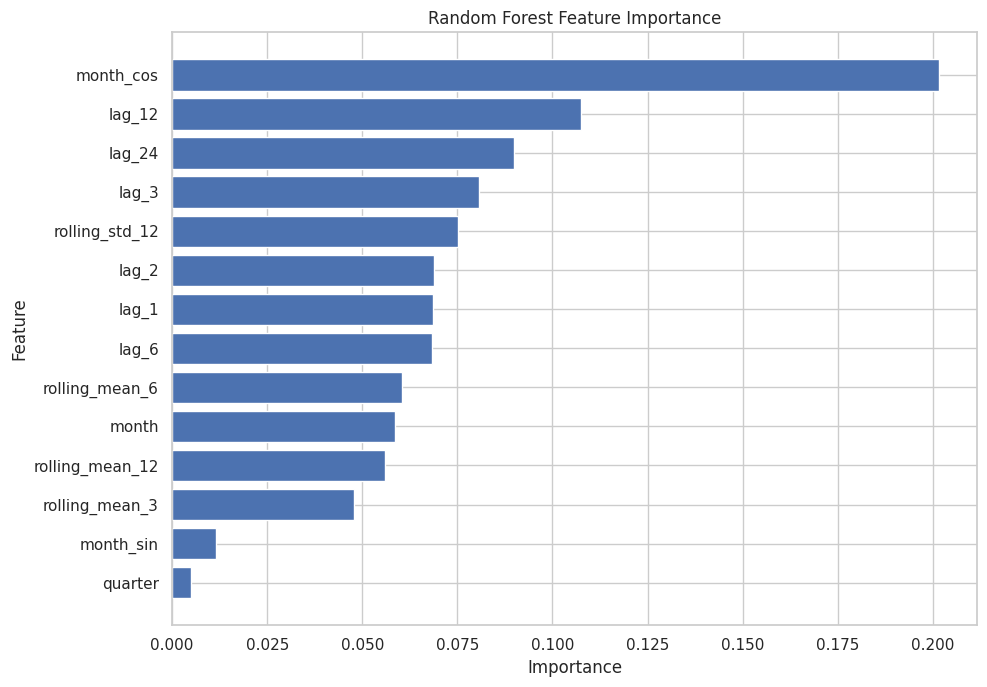

In [ ]:
plt.figure(figsize=(10, 7))

plt.barh(
    rf_feature_importance["Feature"],
    rf_feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### 12.14 — Most important next diagnostic: training vs validation

In [ ]:
rf_train_pred = rf_model.predict(X_train)

rf_train_mae = mean_absolute_error(
    y_train,
    rf_train_pred
)

rf_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        rf_train_pred
    )
)

print("RANDOM FOREST TRAINING PERFORMANCE")
print("----------------------------------")
print(f"MAE  : {rf_train_mae:.2f} mm")
print(f"RMSE : {rf_train_rmse:.2f} mm")

print("\nRANDOM FOREST VALIDATION PERFORMANCE")
print("------------------------------------")
print(f"MAE  : {rf_mae:.2f} mm")
print(f"RMSE : {rf_rmse:.2f} mm")

RANDOM FOREST TRAINING PERFORMANCE
----------------------------------
MAE  : 29.94 mm
RMSE : 39.59 mm

RANDOM FOREST VALIDATION PERFORMANCE
------------------------------------
MAE  : 69.63 mm
RMSE : 91.23 mm


In [ ]:
# ---------------------------------------------------------
# STEP 12.16: Controlled Random Forest Tuning
# ---------------------------------------------------------

rf_tuning_results = []

max_depth_values = [4, 6, 8, 10]
min_samples_leaf_values = [2, 4, 6]

for depth in max_depth_values:

    for leaf in min_samples_leaf_values:

        model = RandomForestRegressor(
            n_estimators=300,
            max_depth=depth,
            min_samples_split=2,
            min_samples_leaf=leaf,
            random_state=42,
            n_jobs=-1
        )

        # Train only on training data
        model.fit(X_train, y_train)

        # Training predictions
        train_pred = model.predict(X_train)

        train_mae = mean_absolute_error(
            y_train,
            train_pred
        )

        train_rmse = np.sqrt(
            mean_squared_error(
                y_train,
                train_pred
            )
        )

        # Genuine recursive 12-month validation forecast
        val_pred = recursive_forecast(
            model=model,
            initial_history=history_before_validation,
            forecast_dates=y_val.index
        )

        val_mae = mean_absolute_error(
            y_val,
            val_pred
        )

        val_rmse = np.sqrt(
            mean_squared_error(
                y_val,
                val_pred
            )
        )

        rf_tuning_results.append({
            "max_depth": depth,
            "min_samples_leaf": leaf,
            "Train_MAE": train_mae,
            "Train_RMSE": train_rmse,
            "Val_MAE": val_mae,
            "Val_RMSE": val_rmse
        })

rf_tuning_df = pd.DataFrame(
    rf_tuning_results
)

rf_tuning_df = (
    rf_tuning_df
    .sort_values("Val_RMSE")
    .reset_index(drop=True)
)

display(
    rf_tuning_df.round(2)
)

,max_depth,min_samples_leaf,Train_MAE,Train_RMSE,Val_MAE,Val_RMSE
0,4,2,65.40,82.82,71.67,91.92
1,10,2,40.56,53.32,69.93,92.51
2,6,6,60.30,78.46,72.79,93.47
3,8,6,56.28,74.66,72.39,93.60
4,6,2,54.97,69.31,71.24,94.11
5,10,6,54.24,72.96,72.40,94.16
6,4,6,66.63,85.72,73.64,94.18
7,4,4,65.62,84.02,73.40,94.70
8,8,2,46.40,59.47,72.03,95.03
9,6,4,57.34,73.85,73.11,95.98


In [ ]:
# ---------------------------------------------------------
# STEP 12.17: Select Best Tuned Random Forest
# ---------------------------------------------------------

best_rf_row = rf_tuning_df.iloc[0]

best_rf_depth = int(
    best_rf_row["max_depth"]
)

best_rf_leaf = int(
    best_rf_row["min_samples_leaf"]
)

print("Best max_depth:")
print(best_rf_depth)

print("\nBest min_samples_leaf:")
print(best_rf_leaf)

print("\nTraining RMSE:")
print(f"{best_rf_row['Train_RMSE']:.2f} mm")

print("\nValidation MAE:")
print(f"{best_rf_row['Val_MAE']:.2f} mm")

print("\nValidation RMSE:")
print(f"{best_rf_row['Val_RMSE']:.2f} mm")

Best max_depth:
4

Best min_samples_leaf:
2

Training RMSE:
82.82 mm

Validation MAE:
71.67 mm

Validation RMSE:
91.92 mm


In [ ]:
# ---------------------------------------------------------
# STEP 12.18: Train Best Tuned Random Forest
# ---------------------------------------------------------

best_rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=best_rf_depth,
    min_samples_split=2,
    min_samples_leaf=best_rf_leaf,
    random_state=42,
    n_jobs=-1
)

best_rf_model.fit(
    X_train,
    y_train
)

best_rf_val_pred = recursive_forecast(
    model=best_rf_model,
    initial_history=history_before_validation,
    forecast_dates=y_val.index
)

best_rf_mae = mean_absolute_error(
    y_val,
    best_rf_val_pred
)

best_rf_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        best_rf_val_pred
    )
)

print("TUNED RANDOM FOREST")
print("-------------------")
print("max_depth       :", best_rf_depth)
print("min_samples_leaf:", best_rf_leaf)

print(f"\nValidation MAE  : {best_rf_mae:.2f} mm")
print(f"Validation RMSE : {best_rf_rmse:.2f} mm")

TUNED RANDOM FOREST
-------------------
max_depth       : 4
min_samples_leaf: 2

Validation MAE  : 71.67 mm
Validation RMSE : 91.92 mm


### Step 12.19 — Compare initial vs tuned RF

In [ ]:
rf_before_after = pd.DataFrame({
    "Model": [
        "Initial Random Forest",
        "Tuned Random Forest"
    ],
    "MAE_mm": [
        rf_mae,
        best_rf_mae
    ],
    "RMSE_mm": [
        rf_rmse,
        best_rf_rmse
    ]
})

display(
    rf_before_after.round(2)
)

,Model,MAE_mm,RMSE_mm
0,Initial Random Forest,69.63,91.23
1,Tuned Random Forest,71.67,91.92


### Random Forest Forecasting

A Random Forest regression model was trained using 14 calendar, cyclical, lag, and rolling statistical features. To align evaluation with the one-year forecasting objective and prevent temporal leakage, validation predictions were generated recursively, with previous predictions rather than actual future validation values used to construct subsequent lag and rolling features. The initial Random Forest achieved a validation MAE of 69.63 mm and RMSE of 91.23 mm, compared with training MAE and RMSE values of 29.94 mm and 39.59 mm, respectively, indicating a substantial generalization gap.

A controlled hyperparameter experiment evaluated 12 combinations of tree depth and minimum leaf size. The best constrained configuration (max_depth=4, min_samples_leaf=2) achieved a validation MAE of 71.67 mm and RMSE of 91.92 mm. Although constraining tree complexity substantially reduced the training-validation error gap, it did not improve out-of-sample forecasting performance. Therefore, the initial Random Forest was retained as the better Random Forest configuration. Feature importance analysis identified cyclical month information and 12- and 24-month rainfall lags among the most influential predictors.

# Step 13 — Gradient Boosting Regression

In [ ]:
# ---------------------------------------------------------
# STEP 13.4: Initial Gradient Boosting Regressor
# ---------------------------------------------------------

from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    min_samples_leaf=1,
    random_state=42
)

gb_model.fit(
    X_train,
    y_train
)

print("Gradient Boosting model trained successfully.")
print("Training observations:", len(X_train))
print("Number of features:", X_train.shape[1])

Gradient Boosting model trained successfully.
Training observations: 414
Number of features: 14


### Step 13.6 — Generate a genuine recursive 12-month forecast

In [ ]:
# ---------------------------------------------------------
# STEP 13.6: Recursive Gradient Boosting Validation Forecast
# ---------------------------------------------------------

gb_val_pred = recursive_forecast(
    model=gb_model,
    initial_history=history_before_validation,
    forecast_dates=y_val.index
)

print("Number of Gradient Boosting forecasts:",
      len(gb_val_pred))

gb_validation_comparison = pd.DataFrame({
    "Actual": y_val,
    "GB_Prediction": gb_val_pred
})

display(
    gb_validation_comparison.round(2)
)

Number of Gradient Boosting forecasts: 12


,Actual,GB_Prediction
month,,
2018-07-01,143.2,177.97
2018-08-01,121.6,146.99
2018-09-01,144.4,175.49
2018-10-01,234.4,163.76
2018-11-01,169.6,261.36
2018-12-01,172.6,287.93
2019-01-01,63.6,268.68
2019-02-01,31.6,121.75
2019-03-01,72.2,154.79


In [ ]:
# ---------------------------------------------------------
# STEP 13.7: Evaluate Gradient Boosting
# ---------------------------------------------------------

gb_mae = mean_absolute_error(
    y_val,
    gb_val_pred
)

gb_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        gb_val_pred
    )
)

print("GRADIENT BOOSTING VALIDATION PERFORMANCE")
print("----------------------------------------")
print(f"MAE  : {gb_mae:.2f} mm")
print(f"RMSE : {gb_rmse:.2f} mm")

GRADIENT BOOSTING VALIDATION PERFORMANCE
----------------------------------------
MAE  : 76.54 mm
RMSE : 89.84 mm


In [ ]:
# ---------------------------------------------------------
# STEP 13.8: Gradient Boosting Training Performance
# ---------------------------------------------------------

gb_train_pred = gb_model.predict(X_train)

gb_train_mae = mean_absolute_error(
    y_train,
    gb_train_pred
)

gb_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        gb_train_pred
    )
)

print("GRADIENT BOOSTING TRAINING PERFORMANCE")
print("--------------------------------------")
print(f"MAE  : {gb_train_mae:.2f} mm")
print(f"RMSE : {gb_train_rmse:.2f} mm")

print("\nGRADIENT BOOSTING VALIDATION PERFORMANCE")
print("----------------------------------------")
print(f"MAE  : {gb_mae:.2f} mm")
print(f"RMSE : {gb_rmse:.2f} mm")

GRADIENT BOOSTING TRAINING PERFORMANCE
--------------------------------------
MAE  : 54.26 mm
RMSE : 68.42 mm

GRADIENT BOOSTING VALIDATION PERFORMANCE
----------------------------------------
MAE  : 76.54 mm
RMSE : 89.84 mm


In [ ]:
# ---------------------------------------------------------
# STEP 13.9: Model Comparison
# ---------------------------------------------------------

model_comparison_step13 = pd.DataFrame({
    "Model": [
        "Naive",
        "Seasonal Naive",
        "SARIMA",
        "Random Forest",
        "Tuned Random Forest",
        "Gradient Boosting"
    ],

    "MAE_mm": [
        naive_mae,
        seasonal_naive_mae,
        sarima_mae,
        rf_mae,
        best_rf_mae,
        gb_mae
    ],

    "RMSE_mm": [
        naive_rmse,
        seasonal_naive_rmse,
        sarima_rmse,
        rf_rmse,
        best_rf_rmse,
        gb_rmse
    ]
})

model_comparison_step13 = (
    model_comparison_step13
    .sort_values("RMSE_mm")
    .reset_index(drop=True)
)

display(model_comparison_step13.round(2))

In [ ]:
# ---------------------------------------------------------
# STEP 13.10: Forecast Comparison Plot
# ---------------------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    y_val.index,
    y_val.values,
    marker="o",
    label="Actual"
)

plt.plot(
    y_val.index,
    naive_val_pred,
    linestyle="--",
    label="Naive"
)

plt.plot(
    y_val.index,
    sarima_val_pred.values,
    marker="o",
    label="SARIMA"
)

plt.plot(
    y_val.index,
    rf_val_pred.values,
    marker="o",
    label="Random Forest"
)

plt.plot(
    y_val.index,
    gb_val_pred.values,
    marker="o",
    label="Gradient Boosting"
)

plt.title(
    "Gradient Boosting vs Existing Models - Validation Period"
)

plt.xlabel("Month")
plt.ylabel("Monthly Total Rainfall (mm)")
plt.xticks(rotation=45)

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------
# STEP 13.11: Gradient Boosting Feature Importance
# ---------------------------------------------------------

gb_feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": gb_model.feature_importances_
})

gb_feature_importance = (
    gb_feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(gb_feature_importance.round(4))

In [ ]:
plt.figure(figsize=(10, 7))

plt.barh(
    gb_feature_importance["Feature"],
    gb_feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------
# STEP 13.12: Controlled Gradient Boosting Tuning
# ---------------------------------------------------------

gb_tuning_results = []

learning_rates = [0.03, 0.05, 0.10]
max_depth_values = [2, 3]

for lr in learning_rates:

    for depth in max_depth_values:

        model = GradientBoostingRegressor(
            n_estimators=150,
            learning_rate=lr,
            max_depth=depth,
            min_samples_leaf=2,
            random_state=42
        )

        # Train on training period only
        model.fit(X_train, y_train)

        # Training predictions
        train_pred = model.predict(X_train)

        train_mae = mean_absolute_error(
            y_train,
            train_pred
        )

        train_rmse = np.sqrt(
            mean_squared_error(
                y_train,
                train_pred
            )
        )

        # Leakage-safe recursive 12-month validation forecast
        val_pred = recursive_forecast(
            model=model,
            initial_history=history_before_validation,
            forecast_dates=y_val.index
        )

        val_mae = mean_absolute_error(
            y_val,
            val_pred
        )

        val_rmse = np.sqrt(
            mean_squared_error(
                y_val,
                val_pred
            )
        )

        gb_tuning_results.append({
            "learning_rate": lr,
            "max_depth": depth,
            "Train_MAE": train_mae,
            "Train_RMSE": train_rmse,
            "Val_MAE": val_mae,
            "Val_RMSE": val_rmse
        })

gb_tuning_df = pd.DataFrame(gb_tuning_results)

gb_tuning_df = (
    gb_tuning_df
    .sort_values("Val_RMSE")
    .reset_index(drop=True)
)

display(gb_tuning_df.round(2))

In [ ]:
# ---------------------------------------------------------
# STEP 13.13: Select Best Gradient Boosting Configuration
# ---------------------------------------------------------

best_gb_row = gb_tuning_df.iloc[0]

best_gb_learning_rate = float(
    best_gb_row["learning_rate"]
)

best_gb_depth = int(
    best_gb_row["max_depth"]
)

print("Best learning rate:")
print(best_gb_learning_rate)

print("\nBest max depth:")
print(best_gb_depth)

print("\nTraining RMSE:")
print(f"{best_gb_row['Train_RMSE']:.2f} mm")

print("\nValidation MAE:")
print(f"{best_gb_row['Val_MAE']:.2f} mm")

print("\nValidation RMSE:")
print(f"{best_gb_row['Val_RMSE']:.2f} mm")

In [ ]:
# ---------------------------------------------------------
# STEP 13.14: Train Best Gradient Boosting Model
# ---------------------------------------------------------

best_gb_model = GradientBoostingRegressor(
    n_estimators=150,
    learning_rate=best_gb_learning_rate,
    max_depth=best_gb_depth,
    min_samples_leaf=2,
    random_state=42
)

best_gb_model.fit(X_train, y_train)

best_gb_val_pred = recursive_forecast(
    model=best_gb_model,
    initial_history=history_before_validation,
    forecast_dates=y_val.index
)

best_gb_mae = mean_absolute_error(
    y_val,
    best_gb_val_pred
)

best_gb_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        best_gb_val_pred
    )
)

print("TUNED GRADIENT BOOSTING")
print("-----------------------")
print("learning_rate:", best_gb_learning_rate)
print("max_depth   :", best_gb_depth)

print(f"\nValidation MAE  : {best_gb_mae:.2f} mm")
print(f"Validation RMSE : {best_gb_rmse:.2f} mm")

### Step 13.15 — Initial vs Tuned Gradient Boosting

In [ ]:
gb_before_after = pd.DataFrame({
    "Model": [
        "Initial Gradient Boosting",
        "Tuned Gradient Boosting"
    ],

    "MAE_mm": [
        gb_mae,
        best_gb_mae
    ],

    "RMSE_mm": [
        gb_rmse,
        best_gb_rmse
    ]
})

display(gb_before_after.round(2))

### Step 13.16 — Final Validation Leaderboard

In [ ]:
final_validation_comparison = pd.DataFrame({
    "Model": [
        "Naive",
        "Seasonal Naive",
        "SARIMA",
        "Initial Random Forest",
        "Tuned Random Forest",
        "Initial Gradient Boosting",
        "Tuned Gradient Boosting"
    ],

    "MAE_mm": [
        naive_mae,
        seasonal_naive_mae,
        sarima_mae,
        rf_mae,
        best_rf_mae,
        gb_mae,
        best_gb_mae
    ],

    "RMSE_mm": [
        naive_rmse,
        seasonal_naive_rmse,
        sarima_rmse,
        rf_rmse,
        best_rf_rmse,
        gb_rmse,
        best_gb_rmse
    ]
})

final_validation_comparison = (
    final_validation_comparison
    .sort_values("RMSE_mm")
    .reset_index(drop=True)
)

display(final_validation_comparison.round(2))

Gradient Boosting Regression

Gradient Boosting Regression was evaluated using the same leakage-safe recursive 12-month forecasting framework applied to Random Forest. The initial model achieved a validation MAE of 76.54 mm and RMSE of 89.84 mm. Feature importance analysis showed that cyclical month information, 12-month rainfall variability, and 12- and 24-month lagged rainfall were among the most influential predictors.

A controlled hyperparameter experiment was conducted across six combinations of learning rate and tree depth. The best configuration used a learning rate of 0.05 and maximum tree depth of 2, achieving a validation MAE of 69.44 mm and RMSE of 85.77 mm. This represented an improvement of approximately 7.10 mm in MAE and 4.07 mm in RMSE compared with the initial Gradient Boosting model.

Despite this improvement, Gradient Boosting remained less accurate than SARIMA, which retained the best validation performance with an MAE of 52.39 mm and RMSE of 66.33 mm. The results indicate that the statistical seasonal time-series structure captured by SARIMA was more effective than the tested tree-based machine-learning approaches for this dataset.

# Step 14 — Final Model Selection and Untouched Test Evaluation

In [ ]:
# ---------------------------------------------------------
# STEP 14.3: Prepare Final SARIMA Training and Test Series
# ---------------------------------------------------------

final_sarima_train = df_ts.loc[
    df_ts.index < pd.Timestamp("2019-07-01"),
    "total_rainfall"
].copy()

final_sarima_test = df_ts.loc[
    (df_ts.index >= pd.Timestamp("2019-07-01")) &
    (df_ts.index <= pd.Timestamp("2020-06-01")),
    "total_rainfall"
].copy()

print("Final SARIMA training observations:",
      len(final_sarima_train))

print("Final test observations:",
      len(final_sarima_test))

print("\nFinal training period:")
print(
    final_sarima_train.index.min(),
    "to",
    final_sarima_train.index.max()
)

print("\nFinal test period:")
print(
    final_sarima_test.index.min(),
    "to",
    final_sarima_test.index.max()
)

In [ ]:
# ---------------------------------------------------------
# STEP 14.4: Final Data Integrity Check
# ---------------------------------------------------------

print(
    "Train-Test overlap:",
    len(
        final_sarima_train.index.intersection(
            final_sarima_test.index
        )
    )
)

print(
    "Training missing values:",
    final_sarima_train.isnull().sum()
)

print(
    "Test missing values:",
    final_sarima_test.isnull().sum()
)

print(
    "Training sorted:",
    final_sarima_train.index.is_monotonic_increasing
)

print(
    "Test sorted:",
    final_sarima_test.index.is_monotonic_increasing
)

In [145]:
# ---------------------------------------------------------
# STEP 14.5: Refit Selected SARIMA on Train + Validation
# ---------------------------------------------------------

final_sarima_model = SARIMAX(
    final_sarima_train,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 0, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_sarima_fit = final_sarima_model.fit(
    disp=False
)

print("Final SARIMA model fitted successfully.")

print("\nFinal selected model:")
print("SARIMA(1,0,1)(1,0,0,12)")

print("\nNumber of observations used:")
print(len(final_sarima_train))

print("\nFinal model AIC:")
print(round(final_sarima_fit.aic, 2))

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Final SARIMA model fitted successfully.

Final selected model:
SARIMA(1,0,1)(1,0,0,12)

Number of observations used:
450

Final model AIC:
5352.74


/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
# ---------------------------------------------------------
# STEP 14.6: Generate Final 12-Month Test Forecast
# ---------------------------------------------------------

final_test_forecast = final_sarima_fit.get_forecast(
    steps=len(final_sarima_test)
)

final_test_pred = final_test_forecast.predicted_mean

final_test_pred.index = final_sarima_test.index

print(
    "Number of final test forecasts:",
    len(final_test_pred)
)

final_test_comparison = pd.DataFrame({
    "Actual": final_sarima_test,
    "SARIMA_Forecast": final_test_pred
})

display(
    final_test_comparison.round(2)
)

In [147]:
# ---------------------------------------------------------
# STEP 14.7: Final Test Evaluation
# ---------------------------------------------------------

final_test_mae = mean_absolute_error(
    final_sarima_test,
    final_test_pred
)

final_test_rmse = np.sqrt(
    mean_squared_error(
        final_sarima_test,
        final_test_pred
    )
)

print("FINAL SARIMA TEST PERFORMANCE")
print("-----------------------------")

print(
    f"MAE  : {final_test_mae:.2f} mm"
)

print(
    f"RMSE : {final_test_rmse:.2f} mm"
)

FINAL SARIMA TEST PERFORMANCE
-----------------------------
MAE  : 89.47 mm
RMSE : 112.93 mm


In [148]:
# ---------------------------------------------------------
# STEP 14.8: Validation vs Test Performance
# ---------------------------------------------------------

final_generalization_comparison = pd.DataFrame({
    "Dataset": [
        "Validation",
        "Final Test"
    ],

    "MAE_mm": [
        sarima_mae,
        final_test_mae
    ],

    "RMSE_mm": [
        sarima_rmse,
        final_test_rmse
    ]
})

display(
    final_generalization_comparison.round(2)
)

,Dataset,MAE_mm,RMSE_mm
0,Validation,52.39,66.33
1,Final Test,89.47,112.93


In [149]:
# ---------------------------------------------------------
# STEP 14.9: Month-by-Month Test Error Analysis
# ---------------------------------------------------------

final_test_comparison["Error"] = (
    final_test_comparison["Actual"] -
    final_test_comparison["SARIMA_Forecast"]
)

final_test_comparison["Absolute_Error"] = (
    final_test_comparison["Error"].abs()
)

display(
    final_test_comparison.round(2)
)

,Actual,SARIMA_Forecast,Error,Absolute_Error
month,,,,
2019-07-01,12.2,161.06,-148.86,148.86
2019-08-01,11.8,155.53,-143.73,143.73
2019-09-01,22.8,161.29,-138.49,138.49
2019-10-01,176.8,184.15,-7.35,7.35
2019-11-01,137.4,167.63,-30.23,30.23
2019-12-01,421.5,168.36,253.14,253.14
2020-01-01,88.4,140.59,-52.19,52.19
2020-02-01,65.0,132.41,-67.41,67.41
2020-03-01,108.8,142.70,-33.90,33.90


In [150]:
# ---------------------------------------------------------
# STEP 14.10: Best and Worst Test Forecasts
# ---------------------------------------------------------

best_month = (
    final_test_comparison[
        "Absolute_Error"
    ].idxmin()
)

worst_month = (
    final_test_comparison[
        "Absolute_Error"
    ].idxmax()
)

print("Best predicted month:")
print(best_month)

print(
    "Absolute error:",
    round(
        final_test_comparison.loc[
            best_month,
            "Absolute_Error"
        ],
        2
    ),
    "mm"
)

print("\nWorst predicted month:")
print(worst_month)

print(
    "Absolute error:",
    round(
        final_test_comparison.loc[
            worst_month,
            "Absolute_Error"
        ],
        2
    ),
    "mm"
)

Best predicted month:
2019-10-01 00:00:00
Absolute error: 7.35 mm

Worst predicted month:
2019-12-01 00:00:00
Absolute error: 253.14 mm


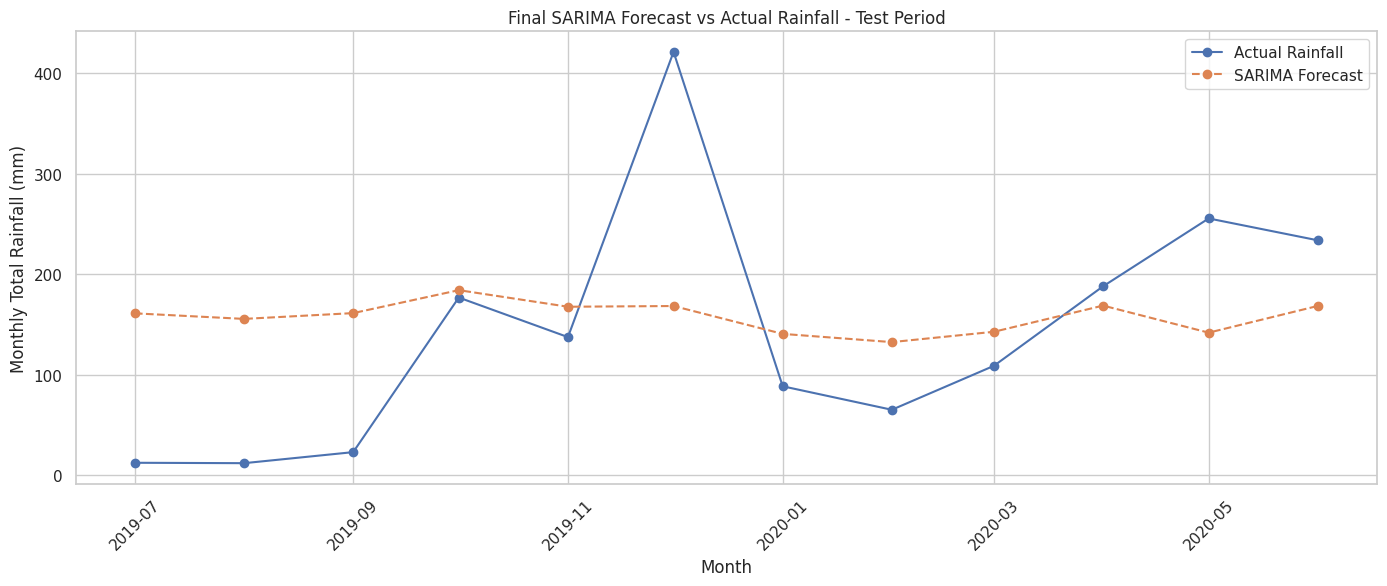

In [151]:
# ---------------------------------------------------------
# STEP 14.11: Final Test Forecast Plot
# ---------------------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    final_sarima_test.index,
    final_sarima_test.values,
    marker="o",
    label="Actual Rainfall"
)

plt.plot(
    final_test_pred.index,
    final_test_pred.values,
    marker="o",
    linestyle="--",
    label="SARIMA Forecast"
)

plt.title(
    "Final SARIMA Forecast vs Actual Rainfall - Test Period"
)

plt.xlabel("Month")
plt.ylabel("Monthly Total Rainfall (mm)")

plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

In [152]:
# ---------------------------------------------------------
# STEP 14.12: Forecast Confidence Intervals
# ---------------------------------------------------------

forecast_ci = (
    final_test_forecast
    .conf_int(alpha=0.05)
)

forecast_ci.index = final_sarima_test.index

display(
    forecast_ci.round(2)
)

,lower total_rainfall,upper total_rainfall
month,,
2019-07-01,-52.39,374.51
2019-08-01,-57.92,368.97
2019-09-01,-52.15,374.74
2019-10-01,-29.29,397.60
2019-11-01,-45.81,381.08
2019-12-01,-45.09,381.80
2020-01-01,-72.86,354.03
2020-02-01,-81.03,345.86
2020-03-01,-70.74,356.15


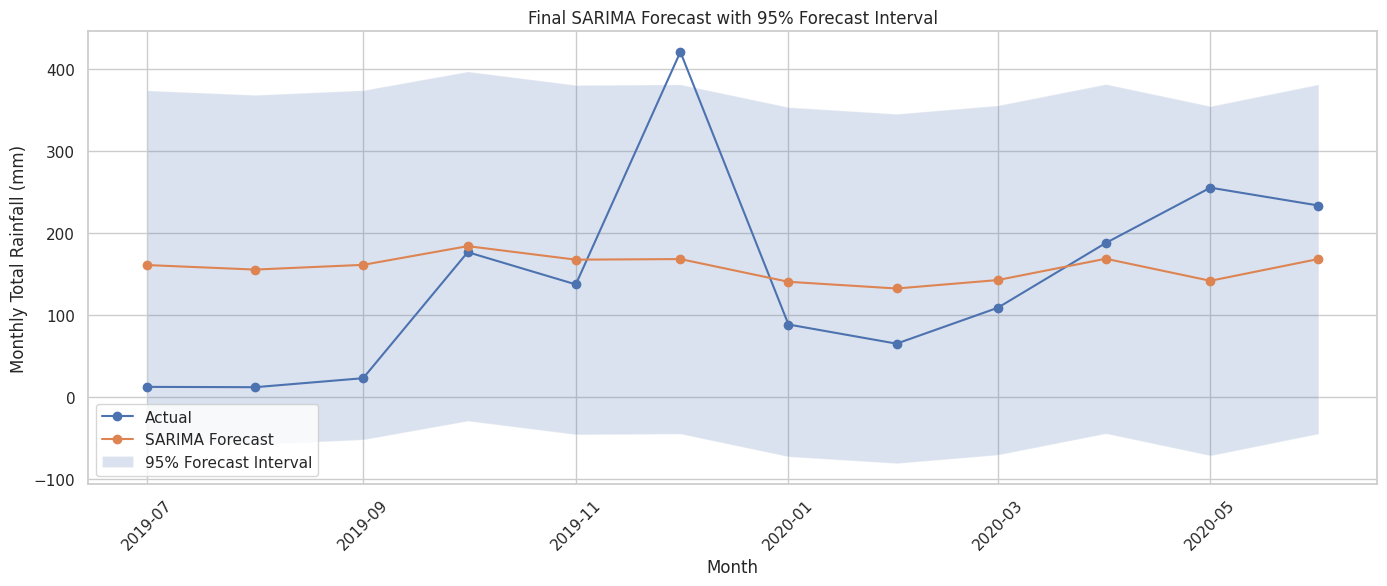

In [153]:
# ---------------------------------------------------------
# STEP 14.13: Forecast with 95% Confidence Interval
# ---------------------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    final_sarima_test.index,
    final_sarima_test.values,
    marker="o",
    label="Actual"
)

plt.plot(
    final_test_pred.index,
    final_test_pred.values,
    marker="o",
    label="SARIMA Forecast"
)

plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    alpha=0.2,
    label="95% Forecast Interval"
)

plt.title(
    "Final SARIMA Forecast with 95% Forecast Interval"
)

plt.xlabel("Month")
plt.ylabel("Monthly Total Rainfall (mm)")

plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

In [154]:
# ---------------------------------------------------------
# STEP 14.14: Forecast Interval Coverage
# ---------------------------------------------------------

lower_bound = forecast_ci.iloc[:, 0]
upper_bound = forecast_ci.iloc[:, 1]

inside_interval = (
    (final_sarima_test >= lower_bound) &
    (final_sarima_test <= upper_bound)
)

coverage_percentage = (
    inside_interval.mean() * 100
)

interval_check = pd.DataFrame({
    "Actual": final_sarima_test,
    "Lower_95": lower_bound,
    "Upper_95": upper_bound,
    "Inside_Interval": inside_interval
})

display(
    interval_check.round(2)
)

print(
    "\nPercentage of actual observations "
    "inside 95% forecast interval:"
)

print(
    f"{coverage_percentage:.2f}%"
)

,Actual,Lower_95,Upper_95,Inside_Interval
month,,,,
2019-07-01,12.2,-52.39,374.51,True
2019-08-01,11.8,-57.92,368.97,True
2019-09-01,22.8,-52.15,374.74,True
2019-10-01,176.8,-29.29,397.60,True
2019-11-01,137.4,-45.81,381.08,True
2019-12-01,421.5,-45.09,381.80,False
2020-01-01,88.4,-72.86,354.03,True
2020-02-01,65.0,-81.03,345.86,True
2020-03-01,108.8,-70.74,356.15,True



Percentage of actual observations inside 95% forecast interval:
91.67%


Final Model Evaluation

The selected SARIMA(1,0,1)(1,0,0)₁₂ model was refitted using all monthly total-rainfall observations from January 1982 through June 2019 and evaluated on the untouched 12-month test period from July 2019 to June 2020. The test set remained completely separate during model selection and hyperparameter development.

The final model achieved a test MAE of 89.47 mm and RMSE of 112.93 mm, compared with validation values of 52.39 mm and 66.33 mm, respectively. This deterioration indicates reduced generalization during the test year. Month-level analysis showed particularly large errors during unusually dry months in July–September 2019 and during the extreme rainfall event in December 2019, where the model underpredicted rainfall by approximately 253 mm.

The 95% forecast intervals contained 91.67% of the actual test observations, although the intervals were wide and December 2019 remained outside the upper bound. Overall, SARIMA captured broad seasonal rainfall structure but showed limited ability to anticipate abrupt extreme rainfall events and unusual year-to-year variation.

#Step 15 — Final 12-Month Business Forecast

In [155]:
# ---------------------------------------------------------
# STEP 15.1: Prepare Full Historical Rainfall Series
# ---------------------------------------------------------

final_business_series = df_ts[
    "total_rainfall"
].copy()

print("Total observations:")
print(len(final_business_series))

print("\nHistorical period:")
print(
    final_business_series.index.min(),
    "to",
    final_business_series.index.max()
)

print("\nMissing values:")
print(final_business_series.isnull().sum())

print("\nChronologically sorted:")
print(
    final_business_series.index.is_monotonic_increasing
)

Total observations:
462

Historical period:
1982-01-01 00:00:00 to 2020-06-01 00:00:00

Missing values:
0

Chronologically sorted:
True


In [156]:
# ---------------------------------------------------------
# STEP 15.2: Fit Final Business Forecast Model
# ---------------------------------------------------------

business_sarima_model = SARIMAX(
    final_business_series,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 0, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

business_sarima_fit = business_sarima_model.fit(
    disp=False
)

print("Final business SARIMA model fitted successfully.")

print("\nModel:")
print("SARIMA(1,0,1)(1,0,0,12)")

print("\nHistorical observations used:")
print(len(final_business_series))

print("\nModel AIC:")
print(round(business_sarima_fit.aic, 2))

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Final business SARIMA model fitted successfully.

Model:
SARIMA(1,0,1)(1,0,0,12)

Historical observations used:
462

Model AIC:
5500.27


In [157]:
# ---------------------------------------------------------
# STEP 15.3: Create Future 12-Month Forecast Dates
# ---------------------------------------------------------

future_dates = pd.date_range(
    start="2020-07-01",
    periods=12,
    freq="MS"
)

print("Forecast dates:")
print(future_dates)

Forecast dates:
DatetimeIndex(['2020-07-01', '2020-08-01', '2020-09-01', '2020-10-01',
               '2020-11-01', '2020-12-01', '2021-01-01', '2021-02-01',
               '2021-03-01', '2021-04-01', '2021-05-01', '2021-06-01'],
              dtype='datetime64[ns]', freq='MS')


In [158]:
# ---------------------------------------------------------
# STEP 15.4: Generate Final 12-Month Business Forecast
# ---------------------------------------------------------

business_forecast_result = (
    business_sarima_fit.get_forecast(
        steps=12
    )
)

business_forecast = (
    business_forecast_result.predicted_mean
)

business_forecast.index = future_dates

print(
    "Number of future forecasts:",
    len(business_forecast)
)

display(
    business_forecast
    .to_frame(
        name="Forecast_Total_Rainfall_mm"
    )
    .round(2)
)

Number of future forecasts: 12


,Forecast_Total_Rainfall_mm
2020-07-01,125.37
2020-08-01,125.22
2020-09-01,128.03
2020-10-01,167.75
2020-11-01,157.54
2020-12-01,230.87
2021-01-01,144.81
2021-02-01,138.72
2021-03-01,150.00
2021-04-01,170.41


In [159]:
# ---------------------------------------------------------
# STEP 15.5: Future Forecast Intervals
# ---------------------------------------------------------

business_forecast_ci = (
    business_forecast_result
    .conf_int(alpha=0.05)
)

business_forecast_ci.index = future_dates

display(
    business_forecast_ci.round(2)
)

,lower total_rainfall,upper total_rainfall
2020-07-01,-88.27,339.01
2020-08-01,-88.42,338.87
2020-09-01,-85.61,341.67
2020-10-01,-45.89,381.40
2020-11-01,-56.10,371.18
2020-12-01,17.23,444.51
2021-01-01,-68.83,358.45
2021-02-01,-74.92,352.36
2021-03-01,-63.64,363.63
2021-04-01,-43.23,384.05


In [160]:
# ---------------------------------------------------------
# STEP 15.6: Final Business Forecast Table
# ---------------------------------------------------------

final_business_forecast = pd.DataFrame({
    "Forecast_Rainfall_mm":
        business_forecast.values,

    "Lower_95_mm":
        business_forecast_ci.iloc[:, 0].values,

    "Upper_95_mm":
        business_forecast_ci.iloc[:, 1].values
},
    index=future_dates
)

# Rainfall cannot physically be negative.
# Create a presentation-friendly lower bound.
final_business_forecast[
    "Lower_95_Practical_mm"
] = (
    final_business_forecast[
        "Lower_95_mm"
    ].clip(lower=0)
)

display(
    final_business_forecast.round(2)
)

,Forecast_Rainfall_mm,Lower_95_mm,Upper_95_mm,Lower_95_Practical_mm
2020-07-01,125.37,-88.27,339.01,0.00
2020-08-01,125.22,-88.42,338.87,0.00
2020-09-01,128.03,-85.61,341.67,0.00
2020-10-01,167.75,-45.89,381.40,0.00
2020-11-01,157.54,-56.10,371.18,0.00
2020-12-01,230.87,17.23,444.51,17.23
2021-01-01,144.81,-68.83,358.45,0.00
2021-02-01,138.72,-74.92,352.36,0.00
2021-03-01,150.00,-63.64,363.63,0.00
2021-04-01,170.41,-43.23,384.05,0.00


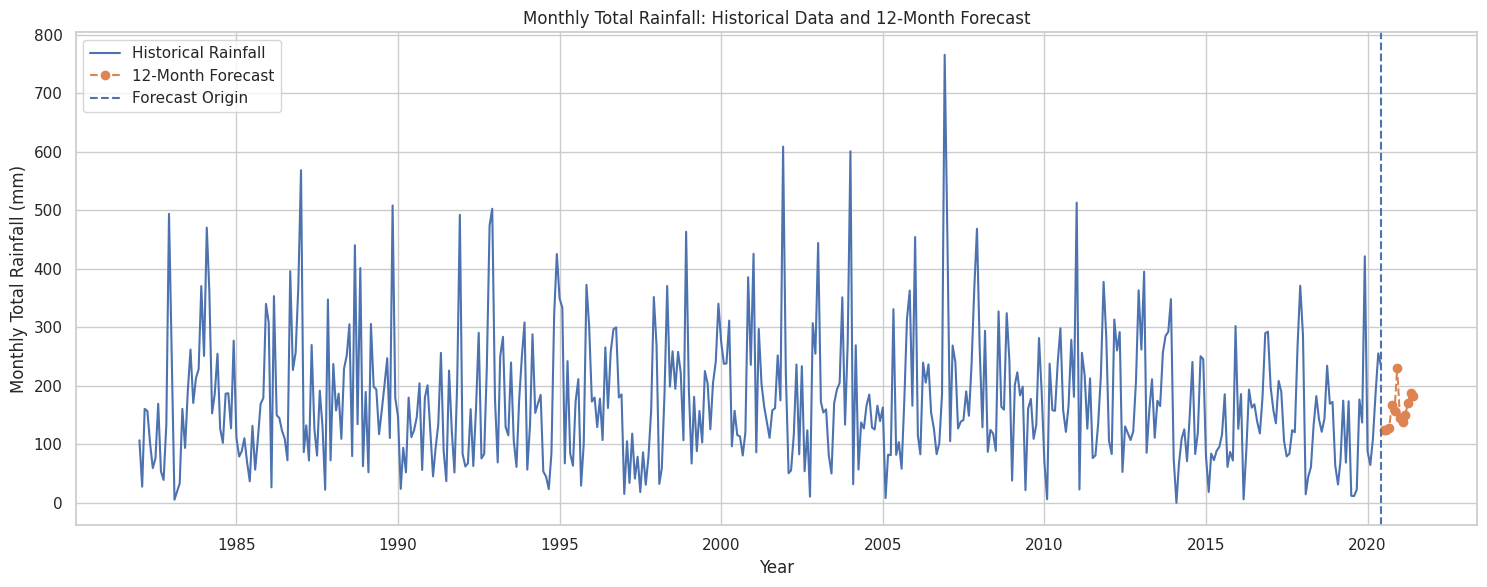

In [161]:
# ---------------------------------------------------------
# STEP 15.7: Historical Rainfall + Future Forecast
# ---------------------------------------------------------

plt.figure(figsize=(15, 6))

plt.plot(
    final_business_series.index,
    final_business_series.values,
    label="Historical Rainfall"
)

plt.plot(
    business_forecast.index,
    business_forecast.values,
    marker="o",
    linestyle="--",
    label="12-Month Forecast"
)

plt.axvline(
    pd.Timestamp("2020-06-01"),
    linestyle="--",
    label="Forecast Origin"
)

plt.title(
    "Monthly Total Rainfall: Historical Data and 12-Month Forecast"
)

plt.xlabel("Year")
plt.ylabel("Monthly Total Rainfall (mm)")

plt.legend()
plt.tight_layout()
plt.show()

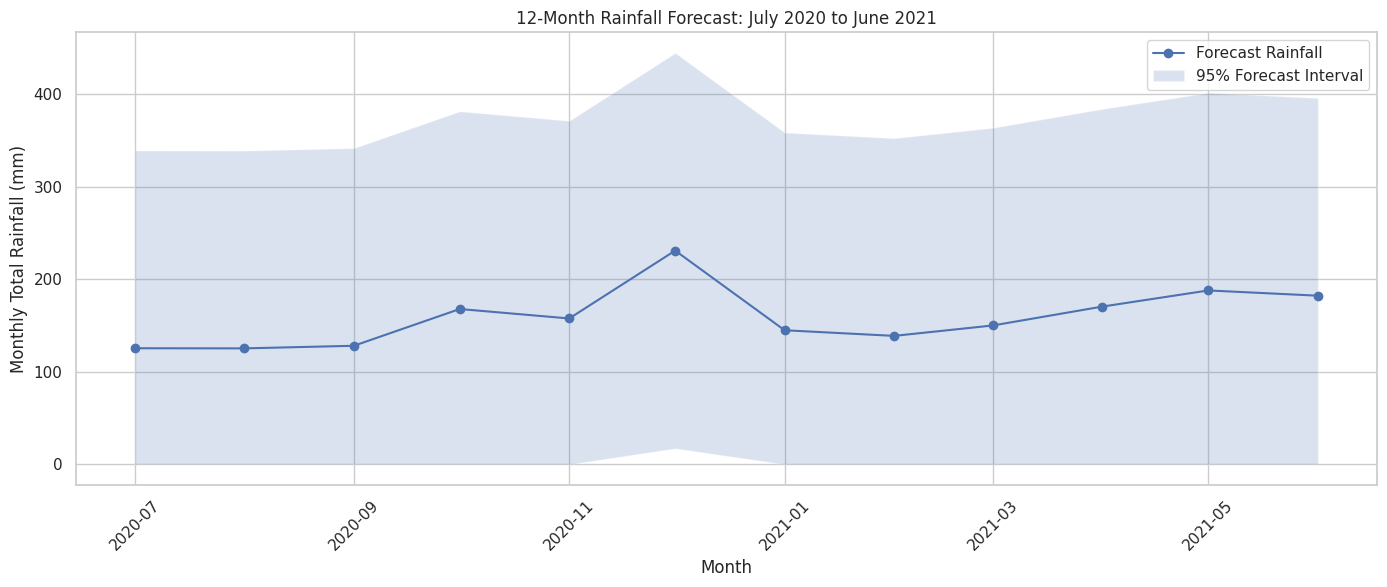

In [162]:
# ---------------------------------------------------------
# STEP 15.8: Future Forecast with 95% Interval
# ---------------------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    business_forecast.index,
    business_forecast.values,
    marker="o",
    label="Forecast Rainfall"
)

plt.fill_between(
    future_dates,
    final_business_forecast[
        "Lower_95_Practical_mm"
    ],
    final_business_forecast[
        "Upper_95_mm"
    ],
    alpha=0.2,
    label="95% Forecast Interval"
)

plt.title(
    "12-Month Rainfall Forecast: July 2020 to June 2021"
)

plt.xlabel("Month")
plt.ylabel("Monthly Total Rainfall (mm)")

plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

In [163]:
# ---------------------------------------------------------
# STEP 15.9: Identify Forecast Wettest and Driest Months
# ---------------------------------------------------------

forecast_wettest_month = (
    business_forecast.idxmax()
)

forecast_driest_month = (
    business_forecast.idxmin()
)

print("Forecast wettest month:")
print(forecast_wettest_month)

print(
    "Forecast rainfall:",
    round(
        business_forecast.loc[
            forecast_wettest_month
        ],
        2
    ),
    "mm"
)

print("\nForecast driest month:")
print(forecast_driest_month)

print(
    "Forecast rainfall:",
    round(
        business_forecast.loc[
            forecast_driest_month
        ],
        2
    ),
    "mm"
)

Forecast wettest month:
2020-12-01 00:00:00
Forecast rainfall: 230.87 mm

Forecast driest month:
2020-08-01 00:00:00
Forecast rainfall: 125.22 mm


In [164]:
# ---------------------------------------------------------
# STEP 15.10: Forecast Total Rainfall for Next 12 Months
# ---------------------------------------------------------

forecast_annual_total = (
    business_forecast.sum()
)

forecast_monthly_average = (
    business_forecast.mean()
)

print(
    "Forecast total rainfall "
    "for Jul 2020-Jun 2021:"
)

print(
    f"{forecast_annual_total:.2f} mm"
)

print(
    "\nAverage forecast monthly rainfall:"
)

print(
    f"{forecast_monthly_average:.2f} mm"
)

Forecast total rainfall for Jul 2020-Jun 2021:
1908.70 mm

Average forecast monthly rainfall:
159.06 mm


# first main business objective


Final One-Year Rainfall Forecast

Following model selection and independent test evaluation, the selected SARIMA(1,0,1)(1,0,0)₁₂ model was refitted using all 462 monthly observations from January 1982 to June 2020. The fitted model was then used to forecast monthly total rainfall for the next 12 months, from July 2020 to June 2021.

The forecasts ranged from 125.21 mm to 230.88 mm per month. December 2020 was predicted to have the highest monthly total rainfall at 230.88 mm, while August 2020 had the lowest forecast at 125.21 mm. The predicted cumulative rainfall for the 12-month period was approximately 1908.60 mm, with an average monthly forecast of 159.05 mm.

The 95% forecast intervals were relatively wide, reflecting the substantial variability and extreme rainfall behavior identified during EDA and final test evaluation. Some statistical lower bounds were negative and were therefore additionally represented with a practical lower bound of zero, since rainfall cannot be physically negative. Given the higher error observed on the untouched test period, the future forecasts should be interpreted as model-based expected rainfall levels rather than exact future values.

# Second Project Objective :

Forecast about highest rainfall occurred in a day for a single month

# Step 16 — Forecast the Highest Daily Rainfall

In [165]:
# ---------------------------------------------------------
# STEP 16.3: Create Maximum Daily Rainfall Time Series
# ---------------------------------------------------------

max_daily_series = df_ts[
    "maximum_rainfall_in_a_day"
].copy()

print("Number of observations:")
print(len(max_daily_series))

print("\nHistorical period:")
print(
    max_daily_series.index.min(),
    "to",
    max_daily_series.index.max()
)

print("\nMissing values:")
print(max_daily_series.isnull().sum())

print("\nChronologically sorted:")
print(
    max_daily_series.index.is_monotonic_increasing
)

display(
    max_daily_series.head()
)

display(
    max_daily_series.tail()
)

Number of observations:
462

Historical period:
1982-01-01 00:00:00 to 2020-06-01 00:00:00

Missing values:
0

Chronologically sorted:
True


,maximum_rainfall_in_a_day
month,
1982-01-01,36.5
1982-02-01,9.4
1982-03-01,61.7
1982-04-01,45.1
1982-05-01,33.0


,maximum_rainfall_in_a_day
month,
2020-02-01,23.8
2020-03-01,47.4
2020-04-01,51.8
2020-05-01,53.8
2020-06-01,41.0


In [166]:
# ---------------------------------------------------------
# STEP 16.4: Descriptive Statistics
# ---------------------------------------------------------

max_daily_stats = max_daily_series.describe()

display(
    max_daily_stats.to_frame(
        name="Maximum_Daily_Rainfall"
    ).round(2)
)

print(
    "\nSkewness:",
    round(max_daily_series.skew(), 3)
)

print(
    "Kurtosis:",
    round(max_daily_series.kurtosis(), 3)
)

,Maximum_Daily_Rainfall
count,462.00
mean,52.36
std,35.69
min,0.20
25%,30.62
50%,43.45
75%,63.15
max,216.20



Skewness: 1.862
Kurtosis: 4.35


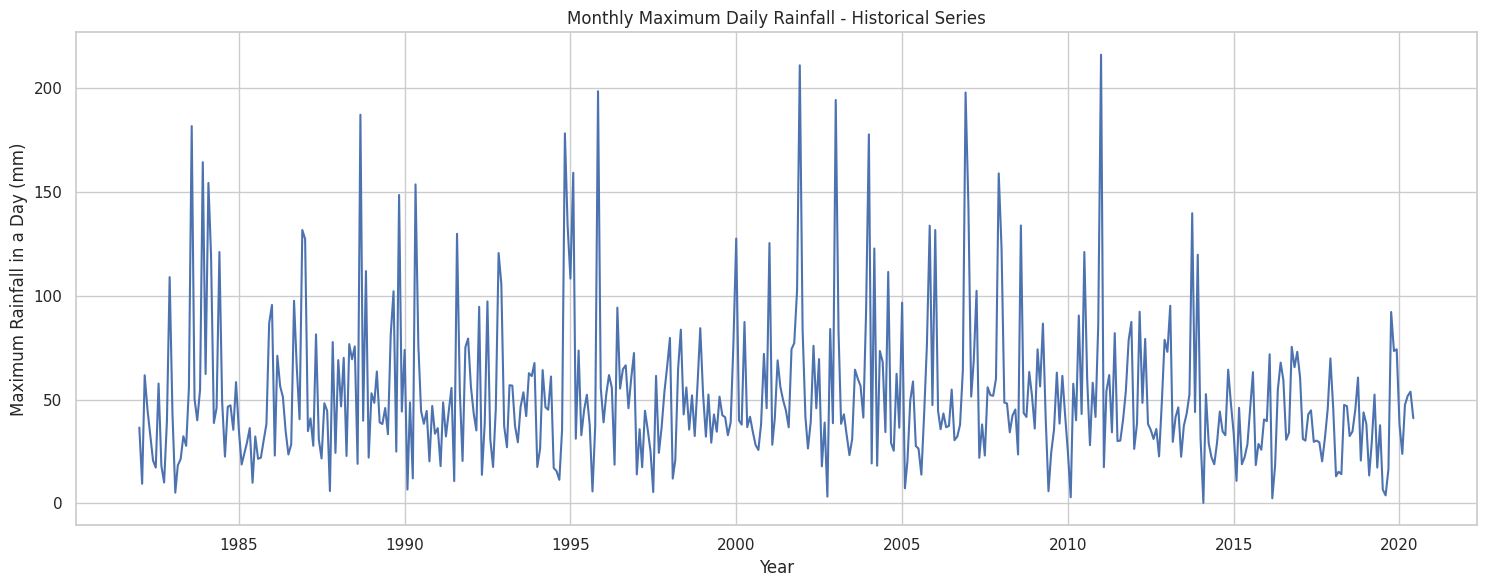

In [167]:
# ---------------------------------------------------------
# STEP 16.5: Maximum Daily Rainfall Time-Series Plot
# ---------------------------------------------------------

plt.figure(figsize=(15, 6))

plt.plot(
    max_daily_series.index,
    max_daily_series.values
)

plt.title(
    "Monthly Maximum Daily Rainfall - Historical Series"
)

plt.xlabel("Year")
plt.ylabel(
    "Maximum Rainfall in a Day (mm)"
)

plt.tight_layout()
plt.show()

In [168]:
# ---------------------------------------------------------
# STEP 16.6: Calendar-Month Seasonality
# ---------------------------------------------------------

max_daily_monthly = pd.DataFrame({
    "maximum_daily_rainfall":
        max_daily_series
})

max_daily_monthly["month_number"] = (
    max_daily_monthly.index.month
)

max_daily_monthly["month_name"] = (
    max_daily_monthly.index.strftime("%b")
)

max_daily_seasonal_mean = (
    max_daily_monthly
    .groupby("month_number")[
        "maximum_daily_rainfall"
    ]
    .mean()
)

month_labels = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

seasonal_max_table = pd.DataFrame({
    "Month": month_labels,
    "Average_Max_Daily_Rainfall_mm":
        max_daily_seasonal_mean.values
})

display(
    seasonal_max_table.round(2)
)

,Month,Average_Max_Daily_Rainfall_mm
0,Jan,74.46
1,Feb,38.68
2,Mar,47.64
3,Apr,45.68
4,May,48.48
5,Jun,43.59
6,Jul,40.46
7,Aug,49.18
8,Sep,45.13
9,Oct,44.06


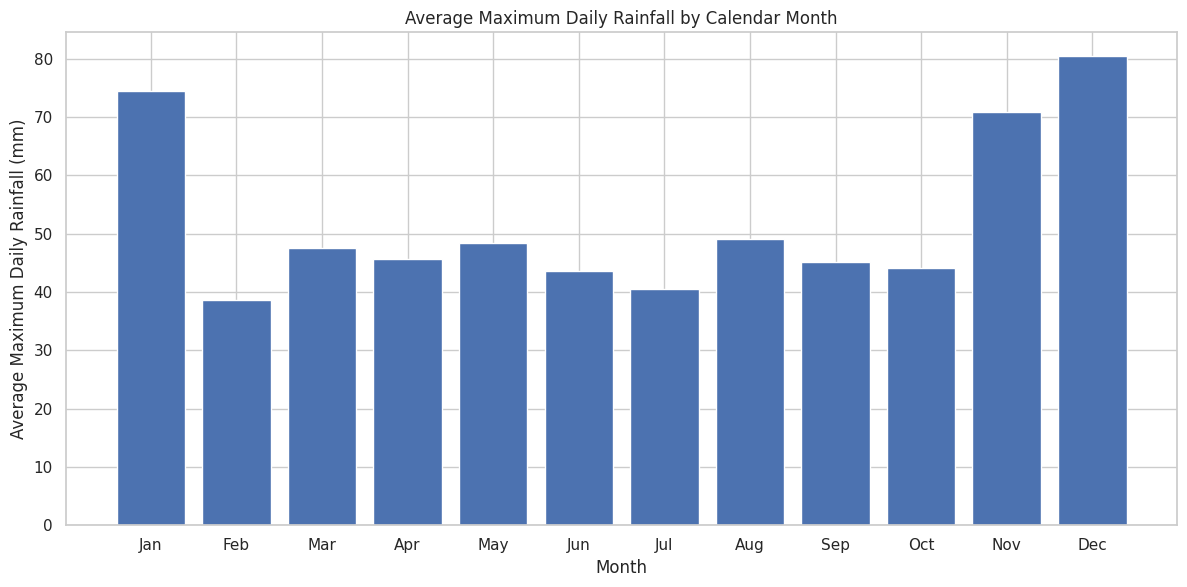

In [169]:
plt.figure(figsize=(12, 6))

plt.bar(
    seasonal_max_table["Month"],
    seasonal_max_table[
        "Average_Max_Daily_Rainfall_mm"
    ]
)

plt.title(
    "Average Maximum Daily Rainfall by Calendar Month"
)

plt.xlabel("Month")
plt.ylabel(
    "Average Maximum Daily Rainfall (mm)"
)

plt.tight_layout()
plt.show()

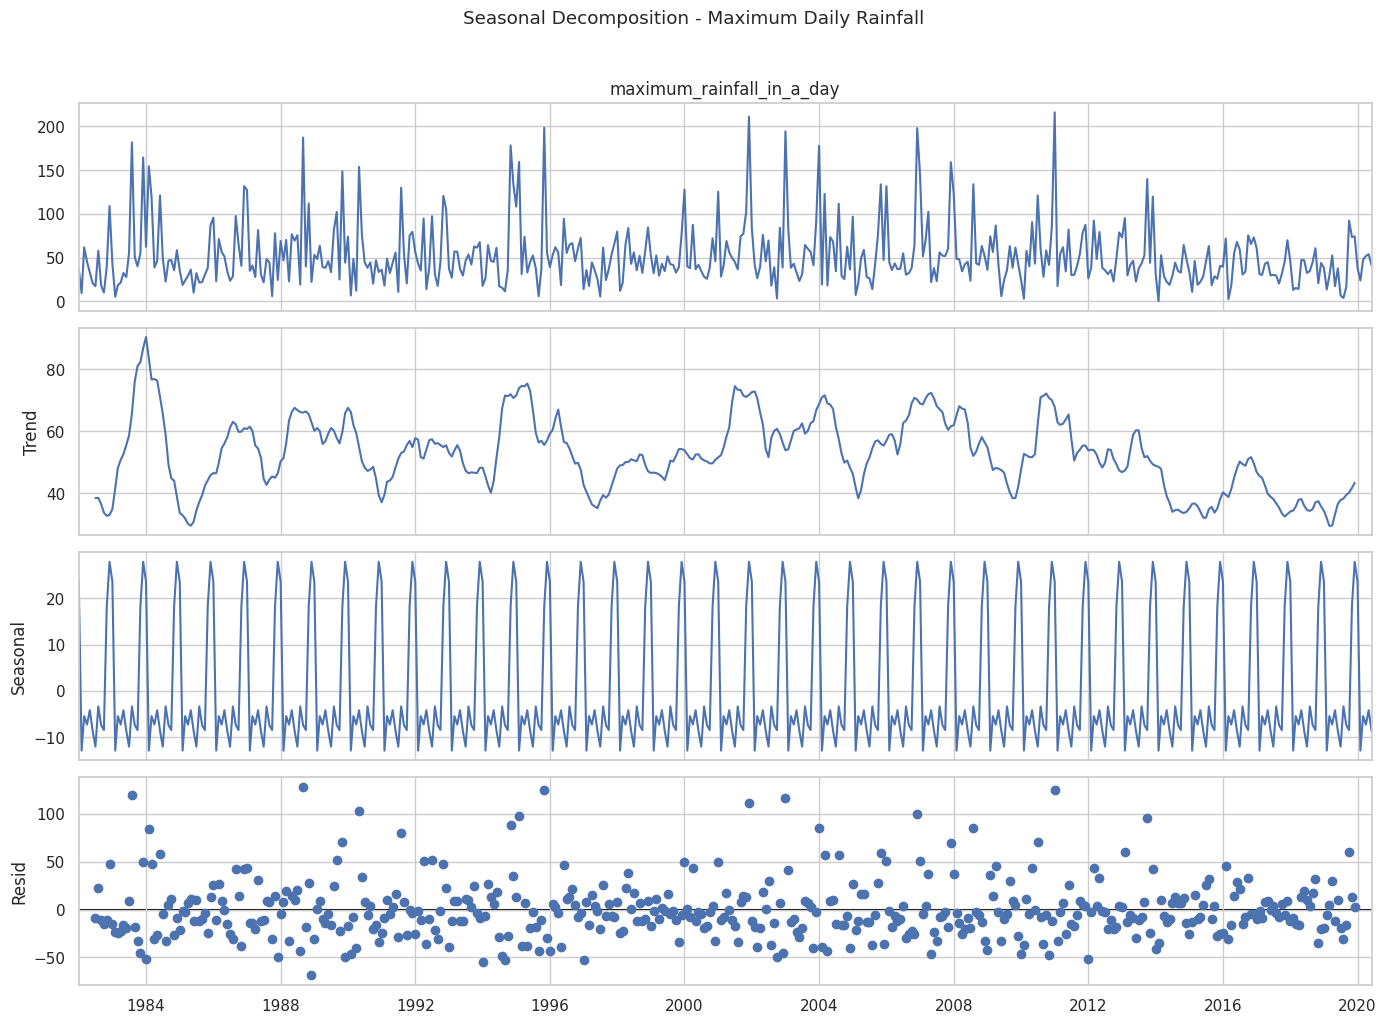

In [170]:
# ---------------------------------------------------------
# STEP 16.7: Seasonal Decomposition
# ---------------------------------------------------------

max_daily_decomposition = seasonal_decompose(
    max_daily_series,
    model="additive",
    period=12
)

fig = max_daily_decomposition.plot()

fig.set_size_inches(14, 10)

plt.suptitle(
    "Seasonal Decomposition - Maximum Daily Rainfall",
    y=1.02
)

plt.tight_layout()
plt.show()

In [171]:
# ---------------------------------------------------------
# STEP 16.8: ADF Stationarity Test
# ---------------------------------------------------------

from statsmodels.tsa.stattools import adfuller

max_daily_adf = adfuller(
    max_daily_series
)

print("ADF Statistic:")
print(max_daily_adf[0])

print("\np-value:")
print(max_daily_adf[1])

print("\nNumber of Lags Used:")
print(max_daily_adf[2])

print("\nNumber of Observations Used:")
print(max_daily_adf[3])

print("\nCritical Values:")

for key, value in max_daily_adf[4].items():
    print(
        f"{key}: {value}"
    )

if max_daily_adf[1] < 0.05:
    print(
        "\nDecision: Reject H0 - "
        "evidence of stationarity."
    )
else:
    print(
        "\nDecision: Fail to reject H0 - "
        "evidence of non-stationarity."
    )

ADF Statistic:
-4.9623171717849734

p-value:
2.633710577254385e-05

Number of Lags Used:
11

Number of Observations Used:
450

Critical Values:
1%: -3.444965543297668
5%: -2.8679842369272976
10%: -2.5702025382716047

Decision: Reject H0 - evidence of stationarity.


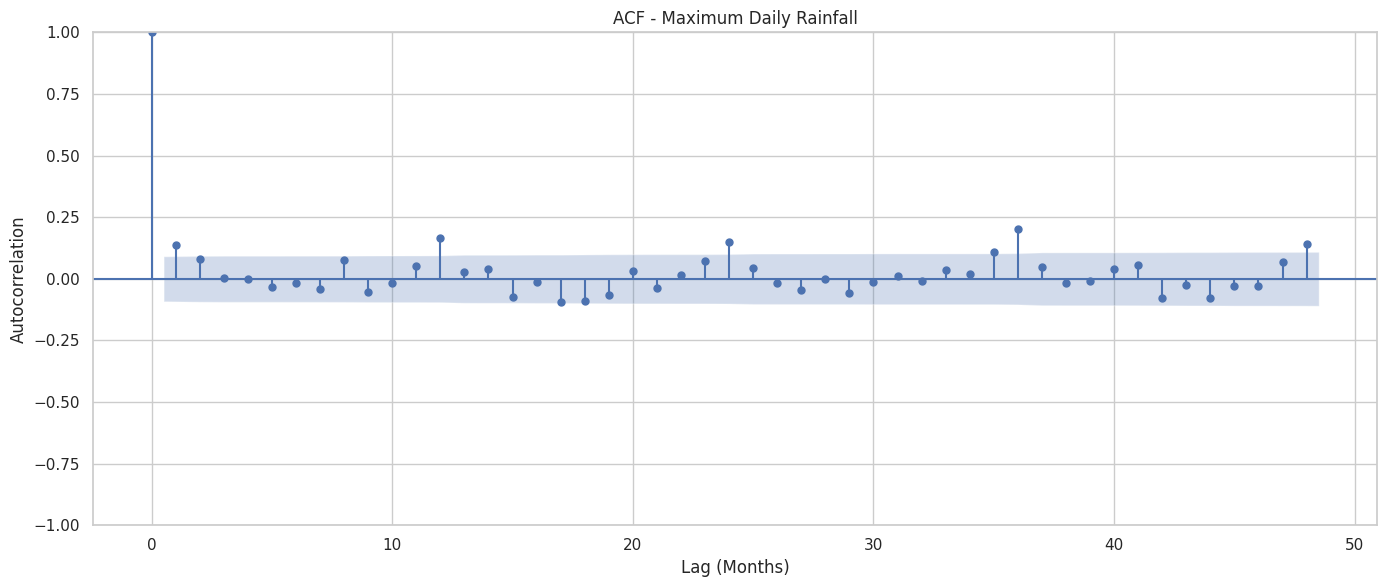

In [172]:
# ---------------------------------------------------------
# STEP 16.9: ACF Analysis
# ---------------------------------------------------------

from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(
    figsize=(14, 6)
)

plot_acf(
    max_daily_series,
    lags=48,
    alpha=0.05,
    ax=ax
)

ax.set_title(
    "ACF - Maximum Daily Rainfall"
)

ax.set_xlabel("Lag (Months)")
ax.set_ylabel("Autocorrelation")

plt.tight_layout()
plt.show()

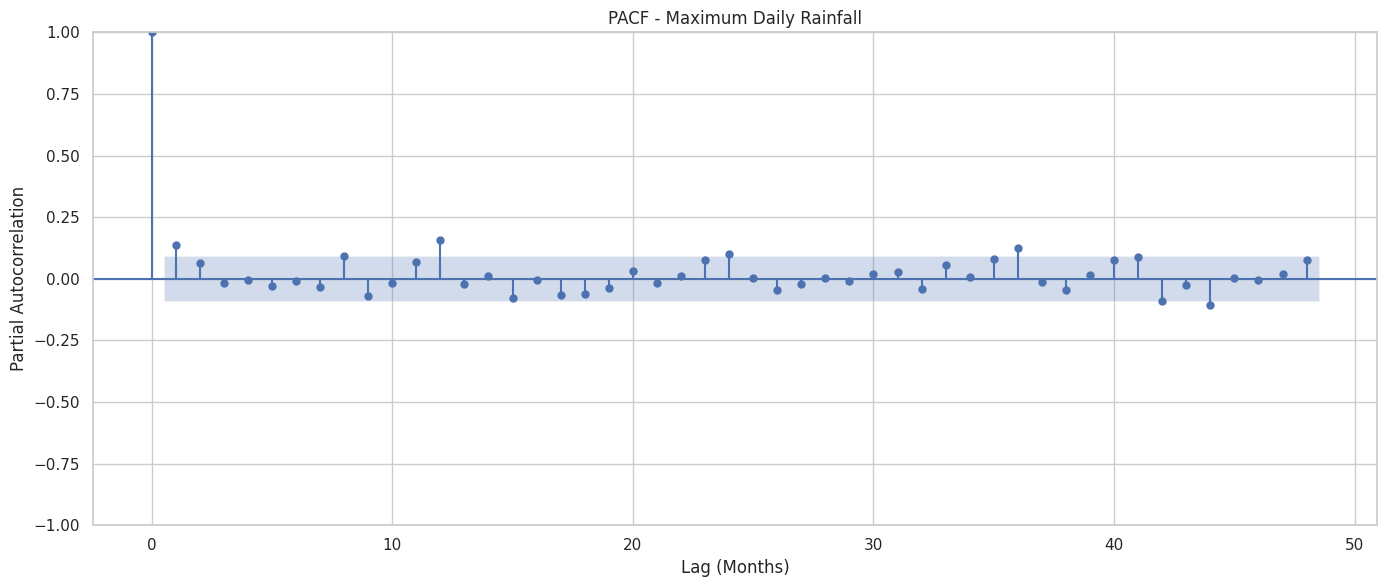

In [173]:
# ---------------------------------------------------------
# STEP 16.10: PACF Analysis
# ---------------------------------------------------------

from statsmodels.graphics.tsaplots import plot_pacf

fig, ax = plt.subplots(
    figsize=(14, 6)
)

plot_pacf(
    max_daily_series,
    lags=48,
    alpha=0.05,
    method="ywm",
    ax=ax
)

ax.set_title(
    "PACF - Maximum Daily Rainfall"
)

ax.set_xlabel("Lag (Months)")
ax.set_ylabel("Partial Autocorrelation")

plt.tight_layout()
plt.show()

In [174]:
# ---------------------------------------------------------
# STEP 16.11: Exact Seasonal ACF/PACF Values
# ---------------------------------------------------------

from statsmodels.tsa.stattools import acf, pacf

max_daily_acf_values = acf(
    max_daily_series,
    nlags=48,
    fft=True
)

max_daily_pacf_values = pacf(
    max_daily_series,
    nlags=48,
    method="ywm"
)

seasonal_lags = [
    12,
    24,
    36,
    48
]

seasonal_correlation_table = pd.DataFrame({
    "Lag": seasonal_lags,

    "ACF": [
        max_daily_acf_values[lag]
        for lag in seasonal_lags
    ],

    "PACF": [
        max_daily_pacf_values[lag]
        for lag in seasonal_lags
    ]
})

display(
    seasonal_correlation_table.round(3)
)

,Lag,ACF,PACF
0,12,0.167,0.157
1,24,0.151,0.101
2,36,0.200,0.126
3,48,0.141,0.077


Maximum Daily Rainfall Time-Series Analysis

The maximum_rainfall_in_a_day series contained 462 monthly observations from January 1982 to June 2020, with no missing values and correct chronological ordering. The series had a mean of 52.36 mm, median of 43.45 mm, and maximum of 216.20 mm. A skewness of 1.862 and kurtosis of 4.350 indicated a strongly right-skewed distribution with occasional extreme daily rainfall events.

Calendar-month analysis showed clear seasonal variation. December recorded the highest historical average maximum-daily rainfall (80.53 mm), followed by January (74.46 mm) and November (70.83 mm), while February had the lowest average (38.68 mm). Seasonal decomposition further demonstrated a repeating annual pattern, while large residual deviations indicated that extreme events were not fully explained by regular trend and seasonality.

The ADF test produced a statistic of −4.962 and a p-value of approximately 0.000026, providing strong evidence against a unit root. ACF and PACF analysis showed positive relationships at annual seasonal lags, with Lag 12 ACF = 0.167 and PACF = 0.157. Overall, the analysis supports investigating a forecasting model with a 12-month seasonal structure, while recognizing that extreme single-day rainfall remains highly variable.

# Step 17 — Baseline and SARIMA Modeling for Maximum Daily Rainfall

In [175]:
# ---------------------------------------------------------
# STEP 17.1: Chronological Split for Maximum Daily Rainfall
# ---------------------------------------------------------

max_train = max_daily_series.loc[
    max_daily_series.index < pd.Timestamp("2018-07-01")
].copy()

max_val = max_daily_series.loc[
    (max_daily_series.index >= pd.Timestamp("2018-07-01")) &
    (max_daily_series.index < pd.Timestamp("2019-07-01"))
].copy()

max_test = max_daily_series.loc[
    max_daily_series.index >= pd.Timestamp("2019-07-01")
].copy()

print("Training observations :", len(max_train))
print("Validation observations:", len(max_val))
print("Test observations      :", len(max_test))

print("\nTraining period:")
print(max_train.index.min(), "to", max_train.index.max())

print("\nValidation period:")
print(max_val.index.min(), "to", max_val.index.max())

print("\nTest period:")
print(max_test.index.min(), "to", max_test.index.max())

Training observations : 438
Validation observations: 12
Test observations      : 12

Training period:
1982-01-01 00:00:00 to 2018-06-01 00:00:00

Validation period:
2018-07-01 00:00:00 to 2019-06-01 00:00:00

Test period:
2019-07-01 00:00:00 to 2020-06-01 00:00:00


In [176]:
# ---------------------------------------------------------
# STEP 17.2: Split Integrity Checks
# ---------------------------------------------------------

print(
    "Train-Validation overlap:",
    len(max_train.index.intersection(max_val.index))
)

print(
    "Train-Test overlap:",
    len(max_train.index.intersection(max_test.index))
)

print(
    "Validation-Test overlap:",
    len(max_val.index.intersection(max_test.index))
)

print("\nTraining sorted:",
      max_train.index.is_monotonic_increasing)

print("Validation sorted:",
      max_val.index.is_monotonic_increasing)

print("Test sorted:",
      max_test.index.is_monotonic_increasing)

Train-Validation overlap: 0
Train-Test overlap: 0
Validation-Test overlap: 0

Training sorted: True
Validation sorted: True
Test sorted: True


In [177]:
# ---------------------------------------------------------
# STEP 17.3: Naive Baseline
# ---------------------------------------------------------

max_last_train_value = max_train.iloc[-1]

max_naive_val_pred = np.repeat(
    max_last_train_value,
    len(max_val)
)

print("Last training maximum daily rainfall:")
print(max_last_train_value)

print("\nNaive validation predictions:")
print(max_naive_val_pred)

Last training maximum daily rainfall:
46.8

Naive validation predictions:
[46.8 46.8 46.8 46.8 46.8 46.8 46.8 46.8 46.8 46.8 46.8 46.8]


In [178]:
# ---------------------------------------------------------
# STEP 17.4: Seasonal Naive Baseline
# ---------------------------------------------------------

max_seasonal_naive_val_pred = (
    max_daily_series
    .shift(12)
    .loc[max_val.index]
    .values
)

print("Seasonal Naive validation predictions:")
print(max_seasonal_naive_val_pred)

Seasonal Naive validation predictions:
[30.2 29.4 20.2 31.2 45.2 69.8 45.8 13.  15.2 14.  47.4 46.8]


In [179]:
# ---------------------------------------------------------
# STEP 17.5: Verify Seasonal Naive Alignment
# ---------------------------------------------------------

max_seasonal_check = pd.DataFrame({
    "Actual_Max_Daily": max_val.values,
    "Seasonal_Naive": max_seasonal_naive_val_pred
}, index=max_val.index)

max_seasonal_check["Source_Month"] = (
    max_seasonal_check.index -
    pd.DateOffset(months=12)
)

display(max_seasonal_check.round(2))

,Actual_Max_Daily,Seasonal_Naive,Source_Month
month,,,
2018-07-01,32.4,30.2,2017-07-01
2018-08-01,34.6,29.4,2017-08-01
2018-09-01,45.0,20.2,2017-09-01
2018-10-01,60.6,31.2,2017-10-01
2018-11-01,20.6,45.2,2017-11-01
2018-12-01,43.8,69.8,2017-12-01
2019-01-01,38.2,45.8,2018-01-01
2019-02-01,13.4,13.0,2018-02-01
2019-03-01,29.0,15.2,2018-03-01


In [180]:
# ---------------------------------------------------------
# STEP 17.6: Baseline Evaluation
# ---------------------------------------------------------

from sklearn.metrics import mean_absolute_error, mean_squared_error

# Naive
max_naive_mae = mean_absolute_error(
    max_val,
    max_naive_val_pred
)

max_naive_rmse = np.sqrt(
    mean_squared_error(
        max_val,
        max_naive_val_pred
    )
)

# Seasonal Naive
max_seasonal_naive_mae = mean_absolute_error(
    max_val,
    max_seasonal_naive_val_pred
)

max_seasonal_naive_rmse = np.sqrt(
    mean_squared_error(
        max_val,
        max_seasonal_naive_val_pred
    )
)

print("NAIVE BASELINE")
print("----------------")
print(f"MAE  : {max_naive_mae:.2f} mm")
print(f"RMSE : {max_naive_rmse:.2f} mm")

print("\nSEASONAL NAIVE BASELINE")
print("-----------------------")
print(f"MAE  : {max_seasonal_naive_mae:.2f} mm")
print(f"RMSE : {max_seasonal_naive_rmse:.2f} mm")

NAIVE BASELINE
----------------
MAE  : 14.63 mm
RMSE : 17.66 mm

SEASONAL NAIVE BASELINE
-----------------------
MAE  : 17.65 mm
RMSE : 21.43 mm


In [181]:
# ---------------------------------------------------------
# STEP 17.7: Baseline Comparison
# ---------------------------------------------------------

max_baseline_results = pd.DataFrame({
    "Model": [
        "Naive",
        "Seasonal Naive"
    ],
    "MAE_mm": [
        max_naive_mae,
        max_seasonal_naive_mae
    ],
    "RMSE_mm": [
        max_naive_rmse,
        max_seasonal_naive_rmse
    ]
})

max_baseline_results = (
    max_baseline_results
    .sort_values("RMSE_mm")
    .reset_index(drop=True)
)

display(max_baseline_results.round(2))

,Model,MAE_mm,RMSE_mm
0,Naive,14.63,17.66
1,Seasonal Naive,17.65,21.43


In [182]:
# ---------------------------------------------------------
# STEP 17.9: SARIMA Candidate Search
# ---------------------------------------------------------

from statsmodels.tsa.statespace.sarimax import SARIMAX

max_sarima_candidates = [
    ((0, 0, 0), (1, 0, 0, 12)),
    ((1, 0, 0), (1, 0, 0, 12)),
    ((0, 0, 1), (1, 0, 0, 12)),
    ((1, 0, 1), (1, 0, 0, 12)),

    ((1, 0, 0), (0, 0, 1, 12)),
    ((0, 0, 1), (0, 0, 1, 12)),
    ((1, 0, 1), (0, 0, 1, 12)),
    ((1, 0, 1), (1, 0, 1, 12)),

    ((0, 0, 0), (1, 1, 0, 12)),
    ((1, 0, 0), (1, 1, 0, 12)),
    ((0, 0, 1), (1, 1, 0, 12)),
    ((1, 0, 1), (1, 1, 0, 12)),
    ((1, 0, 1), (0, 1, 1, 12))
]

max_sarima_results = []

for order, seasonal_order in max_sarima_candidates:

    try:

        model = SARIMAX(
            max_train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted = model.fit(
            disp=False
        )

        pred = fitted.forecast(
            steps=len(max_val)
        )

        mae = mean_absolute_error(
            max_val,
            pred
        )

        rmse = np.sqrt(
            mean_squared_error(
                max_val,
                pred
            )
        )

        max_sarima_results.append({
            "order": order,
            "seasonal_order": seasonal_order,
            "AIC": fitted.aic,
            "MAE_mm": mae,
            "RMSE_mm": rmse
        })

    except Exception as e:

        print(
            f"Failed: {order} x {seasonal_order}"
        )

        print(e)

max_sarima_results_df = pd.DataFrame(
    max_sarima_results
)

max_sarima_results_df = (
    max_sarima_results_df
    .sort_values("RMSE_mm")
    .reset_index(drop=True)
)

display(
    max_sarima_results_df.round(2)
)

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

,order,seasonal_order,AIC,MAE_mm,RMSE_mm
0,"(1, 0, 1)","(1, 0, 0, 12)",4269.98,14.74,17.15
1,"(1, 0, 1)","(0, 0, 1, 12)",4254.94,15.46,18.12
2,"(1, 0, 1)","(1, 1, 0, 12)",4237.24,15.67,18.83
3,"(1, 0, 0)","(1, 1, 0, 12)",4237.23,15.67,18.86
4,"(0, 0, 1)","(1, 1, 0, 12)",4247.10,15.67,18.86
5,"(0, 0, 0)","(1, 1, 0, 12)",4247.30,15.67,18.87
6,"(0, 0, 0)","(1, 0, 0, 12)",4432.48,16.70,20.95
7,"(0, 0, 1)","(1, 0, 0, 12)",4417.94,16.80,21.43
8,"(1, 0, 0)","(1, 0, 0, 12)",4396.33,17.87,22.84
9,"(1, 0, 1)","(1, 0, 1, 12)",4238.75,19.41,23.30


In [183]:
# ---------------------------------------------------------
# STEP 17.10: Select Best Maximum-Daily SARIMA
# ---------------------------------------------------------

best_max_sarima_row = (
    max_sarima_results_df.iloc[0]
)

best_max_order = (
    best_max_sarima_row["order"]
)

best_max_seasonal_order = (
    best_max_sarima_row["seasonal_order"]
)

print("Best SARIMA order:")
print(best_max_order)

print("\nBest seasonal order:")
print(best_max_seasonal_order)

print("\nValidation MAE:")
print(
    f"{best_max_sarima_row['MAE_mm']:.2f} mm"
)

print("\nValidation RMSE:")
print(
    f"{best_max_sarima_row['RMSE_mm']:.2f} mm"
)

print("\nAIC:")
print(
    f"{best_max_sarima_row['AIC']:.2f}"
)

Best SARIMA order:
(1, 0, 1)

Best seasonal order:
(1, 0, 0, 12)

Validation MAE:
14.74 mm

Validation RMSE:
17.15 mm

AIC:
4269.98


In [184]:
# ---------------------------------------------------------
# STEP 17.11: Fit Selected Maximum-Daily SARIMA
# ---------------------------------------------------------

best_max_sarima_model = SARIMAX(
    max_train,
    order=best_max_order,
    seasonal_order=best_max_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

best_max_sarima_fit = (
    best_max_sarima_model.fit(
        disp=False
    )
)

print("Best maximum-daily SARIMA fitted successfully.")

print("\nOrder:")
print(best_max_order)

print("\nSeasonal order:")
print(best_max_seasonal_order)

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Best maximum-daily SARIMA fitted successfully.

Order:
(1, 0, 1)

Seasonal order:
(1, 0, 0, 12)


In [185]:
# ---------------------------------------------------------
# STEP 17.12: Maximum-Daily SARIMA Validation Forecast
# ---------------------------------------------------------

max_sarima_val_forecast = (
    best_max_sarima_fit.get_forecast(
        steps=12
    )
)

max_sarima_val_pred = (
    max_sarima_val_forecast.predicted_mean
)

max_sarima_val_pred.index = (
    max_val.index
)

max_sarima_validation_table = pd.DataFrame({
    "Actual_Max_Daily": max_val,
    "SARIMA_Prediction": max_sarima_val_pred
})

display(
    max_sarima_validation_table.round(2)
)

,Actual_Max_Daily,SARIMA_Prediction
month,,
2018-07-01,32.4,45.17
2018-08-01,34.6,45.03
2018-09-01,45.0,43.54
2018-10-01,60.6,45.28
2018-11-01,20.6,47.49
2018-12-01,43.8,51.38
2019-01-01,38.2,47.55
2019-02-01,13.4,42.31
2019-03-01,29.0,42.64


In [186]:
# ---------------------------------------------------------
# STEP 17.13: Evaluate Selected SARIMA
# ---------------------------------------------------------

max_sarima_mae = mean_absolute_error(
    max_val,
    max_sarima_val_pred
)

max_sarima_rmse = np.sqrt(
    mean_squared_error(
        max_val,
        max_sarima_val_pred
    )
)

print("MAXIMUM DAILY SARIMA VALIDATION PERFORMANCE")
print("-------------------------------------------")

print(
    f"MAE  : {max_sarima_mae:.2f} mm"
)

print(
    f"RMSE : {max_sarima_rmse:.2f} mm"
)

MAXIMUM DAILY SARIMA VALIDATION PERFORMANCE
-------------------------------------------
MAE  : 14.74 mm
RMSE : 17.15 mm


In [187]:
# ---------------------------------------------------------
# STEP 17.14: Maximum-Daily Model Comparison
# ---------------------------------------------------------

max_model_comparison = pd.DataFrame({
    "Model": [
        "Naive",
        "Seasonal Naive",
        "SARIMA"
    ],

    "MAE_mm": [
        max_naive_mae,
        max_seasonal_naive_mae,
        max_sarima_mae
    ],

    "RMSE_mm": [
        max_naive_rmse,
        max_seasonal_naive_rmse,
        max_sarima_rmse
    ]
})

max_model_comparison = (
    max_model_comparison
    .sort_values("RMSE_mm")
    .reset_index(drop=True)
)

display(
    max_model_comparison.round(2)
)

,Model,MAE_mm,RMSE_mm
0,SARIMA,14.74,17.15
1,Naive,14.63,17.66
2,Seasonal Naive,17.65,21.43


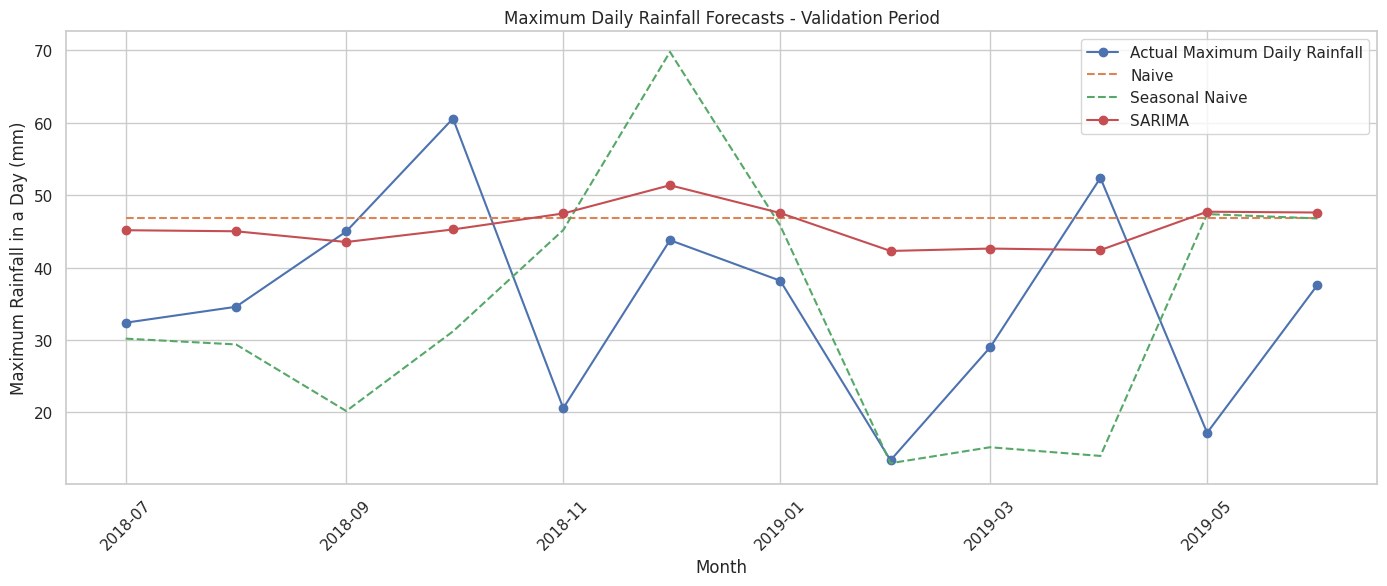

In [188]:
# ---------------------------------------------------------
# STEP 17.15: Forecast Comparison Plot
# ---------------------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    max_val.index,
    max_val.values,
    marker="o",
    label="Actual Maximum Daily Rainfall"
)

plt.plot(
    max_val.index,
    max_naive_val_pred,
    linestyle="--",
    label="Naive"
)

plt.plot(
    max_val.index,
    max_seasonal_naive_val_pred,
    linestyle="--",
    label="Seasonal Naive"
)

plt.plot(
    max_val.index,
    max_sarima_val_pred.values,
    marker="o",
    label="SARIMA"
)

plt.title(
    "Maximum Daily Rainfall Forecasts - Validation Period"
)

plt.xlabel("Month")
plt.ylabel(
    "Maximum Rainfall in a Day (mm)"
)

plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

Residual count: 438
Residual mean: 0.768
Residual standard deviation: 36.186


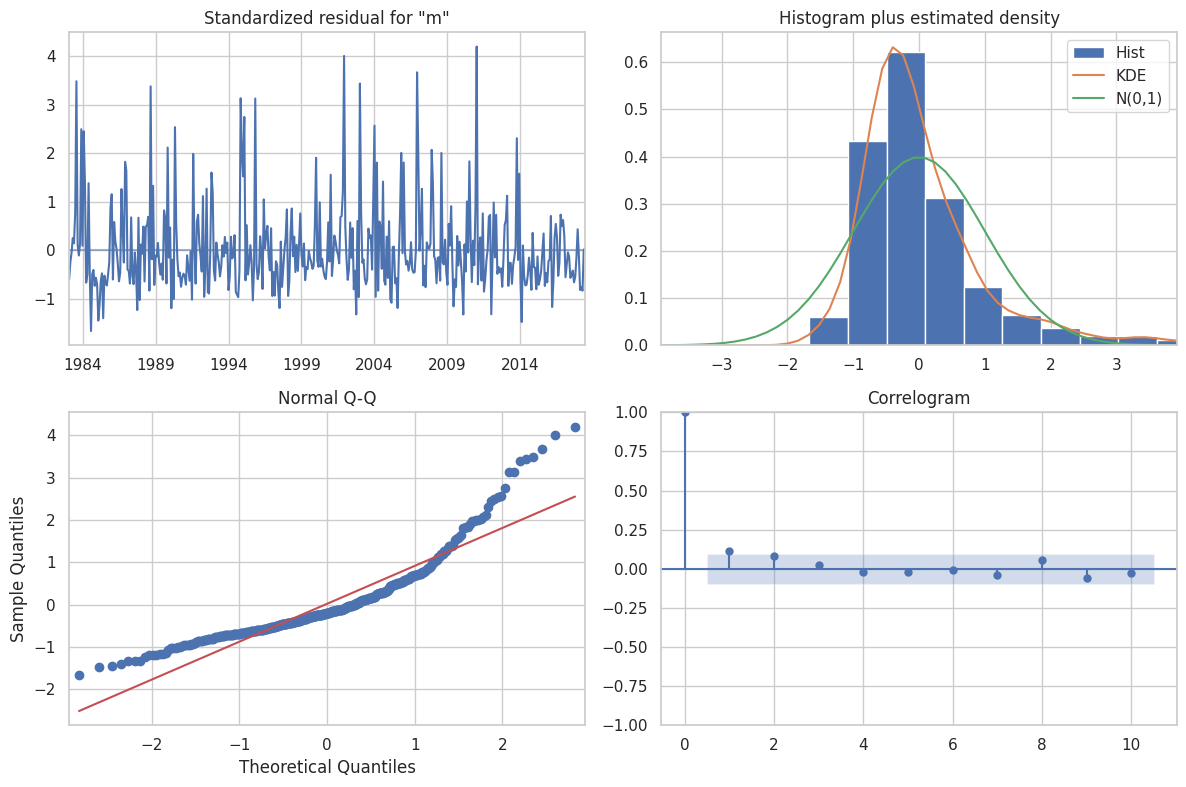

In [189]:
# ---------------------------------------------------------
# STEP 17.16: SARIMA Residual Diagnostics
# ---------------------------------------------------------

max_sarima_residuals = (
    best_max_sarima_fit.resid.dropna()
)

print(
    "Residual count:",
    len(max_sarima_residuals)
)

print(
    "Residual mean:",
    round(
        max_sarima_residuals.mean(),
        3
    )
)

print(
    "Residual standard deviation:",
    round(
        max_sarima_residuals.std(),
        3
    )
)

fig = (
    best_max_sarima_fit
    .plot_diagnostics(
        figsize=(12, 8)
    )
)

plt.tight_layout()
plt.show()

In [190]:
# ---------------------------------------------------------
# STEP 17.17: Ljung-Box Test
# ---------------------------------------------------------

from statsmodels.stats.diagnostic import acorr_ljungbox

max_ljung_box = acorr_ljungbox(
    max_sarima_residuals,
    lags=[12, 24],
    return_df=True
)

display(max_ljung_box)

,lb_stat,lb_pvalue
12,12.872609,0.378368
24,30.852716,0.158075


Baseline and SARIMA Modeling for Maximum Daily Rainfall

The maximum_rainfall_in_a_day series was split chronologically into 438 training observations (January 1982–June 2018), 12 validation observations (July 2018–June 2019), and 12 untouched test observations (July 2019–June 2020). Two baseline models were evaluated first. The Naive baseline achieved an MAE of 14.63 mm and RMSE of 17.66 mm, while the Seasonal Naive baseline achieved an MAE of 17.65 mm and RMSE of 21.43 mm.

A controlled SARIMA candidate search was then performed. The best configuration was SARIMA(1,0,1)(1,0,0)₁₂, which achieved a validation MAE of 14.74 mm and RMSE of 17.15 mm. SARIMA therefore produced the lowest RMSE, while the Naive baseline had a marginally lower MAE. The RMSE improvement over Naive was modest, indicating that the simple baseline remained highly competitive.

Residual diagnostics showed a residual mean close to zero and no statistically significant autocorrelation according to the Ljung–Box test at Lag 12 (p = 0.378) or Lag 24 (p = 0.158). However, large residual spikes and non-normal tails remained, reflecting the difficulty of forecasting extreme single-day rainfall events.

# Step 18 — Untouched Test Evaluation for Maximum Daily Rainfall

In [191]:
# ---------------------------------------------------------
# STEP 18.1: Prepare Final Training and Test Series
# ---------------------------------------------------------

max_final_train = max_daily_series.loc[
    max_daily_series.index < pd.Timestamp("2019-07-01")
].copy()

max_final_test = max_daily_series.loc[
    (max_daily_series.index >= pd.Timestamp("2019-07-01")) &
    (max_daily_series.index <= pd.Timestamp("2020-06-01"))
].copy()

print("Final training observations:",
      len(max_final_train))

print("Final test observations:",
      len(max_final_test))

print("\nFinal training period:")
print(
    max_final_train.index.min(),
    "to",
    max_final_train.index.max()
)

print("\nFinal test period:")
print(
    max_final_test.index.min(),
    "to",
    max_final_test.index.max()
)

Final training observations: 450
Final test observations: 12

Final training period:
1982-01-01 00:00:00 to 2019-06-01 00:00:00

Final test period:
2019-07-01 00:00:00 to 2020-06-01 00:00:00


In [192]:
# ---------------------------------------------------------
# STEP 18.2: Final Test Integrity Checks
# ---------------------------------------------------------

print(
    "Train-Test overlap:",
    len(
        max_final_train.index.intersection(
            max_final_test.index
        )
    )
)

print(
    "Training missing values:",
    max_final_train.isnull().sum()
)

print(
    "Test missing values:",
    max_final_test.isnull().sum()
)

print(
    "Training sorted:",
    max_final_train.index.is_monotonic_increasing
)

print(
    "Test sorted:",
    max_final_test.index.is_monotonic_increasing
)

Train-Test overlap: 0
Training missing values: 0
Test missing values: 0
Training sorted: True
Test sorted: True


In [193]:
# ---------------------------------------------------------
# STEP 18.3: Refit Selected SARIMA
# ---------------------------------------------------------

max_final_model = SARIMAX(
    max_final_train,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 0, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

max_final_fit = max_final_model.fit(
    disp=False
)

print(
    "Final maximum-daily SARIMA fitted successfully."
)

print("\nModel:")
print("SARIMA(1,0,1)(1,0,0,12)")

print("\nObservations used:")
print(len(max_final_train))

print("\nAIC:")
print(
    round(
        max_final_fit.aic,
        2
    )
)

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Final maximum-daily SARIMA fitted successfully.

Model:
SARIMA(1,0,1)(1,0,0,12)

Observations used:
450

AIC:
4380.45


In [194]:
# ---------------------------------------------------------
# STEP 18.4: Generate 12-Month Test Forecast
# ---------------------------------------------------------

max_test_forecast_result = (
    max_final_fit.get_forecast(
        steps=len(max_final_test)
    )
)

max_test_pred = (
    max_test_forecast_result.predicted_mean
)

max_test_pred.index = max_final_test.index

print(
    "Number of test forecasts:",
    len(max_test_pred)
)

max_test_comparison = pd.DataFrame({
    "Actual_Max_Daily": max_final_test,
    "SARIMA_Forecast": max_test_pred
})

display(
    max_test_comparison.round(2)
)

Number of test forecasts: 12


,Actual_Max_Daily,SARIMA_Forecast
month,,
2019-07-01,6.6,41.49
2019-08-01,3.8,41.81
2019-09-01,16.4,43.42
2019-10-01,92.2,45.84
2019-11-01,73.4,39.54
2019-12-01,74.2,43.16
2020-01-01,38.0,42.26
2020-02-01,23.8,38.34
2020-03-01,47.4,40.77


In [195]:
# ---------------------------------------------------------
# STEP 18.5: Final Test Evaluation
# ---------------------------------------------------------

max_test_mae = mean_absolute_error(
    max_final_test,
    max_test_pred
)

max_test_rmse = np.sqrt(
    mean_squared_error(
        max_final_test,
        max_test_pred
    )
)

print(
    "FINAL MAXIMUM-DAILY SARIMA TEST PERFORMANCE"
)

print("--------------------------------------------")

print(
    f"MAE  : {max_test_mae:.2f} mm"
)

print(
    f"RMSE : {max_test_rmse:.2f} mm"
)

FINAL MAXIMUM-DAILY SARIMA TEST PERFORMANCE
--------------------------------------------
MAE  : 21.66 mm
RMSE : 26.15 mm


In [196]:
# ---------------------------------------------------------
# STEP 18.6: Validation vs Test Comparison
# ---------------------------------------------------------

max_generalization_comparison = pd.DataFrame({
    "Dataset": [
        "Validation",
        "Final Test"
    ],

    "MAE_mm": [
        max_sarima_mae,
        max_test_mae
    ],

    "RMSE_mm": [
        max_sarima_rmse,
        max_test_rmse
    ]
})

display(
    max_generalization_comparison.round(2)
)

,Dataset,MAE_mm,RMSE_mm
0,Validation,14.74,17.15
1,Final Test,21.66,26.15


In [197]:
# ---------------------------------------------------------
# STEP 18.7: Month-by-Month Error Analysis
# ---------------------------------------------------------

max_test_comparison["Error"] = (
    max_test_comparison["Actual_Max_Daily"] -
    max_test_comparison["SARIMA_Forecast"]
)

max_test_comparison["Absolute_Error"] = (
    max_test_comparison["Error"].abs()
)

display(
    max_test_comparison.round(2)
)

,Actual_Max_Daily,SARIMA_Forecast,Error,Absolute_Error
month,,,,
2019-07-01,6.6,41.49,-34.89,34.89
2019-08-01,3.8,41.81,-38.01,38.01
2019-09-01,16.4,43.42,-27.02,27.02
2019-10-01,92.2,45.84,46.36,46.36
2019-11-01,73.4,39.54,33.86,33.86
2019-12-01,74.2,43.16,31.04,31.04
2020-01-01,38.0,42.26,-4.26,4.26
2020-02-01,23.8,38.34,-14.54,14.54
2020-03-01,47.4,40.77,6.63,6.63


In [198]:
# ---------------------------------------------------------
# STEP 18.8: Best and Worst Forecast Months
# ---------------------------------------------------------

max_best_month = (
    max_test_comparison[
        "Absolute_Error"
    ].idxmin()
)

max_worst_month = (
    max_test_comparison[
        "Absolute_Error"
    ].idxmax()
)

print("Best predicted month:")
print(max_best_month)

print(
    "Absolute error:",
    round(
        max_test_comparison.loc[
            max_best_month,
            "Absolute_Error"
        ],
        2
    ),
    "mm"
)

print("\nWorst predicted month:")
print(max_worst_month)

print(
    "Absolute error:",
    round(
        max_test_comparison.loc[
            max_worst_month,
            "Absolute_Error"
        ],
        2
    ),
    "mm"
)

Best predicted month:
2020-06-01 00:00:00
Absolute error: 1.04 mm

Worst predicted month:
2019-10-01 00:00:00
Absolute error: 46.36 mm


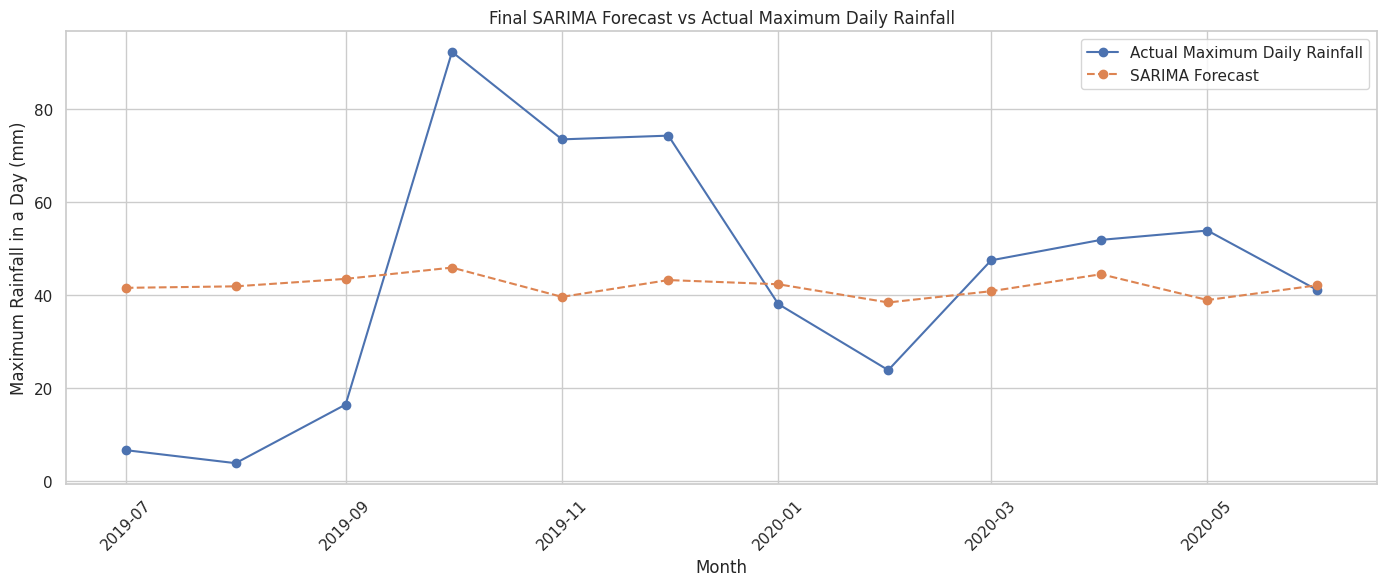

In [199]:
# ---------------------------------------------------------
# STEP 18.9: Final Test Forecast Plot
# ---------------------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    max_final_test.index,
    max_final_test.values,
    marker="o",
    label="Actual Maximum Daily Rainfall"
)

plt.plot(
    max_test_pred.index,
    max_test_pred.values,
    marker="o",
    linestyle="--",
    label="SARIMA Forecast"
)

plt.title(
    "Final SARIMA Forecast vs Actual Maximum Daily Rainfall"
)

plt.xlabel("Month")
plt.ylabel(
    "Maximum Rainfall in a Day (mm)"
)

plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

In [200]:
# ---------------------------------------------------------
# STEP 18.10: 95% Forecast Intervals
# ---------------------------------------------------------

max_test_ci = (
    max_test_forecast_result
    .conf_int(alpha=0.05)
)

max_test_ci.index = max_final_test.index

display(
    max_test_ci.round(2)
)

,lower maximum_rainfall_in_a_day,upper maximum_rainfall_in_a_day
month,,
2019-07-01,-35.97,118.95
2019-08-01,-35.66,119.28
2019-09-01,-34.06,120.89
2019-10-01,-31.64,123.32
2019-11-01,-37.94,117.03
2019-12-01,-34.33,120.65
2020-01-01,-35.24,119.75
2020-02-01,-39.16,115.85
2020-03-01,-36.74,118.27


In [201]:
# ---------------------------------------------------------
# STEP 18.11: Forecast Interval Coverage
# ---------------------------------------------------------

max_lower = max_test_ci.iloc[:, 0]
max_upper = max_test_ci.iloc[:, 1]

max_inside_interval = (
    (max_final_test >= max_lower) &
    (max_final_test <= max_upper)
)

max_coverage_percentage = (
    max_inside_interval.mean() * 100
)

max_interval_check = pd.DataFrame({
    "Actual_Max_Daily": max_final_test,
    "Lower_95": max_lower,
    "Upper_95": max_upper,
    "Inside_Interval": max_inside_interval
})

display(
    max_interval_check.round(2)
)

print(
    "\nPercentage inside 95% forecast interval:"
)

print(
    f"{max_coverage_percentage:.2f}%"
)

,Actual_Max_Daily,Lower_95,Upper_95,Inside_Interval
month,,,,
2019-07-01,6.6,-35.97,118.95,True
2019-08-01,3.8,-35.66,119.28,True
2019-09-01,16.4,-34.06,120.89,True
2019-10-01,92.2,-31.64,123.32,True
2019-11-01,73.4,-37.94,117.03,True
2019-12-01,74.2,-34.33,120.65,True
2020-01-01,38.0,-35.24,119.75,True
2020-02-01,23.8,-39.16,115.85,True
2020-03-01,47.4,-36.74,118.27,True



Percentage inside 95% forecast interval:
100.00%


Final Test Evaluation — Maximum Daily Rainfall

The selected SARIMA(1,0,1)(1,0,0)₁₂ model was refitted using 450 monthly observations from January 1982 through June 2019 and evaluated on the untouched 12-month test period from July 2019 through June 2020. The chronological split contained no overlap or missing observations, preserving temporal integrity.

The model achieved a test MAE of 21.66 mm and RMSE of 26.15 mm, compared with validation values of 14.74 mm and 17.15 mm respectively. The deterioration on the unseen test period indicates reduced generalization during months containing unusual rainfall-intensity patterns.

Month-level error analysis showed that June 2020 was predicted most accurately, with an absolute error of only 1.04 mm, while October 2019 produced the largest error of 46.36 mm. The model tended to produce relatively smooth forecasts and therefore had difficulty anticipating abrupt low and high maximum-daily rainfall events.

All 12 test observations fell within the model's nominal 95% forecast intervals, giving observed test coverage of 100%. However, these intervals were wide and sometimes had statistically negative lower bounds, reflecting substantial uncertainty. Since rainfall cannot be negative, such lower bounds should be interpreted practically as zero. Overall, SARIMA captured the general temporal structure but remained limited in forecasting extreme single-day rainfall events.

# Step 19 — Final 12-Month Forecast for Maximum Daily Rainfall

### Final forecasting stage for Business Objective 2.

In [202]:
# ---------------------------------------------------------
# STEP 19.1: Prepare Full Historical Series
# ---------------------------------------------------------

max_business_series = (
    df_ts["maximum_rainfall_in_a_day"]
    .copy()
    .asfreq("MS")
)

print("Total historical observations:",
      len(max_business_series))

print("\nHistorical period:")
print(
    max_business_series.index.min(),
    "to",
    max_business_series.index.max()
)

print("\nMissing values:")
print(max_business_series.isnull().sum())

print("\nChronologically sorted:")
print(
    max_business_series.index.is_monotonic_increasing
)

print("\nFrequency:")
print(max_business_series.index.freq)

Total historical observations: 462

Historical period:
1982-01-01 00:00:00 to 2020-06-01 00:00:00

Missing values:
0

Chronologically sorted:
True

Frequency:
<MonthBegin>


In [203]:
# ---------------------------------------------------------
# STEP 19.2: Fit Final Business SARIMA Model
# ---------------------------------------------------------

max_business_model = SARIMAX(
    max_business_series,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 0, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

max_business_fit = max_business_model.fit(
    disp=False
)

print(
    "Final maximum-daily rainfall model fitted successfully."
)

print("\nModel:")
print("SARIMA(1,0,1)(1,0,0,12)")

print("\nHistorical observations used:")
print(len(max_business_series))

print("\nModel AIC:")
print(
    round(max_business_fit.aic, 2)
)

Final maximum-daily rainfall model fitted successfully.

Model:
SARIMA(1,0,1)(1,0,0,12)

Historical observations used:
462

Model AIC:
4485.13


In [204]:
# ---------------------------------------------------------
# STEP 19.3: Generate 12-Month Future Forecast
# ---------------------------------------------------------

max_future_result = (
    max_business_fit.get_forecast(
        steps=12
    )
)

max_future_pred = (
    max_future_result.predicted_mean
)

print("Forecast dates:")
print(max_future_pred.index)

print(
    "\nNumber of future forecasts:",
    len(max_future_pred)
)

Forecast dates:
DatetimeIndex(['2020-07-01', '2020-08-01', '2020-09-01', '2020-10-01',
               '2020-11-01', '2020-12-01', '2021-01-01', '2021-02-01',
               '2021-03-01', '2021-04-01', '2021-05-01', '2021-06-01'],
              dtype='datetime64[ns]', freq='MS')

Number of future forecasts: 12


In [205]:
# ---------------------------------------------------------
# STEP 19.4: Obtain 95% Forecast Intervals
# ---------------------------------------------------------

max_future_ci = (
    max_future_result
    .conf_int(alpha=0.05)
)

display(
    max_future_ci.round(2)
)

,lower maximum_rainfall_in_a_day,upper maximum_rainfall_in_a_day
2020-07-01,-30.09,108.04
2020-08-01,-30.57,107.57
2020-09-01,-28.55,109.59
2020-10-01,-16.28,121.85
2020-11-01,-19.35,118.79
2020-12-01,-19.25,118.90
2021-01-01,-25.14,113.01
2021-02-01,-27.46,110.69
2021-03-01,-23.66,114.50
2021-04-01,-22.97,115.19


In [206]:
# ---------------------------------------------------------
# STEP 19.5: Final Maximum-Daily Forecast Table
# ---------------------------------------------------------

max_future_table = pd.DataFrame({
    "Forecast_Max_Daily_Rainfall_mm":
        max_future_pred,

    "Lower_95_mm":
        max_future_ci.iloc[:, 0],

    "Upper_95_mm":
        max_future_ci.iloc[:, 1]
})

# Rainfall cannot physically be negative
max_future_table[
    "Lower_95_Practical_mm"
] = (
    max_future_table["Lower_95_mm"]
    .clip(lower=0)
)

display(
    max_future_table.round(2)
)

,Forecast_Max_Daily_Rainfall_mm,Lower_95_mm,Upper_95_mm,Lower_95_Practical_mm
2020-07-01,38.97,-30.09,108.04,0.0
2020-08-01,38.50,-30.57,107.57,0.0
2020-09-01,40.52,-28.55,109.59,0.0
2020-10-01,52.79,-16.28,121.85,0.0
2020-11-01,49.72,-19.35,118.79,0.0
2020-12-01,49.83,-19.25,118.90,0.0
2021-01-01,43.94,-25.14,113.01,0.0
2021-02-01,41.61,-27.46,110.69,0.0
2021-03-01,45.42,-23.66,114.50,0.0
2021-04-01,46.11,-22.97,115.19,0.0


In [207]:
# ---------------------------------------------------------
# STEP 19.6: Identify Forecast Highest Maximum-Daily Rainfall
# ---------------------------------------------------------

forecast_highest_month = (
    max_future_pred.idxmax()
)

forecast_highest_value = (
    max_future_pred.max()
)

print(
    "Forecast month with highest maximum-daily rainfall:"
)

print(
    forecast_highest_month
)

print(
    "\nForecast maximum rainfall in a day:"
)

print(
    f"{forecast_highest_value:.2f} mm"
)

Forecast month with highest maximum-daily rainfall:
2020-10-01 00:00:00

Forecast maximum rainfall in a day:
52.79 mm


In [208]:
# ---------------------------------------------------------
# STEP 19.7: Identify Lowest Forecast Month
# ---------------------------------------------------------

forecast_lowest_month = (
    max_future_pred.idxmin()
)

forecast_lowest_value = (
    max_future_pred.min()
)

print(
    "Forecast month with lowest maximum-daily rainfall:"
)

print(
    forecast_lowest_month
)

print(
    "\nForecast maximum rainfall in a day:"
)

print(
    f"{forecast_lowest_value:.2f} mm"
)

Forecast month with lowest maximum-daily rainfall:
2020-08-01 00:00:00

Forecast maximum rainfall in a day:
38.50 mm


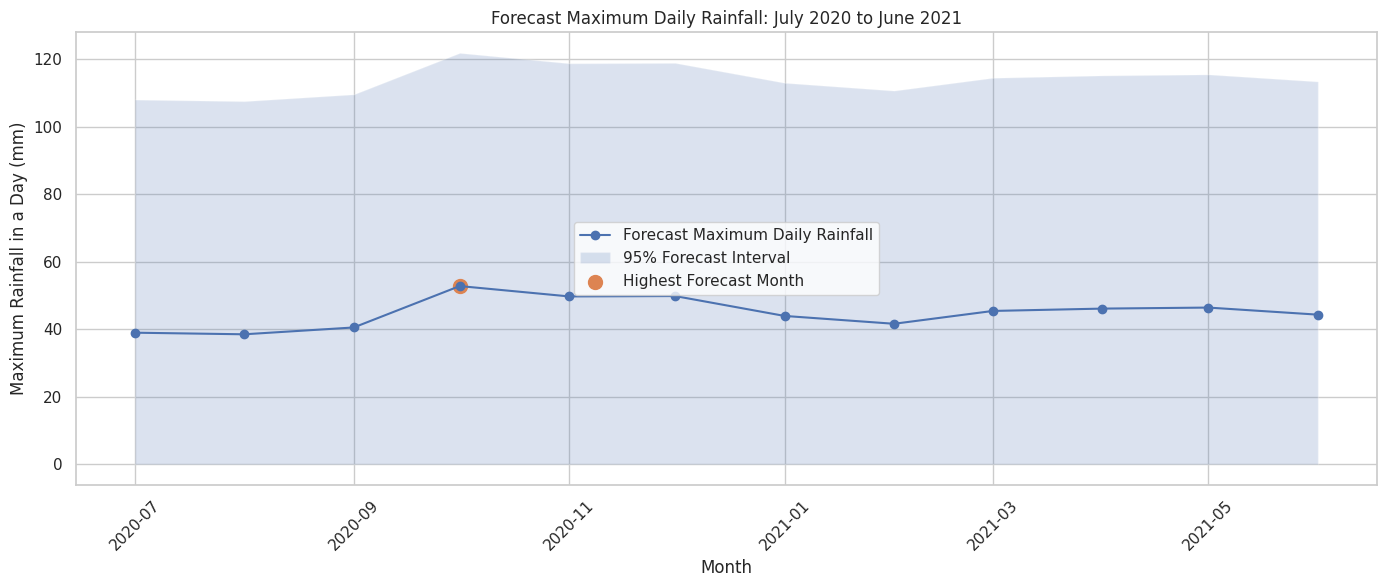

In [209]:
# ---------------------------------------------------------
# STEP 19.8: Future Maximum-Daily Rainfall Forecast
# ---------------------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    max_future_pred.index,
    max_future_pred.values,
    marker="o",
    label="Forecast Maximum Daily Rainfall"
)

plt.fill_between(
    max_future_pred.index,
    max_future_table["Lower_95_Practical_mm"],
    max_future_table["Upper_95_mm"],
    alpha=0.2,
    label="95% Forecast Interval"
)

plt.scatter(
    forecast_highest_month,
    forecast_highest_value,
    s=100,
    label="Highest Forecast Month"
)

plt.title(
    "Forecast Maximum Daily Rainfall: July 2020 to June 2021"
)

plt.xlabel("Month")

plt.ylabel(
    "Maximum Rainfall in a Day (mm)"
)

plt.xticks(rotation=45)

plt.legend()

plt.tight_layout()

plt.show()

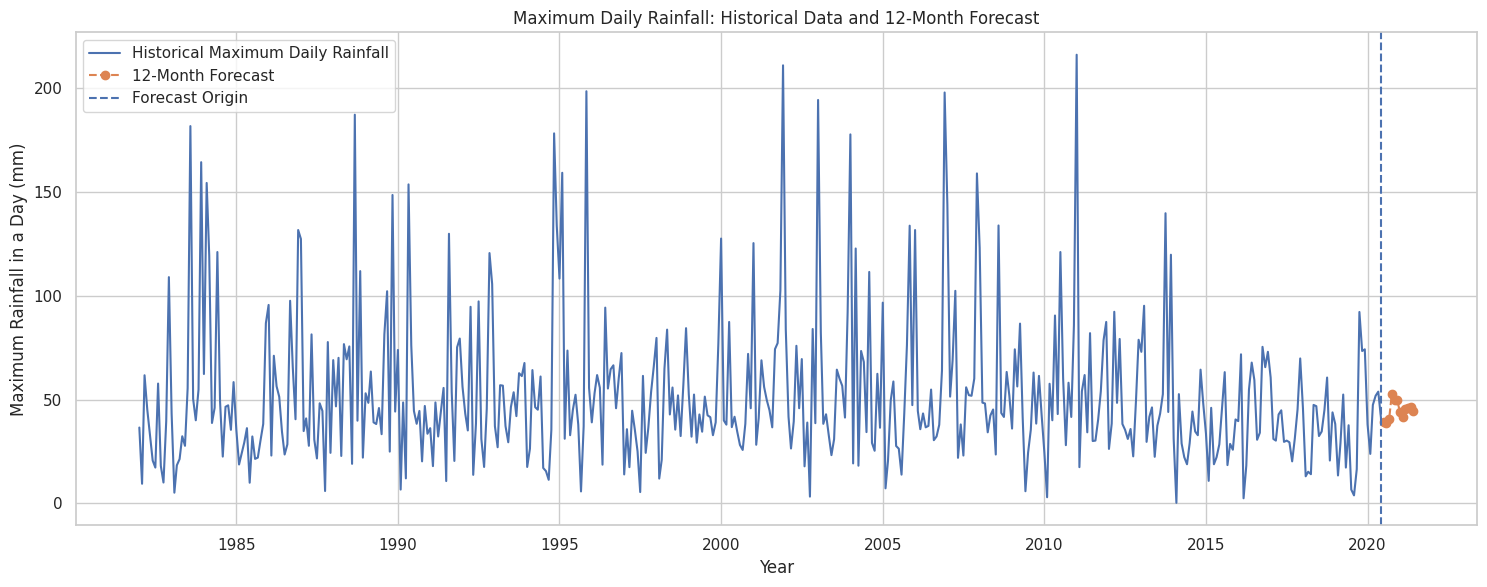

In [210]:
# ---------------------------------------------------------
# STEP 19.9: Historical Series + Future Forecast
# ---------------------------------------------------------

plt.figure(figsize=(15, 6))

plt.plot(
    max_business_series.index,
    max_business_series.values,
    label="Historical Maximum Daily Rainfall"
)

plt.plot(
    max_future_pred.index,
    max_future_pred.values,
    marker="o",
    linestyle="--",
    label="12-Month Forecast"
)

plt.axvline(
    x=max_business_series.index.max(),
    linestyle="--",
    label="Forecast Origin"
)

plt.title(
    "Maximum Daily Rainfall: Historical Data and 12-Month Forecast"
)

plt.xlabel("Year")

plt.ylabel(
    "Maximum Rainfall in a Day (mm)"
)

plt.legend()

plt.tight_layout()

plt.show()

In [211]:
# ---------------------------------------------------------
# STEP 19.10: Forecast vs Historical Monthly Average
# ---------------------------------------------------------

historical_monthly_max_avg = (
    max_business_series
    .groupby(
        max_business_series.index.month
    )
    .mean()
)

comparison_rows = []

for date, forecast_value in max_future_pred.items():

    month_number = date.month

    historical_average = (
        historical_monthly_max_avg.loc[
            month_number
        ]
    )

    comparison_rows.append({
        "Forecast_Month": date,
        "Forecast_Max_Daily_mm":
            forecast_value,
        "Historical_Month_Average_mm":
            historical_average,
        "Difference_mm":
            forecast_value -
            historical_average
    })

max_historical_comparison = pd.DataFrame(
    comparison_rows
).set_index("Forecast_Month")

display(
    max_historical_comparison.round(2)
)

,Forecast_Max_Daily_mm,Historical_Month_Average_mm,Difference_mm
Forecast_Month,,,
2020-07-01,38.97,40.46,-1.49
2020-08-01,38.50,49.18,-10.68
2020-09-01,40.52,45.13,-4.61
2020-10-01,52.79,44.06,8.73
2020-11-01,49.72,70.83,-21.11
2020-12-01,49.83,80.53,-30.70
2021-01-01,43.94,74.46,-30.53
2021-02-01,41.61,38.68,2.94
2021-03-01,45.42,47.64,-2.22


In [212]:
# ---------------------------------------------------------
# STEP 19.11: Final Business Objective 2 Answer
# ---------------------------------------------------------

print("=" * 65)

print(
    "BUSINESS OBJECTIVE 2 — FINAL FORECAST"
)

print("=" * 65)

print(
    "\nForecast period:"
)

print(
    max_future_pred.index.min(),
    "to",
    max_future_pred.index.max()
)

print(
    "\nMonth predicted to have the highest"
    " maximum-daily rainfall:"
)

print(
    forecast_highest_month.strftime(
        "%B %Y"
    )
)

print(
    "\nPredicted maximum rainfall occurring"
    " in a single day:"
)

print(
    f"{forecast_highest_value:.2f} mm"
)

print("=" * 65)

BUSINESS OBJECTIVE 2 — FINAL FORECAST

Forecast period:
2020-07-01 00:00:00 to 2021-06-01 00:00:00

Month predicted to have the highest maximum-daily rainfall:
October 2020

Predicted maximum rainfall occurring in a single day:
52.79 mm


# Business Objective 2 — Final Answer

Using the selected SARIMA(1,0,1)(1,0,0)₁₂ model trained on all 462 historical monthly observations from January 1982 to June 2020, maximum daily rainfall was forecast for the next 12 months from July 2020 through June 2021. Among these months, October 2020 was predicted to have the highest maximum rainfall occurring within a single day, with a point forecast of approximately 52.79 mm. Because the forecast interval is wide and historical test analysis showed difficulty predicting extreme rainfall events, this value should be interpreted as an estimated central forecast rather than an exact future rainfall amount.

Final 12-Month Maximum Daily Rainfall Forecast

The selected SARIMA(1,0,1)(1,0,0)₁₂ model was refitted using all 462 monthly observations from January 1982 to June 2020 and used to forecast maximum daily rainfall for July 2020 through June 2021.

The forecast values ranged from 38.50 mm to 52.79 mm. October 2020 was identified as the month with the highest predicted maximum-daily rainfall, with an estimated value of 52.79 mm, while August 2020 had the lowest forecast at 38.50 mm.

Comparison with historical calendar-month averages showed that the October 2020 forecast was 8.73 mm above the historical October average, whereas forecasts for historically high-intensity months such as December and January were below their long-term averages.

The 95% forecast intervals were wide and several statistical lower bounds were negative. Since rainfall cannot be negative, these were additionally represented with practical lower bounds of zero. The wide intervals reflect substantial uncertainty associated with forecasting extreme daily rainfall from monthly historical data.

Overall, the model provides a useful estimate of the expected maximum-daily rainfall pattern, but the result should be interpreted with caution because extreme rainfall events remain difficult to predict precisely.

# Step 20 — Final Model Evaluation, Error Analysis and Business Summary

In [213]:
# ---------------------------------------------------------
# STEP 20.1: Final Validation Model Comparison
# Objective 1 - Monthly Total Rainfall
# ---------------------------------------------------------

total_model_comparison = pd.DataFrame({
    "Model": [
        "SARIMA",
        "Naive",
        "Tuned Gradient Boosting",
        "Initial Gradient Boosting",
        "Initial Random Forest",
        "Tuned Random Forest",
        "Seasonal Naive"
    ],

    "MAE_mm": [
        52.39,
        60.33,
        69.44,
        76.54,
        69.63,
        71.67,
        82.13
    ],

    "RMSE_mm": [
        66.33,
        77.39,
        85.77,
        89.84,
        91.23,
        91.92,
        106.43
    ]
})

total_model_comparison = (
    total_model_comparison
    .sort_values("RMSE_mm")
    .reset_index(drop=True)
)

display(total_model_comparison)

,Model,MAE_mm,RMSE_mm
0,SARIMA,52.39,66.33
1,Naive,60.33,77.39
2,Tuned Gradient Boosting,69.44,85.77
3,Initial Gradient Boosting,76.54,89.84
4,Initial Random Forest,69.63,91.23
5,Tuned Random Forest,71.67,91.92
6,Seasonal Naive,82.13,106.43


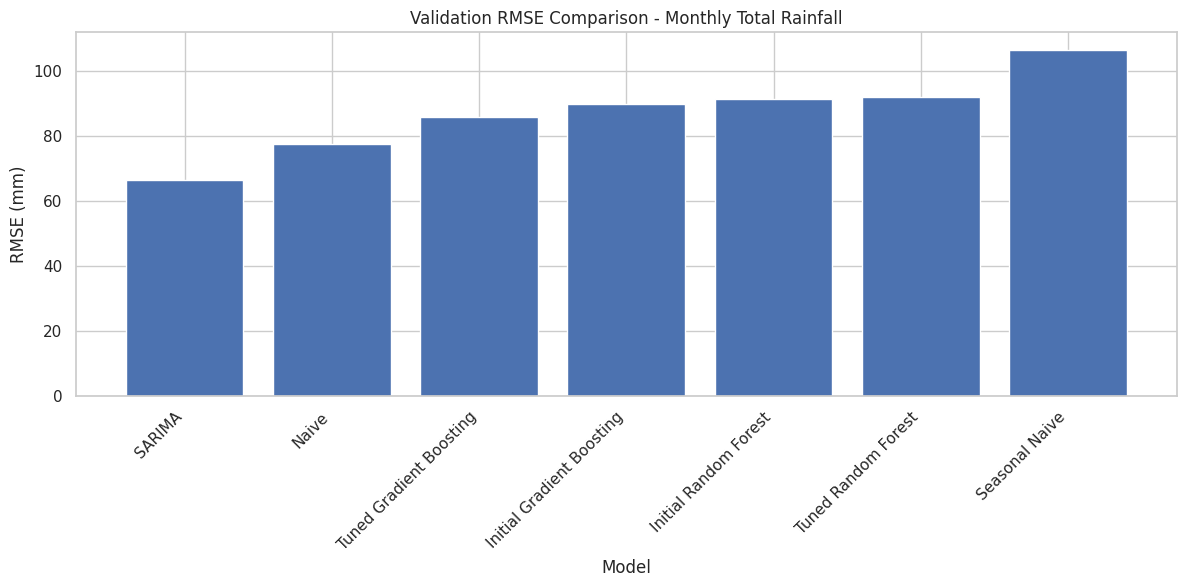

In [214]:
# ---------------------------------------------------------
# STEP 20.2: Validation RMSE Comparison
# ---------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.bar(
    total_model_comparison["Model"],
    total_model_comparison["RMSE_mm"]
)

plt.title(
    "Validation RMSE Comparison - Monthly Total Rainfall"
)

plt.xlabel("Model")
plt.ylabel("RMSE (mm)")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

In [215]:
# ---------------------------------------------------------
# STEP 20.3: SARIMA Improvement Over Baselines
# ---------------------------------------------------------

sarima_total_rmse = 66.33

naive_total_rmse = 77.39

seasonal_naive_total_rmse = 106.43

improvement_vs_naive = (
    (naive_total_rmse - sarima_total_rmse)
    / naive_total_rmse
) * 100

improvement_vs_seasonal = (
    (seasonal_naive_total_rmse - sarima_total_rmse)
    / seasonal_naive_total_rmse
) * 100

print(
    "SARIMA RMSE improvement over Naive:"
)

print(
    f"{improvement_vs_naive:.2f}%"
)

print(
    "\nSARIMA RMSE improvement over Seasonal Naive:"
)

print(
    f"{improvement_vs_seasonal:.2f}%"
)

SARIMA RMSE improvement over Naive:
14.29%

SARIMA RMSE improvement over Seasonal Naive:
37.68%


In [216]:
# ---------------------------------------------------------
# STEP 20.4: Validation vs Test - Total Rainfall
# ---------------------------------------------------------

total_generalization = pd.DataFrame({
    "Dataset": [
        "Validation",
        "Final Test"
    ],

    "MAE_mm": [
        52.39,
        89.47
    ],

    "RMSE_mm": [
        66.33,
        112.93
    ]
})

display(total_generalization)

mae_increase_total = (
    (89.47 - 52.39) / 52.39
) * 100

rmse_increase_total = (
    (112.93 - 66.33) / 66.33
) * 100

print(
    "\nMAE increase from validation to test:"
)

print(
    f"{mae_increase_total:.2f}%"
)

print(
    "\nRMSE increase from validation to test:"
)

print(
    f"{rmse_increase_total:.2f}%"
)

,Dataset,MAE_mm,RMSE_mm
0,Validation,52.39,66.33
1,Final Test,89.47,112.93



MAE increase from validation to test:
70.78%

RMSE increase from validation to test:
70.25%


In [217]:
# ---------------------------------------------------------
# STEP 20.5: Total Rainfall Test Error Analysis
# ---------------------------------------------------------

total_test_actual = pd.Series(
    [
        12.2, 11.8, 22.8, 176.8,
        137.4, 421.5, 88.4, 65.0,
        108.8, 188.0, 255.6, 233.8
    ],
    index=pd.date_range(
        "2019-07-01",
        periods=12,
        freq="MS"
    )
)

total_test_forecast = pd.Series(
    [
        161.05, 155.52, 161.29, 184.15,
        167.63, 168.35, 140.58, 132.40,
        142.69, 168.77, 141.81, 168.44
    ],
    index=total_test_actual.index
)

total_error_analysis = pd.DataFrame({
    "Actual": total_test_actual,
    "Forecast": total_test_forecast
})

total_error_analysis["Error"] = (
    total_error_analysis["Actual"]
    - total_error_analysis["Forecast"]
)

total_error_analysis["Absolute_Error"] = (
    total_error_analysis["Error"].abs()
)

total_error_analysis["Direction"] = np.where(
    total_error_analysis["Error"] > 0,
    "Underprediction",
    "Overprediction"
)

display(
    total_error_analysis.round(2)
)

print("\nNumber of underpredictions:")
print(
    (
        total_error_analysis["Direction"]
        == "Underprediction"
    ).sum()
)

print("\nNumber of overpredictions:")
print(
    (
        total_error_analysis["Direction"]
        == "Overprediction"
    ).sum()
)

print("\nMean signed error:")
print(
    round(
        total_error_analysis["Error"].mean(),
        2
    ),
    "mm"
)

,Actual,Forecast,Error,Absolute_Error,Direction
2019-07-01,12.2,161.05,-148.85,148.85,Overprediction
2019-08-01,11.8,155.52,-143.72,143.72,Overprediction
2019-09-01,22.8,161.29,-138.49,138.49,Overprediction
2019-10-01,176.8,184.15,-7.35,7.35,Overprediction
2019-11-01,137.4,167.63,-30.23,30.23,Overprediction
2019-12-01,421.5,168.35,253.15,253.15,Underprediction
2020-01-01,88.4,140.58,-52.18,52.18,Overprediction
2020-02-01,65.0,132.40,-67.40,67.40,Overprediction
2020-03-01,108.8,142.69,-33.89,33.89,Overprediction
2020-04-01,188.0,168.77,19.23,19.23,Underprediction



Number of underpredictions:
4

Number of overpredictions:
8

Mean signed error:
-14.22 mm


In [218]:
# ---------------------------------------------------------
# STEP 20.6: Objective 2 Model Comparison
# ---------------------------------------------------------

max_daily_model_comparison = pd.DataFrame({
    "Model": [
        "SARIMA",
        "Naive",
        "Seasonal Naive"
    ],

    "MAE_mm": [
        14.74,
        14.63,
        17.65
    ],

    "RMSE_mm": [
        17.15,
        17.66,
        21.43
    ]
})

max_daily_model_comparison = (
    max_daily_model_comparison
    .sort_values("RMSE_mm")
    .reset_index(drop=True)
)

display(max_daily_model_comparison)

,Model,MAE_mm,RMSE_mm
0,SARIMA,14.74,17.15
1,Naive,14.63,17.66
2,Seasonal Naive,17.65,21.43


In [219]:
# ---------------------------------------------------------
# STEP 20.7: SARIMA Improvement - Maximum Daily Rainfall
# ---------------------------------------------------------

sarima_max_rmse = 17.15
naive_max_rmse = 17.66
seasonal_max_rmse = 21.43

max_improvement_naive = (
    (naive_max_rmse - sarima_max_rmse)
    / naive_max_rmse
) * 100

max_improvement_seasonal = (
    (seasonal_max_rmse - sarima_max_rmse)
    / seasonal_max_rmse
) * 100

print(
    "SARIMA RMSE improvement over Naive:"
)

print(
    f"{max_improvement_naive:.2f}%"
)

print(
    "\nSARIMA RMSE improvement over Seasonal Naive:"
)

print(
    f"{max_improvement_seasonal:.2f}%"
)

SARIMA RMSE improvement over Naive:
2.89%

SARIMA RMSE improvement over Seasonal Naive:
19.97%


In [220]:
# ---------------------------------------------------------
# STEP 20.8: Validation vs Test - Maximum Daily Rainfall
# ---------------------------------------------------------

max_daily_generalization = pd.DataFrame({
    "Dataset": [
        "Validation",
        "Final Test"
    ],

    "MAE_mm": [
        14.74,
        21.66
    ],

    "RMSE_mm": [
        17.15,
        26.15
    ]
})

display(max_daily_generalization)

max_mae_increase = (
    (21.66 - 14.74) / 14.74
) * 100

max_rmse_increase = (
    (26.15 - 17.15) / 17.15
) * 100

print(
    "\nMAE increase from validation to test:"
)

print(
    f"{max_mae_increase:.2f}%"
)

print(
    "\nRMSE increase from validation to test:"
)

print(
    f"{max_rmse_increase:.2f}%"
)

,Dataset,MAE_mm,RMSE_mm
0,Validation,14.74,17.15
1,Final Test,21.66,26.15



MAE increase from validation to test:
46.95%

RMSE increase from validation to test:
52.48%


In [221]:
# ---------------------------------------------------------
# STEP 20.9: Final Business Forecast Summary
# ---------------------------------------------------------

business_summary = pd.DataFrame({
    "Business_Objective": [
        "Next 12-Month Total Rainfall Forecast",
        "Highest Maximum-Daily Rainfall Forecast"
    ],

    "Forecast_Period": [
        "Jul 2020 - Jun 2021",
        "Jul 2020 - Jun 2021"
    ],

    "Key_Result": [
        "1908.60 mm forecast total across 12 months",
        "October 2020"
    ],

    "Additional_Result": [
        "December 2020 highest monthly total forecast: 230.88 mm",
        "52.79 mm predicted maximum rainfall in a day"
    ]
})

display(business_summary)

,Business_Objective,Forecast_Period,Key_Result,Additional_Result
0,Next 12-Month Total Rainfall Forecast,Jul 2020 - Jun 2021,1908.60 mm forecast total across 12 months,December 2020 highest monthly total forecast: ...
1,Highest Maximum-Daily Rainfall Forecast,Jul 2020 - Jun 2021,October 2020,52.79 mm predicted maximum rainfall in a day


In [222]:
# ---------------------------------------------------------
# STEP 20.11: Compare Future Forecast Patterns
# ---------------------------------------------------------

future_total = pd.Series(
    [
        125.35, 125.21, 128.01, 167.75,
        157.53, 230.88, 144.79, 138.71,
        149.98, 170.40, 187.82, 182.15
    ],
    index=pd.date_range(
        "2020-07-01",
        periods=12,
        freq="MS"
    )
)

future_max_daily = pd.Series(
    [
        38.97, 38.50, 40.52, 52.79,
        49.72, 49.83, 43.94, 41.61,
        45.42, 46.11, 46.41, 44.32
    ],
    index=future_total.index
)

forecast_comparison = pd.DataFrame({
    "Monthly_Total_Rainfall_mm":
        future_total,

    "Maximum_Daily_Rainfall_mm":
        future_max_daily
})

display(forecast_comparison.round(2))

,Monthly_Total_Rainfall_mm,Maximum_Daily_Rainfall_mm
2020-07-01,125.35,38.97
2020-08-01,125.21,38.50
2020-09-01,128.01,40.52
2020-10-01,167.75,52.79
2020-11-01,157.53,49.72
2020-12-01,230.88,49.83
2021-01-01,144.79,43.94
2021-02-01,138.71,41.61
2021-03-01,149.98,45.42
2021-04-01,170.40,46.11


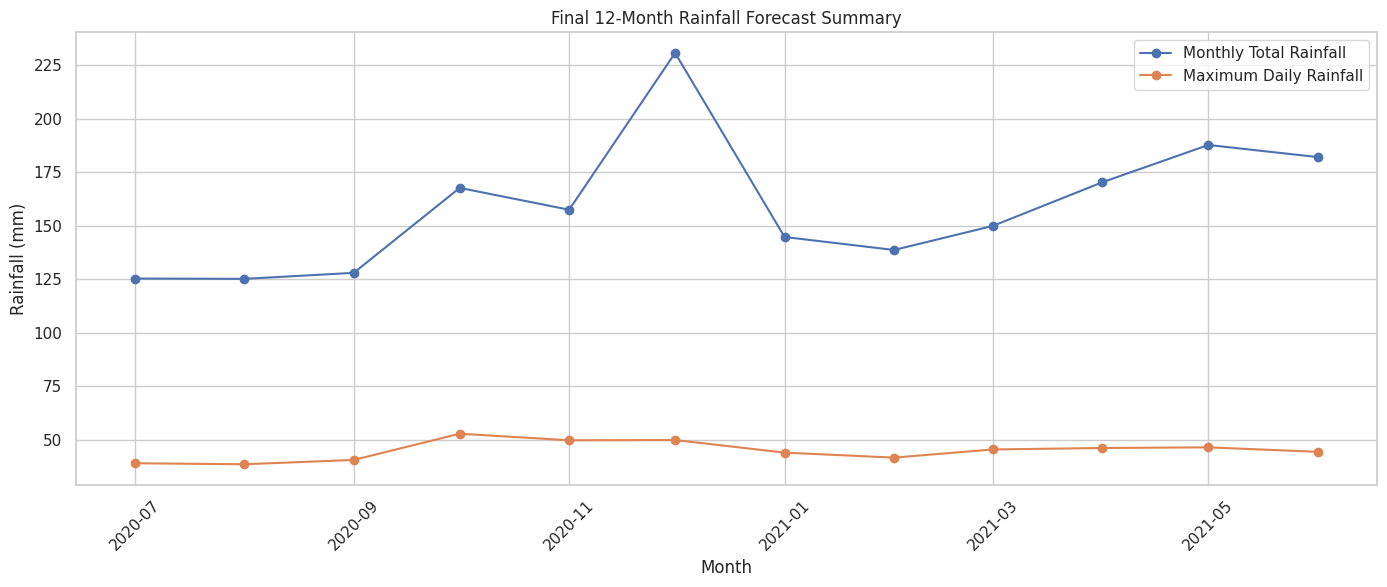

In [223]:
# ---------------------------------------------------------
# STEP 20.11B: Final Forecast Comparison Plot
# ---------------------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    forecast_comparison.index,
    forecast_comparison[
        "Monthly_Total_Rainfall_mm"
    ],
    marker="o",
    label="Monthly Total Rainfall"
)

plt.plot(
    forecast_comparison.index,
    forecast_comparison[
        "Maximum_Daily_Rainfall_mm"
    ],
    marker="o",
    label="Maximum Daily Rainfall"
)

plt.title(
    "Final 12-Month Rainfall Forecast Summary"
)

plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")

plt.xticks(rotation=45)

plt.legend()

plt.tight_layout()
plt.show()

## Project Limitations

1. **Extreme rainfall is difficult to predict:**  
   Both rainfall series contain irregular extreme events. The SARIMA models capture regular temporal and seasonal patterns but tend to smooth sudden rainfall spikes.

2. **Generalization performance decreased on the final test period:**  
   For monthly total rainfall, test MAE and RMSE increased substantially compared with validation performance. Maximum-daily rainfall also showed weaker performance on the unseen test period.

3. **Wide forecast intervals:**  
   The 95% forecast intervals were broad, reflecting substantial uncertainty. Some statistical lower bounds were negative even though rainfall cannot physically be negative.

4. **Limited explanatory variables:**  
   The forecasting models primarily use historical rainfall patterns. Additional meteorological variables such as temperature, humidity, wind, atmospheric pressure and climate indicators could potentially improve forecasting performance.

5. **Small monthly dataset:**  
   Although the dataset covers more than 38 years, it contains only 462 monthly observations. This limits the amount of information available for complex machine-learning or deep-learning models.

6. **Extreme-event forecasting limitation:**  
   Forecasting the maximum rainfall occurring within a day is particularly challenging because rare extreme events may not follow regular historical temporal patterns.

7. **Monthly temporal resolution:**  
   The maximum-daily dataset reports the highest daily rainfall value within each month but does not provide the exact future day on which that rainfall will occur.

## Future Improvements

Future work could improve forecasting performance by:

- incorporating additional meteorological variables such as humidity, temperature, wind speed and atmospheric pressure;
- including large-scale climate indicators where available;
- testing additional statistical and machine-learning forecasting approaches;
- applying rolling-origin or walk-forward validation across multiple historical forecast windows;
- experimenting with transformations or distributions better suited to non-negative and right-skewed rainfall data;
- developing specialized extreme-event forecasting methods;
- evaluating prediction-interval calibration across multiple forecast windows rather than a single 12-month test period;
- using daily rainfall data when available to model extreme rainfall events at a finer temporal resolution.

# Final Project Conclusion

This project developed and evaluated time-series forecasting models for rainfall using monthly historical observations from January 1982 to June 2020.

Exploratory analysis identified substantial month-to-month variability, right-skewed rainfall distributions, extreme rainfall events and a recurring annual seasonal structure. Seasonal decomposition, ACF, PACF and lag analysis provided additional evidence of 12-month seasonality, while ADF testing provided evidence against a unit root in both target series.

For monthly total rainfall, multiple approaches were evaluated, including naive and seasonal-naive baselines, Random Forest, Gradient Boosting and SARIMA. SARIMA achieved the best validation performance with an MAE of 52.39 mm and RMSE of 66.33 mm. However, performance deteriorated on the untouched final test period to an MAE of 89.47 mm and RMSE of 112.93 mm, mainly because of unusual rainfall patterns and extreme events.

The final monthly-total SARIMA model was refitted using all available historical observations and forecast rainfall for July 2020 through June 2021. The forecast total across the 12-month period was approximately 1908.60 mm, with December 2020 having the highest predicted monthly total rainfall at 230.88 mm.

For maximum daily rainfall, naive, seasonal-naive and SARIMA approaches were compared. SARIMA achieved the lowest validation RMSE of 17.15 mm, although its MAE of 14.74 mm was marginally higher than the naive model's 14.63 mm. On the untouched test period, SARIMA produced an MAE of 21.66 mm and RMSE of 26.15 mm, demonstrating the greater difficulty of forecasting extreme daily rainfall.

After refitting the selected maximum-daily SARIMA model using all 462 observations, October 2020 was identified as the forecast month with the highest maximum rainfall occurring within a single day, with a point forecast of approximately 52.79 mm.

Overall, the project demonstrates that SARIMA can capture important recurring temporal and seasonal rainfall patterns and outperform the tested alternatives on the primary validation criteria. However, the deterioration observed on unseen test periods and the wide forecast intervals demonstrate that rainfall, particularly extreme rainfall, remains highly uncertain. The forecasts should therefore be interpreted as model-based estimates rather than exact future outcomes.

# Step 21 — Rolling-Origin 12-Month Robustness Evaluation

our single validation year and final test year behaved very differently, so a rolling-origin 12-month evaluation will tell us whether the selected SARIMA model performs consistently across several historical years instead of relying on only one validation window.

In [224]:
# ---------------------------------------------------------
# STEP 21.5: Rolling-Origin Evaluation Function
# ---------------------------------------------------------

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

def rolling_origin_sarima_evaluation(
    series,
    forecast_starts,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 0, 12),
    horizon=12
):

    results = []

    for forecast_start in forecast_starts:

        # Training data = everything before forecast start
        train_series = series.loc[
            series.index < forecast_start
        ].copy()

        # 12-month future evaluation block
        forecast_end = (
            forecast_start
            + pd.DateOffset(months=horizon - 1)
        )

        actual_series = series.loc[
            forecast_start:forecast_end
        ].copy()

        # Safety check
        if len(actual_series) != horizon:
            print(
                f"Skipping {forecast_start}: "
                f"only {len(actual_series)} observations available."
            )
            continue

        # Fit SARIMA
        model = SARIMAX(
            train_series,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted_model = model.fit(
            disp=False
        )

        # Genuine 12-step forecast
        forecast_values = fitted_model.forecast(
            steps=horizon
        )

        forecast_values.index = actual_series.index

        # Metrics
        mae = mean_absolute_error(
            actual_series,
            forecast_values
        )

        rmse = np.sqrt(
            mean_squared_error(
                actual_series,
                forecast_values
            )
        )

        results.append({
            "Forecast_Start": forecast_start,
            "Forecast_End": forecast_end,
            "Train_Observations": len(train_series),
            "MAE_mm": mae,
            "RMSE_mm": rmse
        })

    return pd.DataFrame(results)

In [225]:
# ---------------------------------------------------------
# STEP 21.7: Define Rolling Forecast Origins
# ---------------------------------------------------------

rolling_starts = pd.to_datetime([
    "2015-07-01",
    "2016-07-01",
    "2017-07-01",
    "2018-07-01",
    "2019-07-01"
])

print("Rolling forecast origins:")

for date in rolling_starts:
    print(date)

Rolling forecast origins:
2015-07-01 00:00:00
2016-07-01 00:00:00
2017-07-01 00:00:00
2018-07-01 00:00:00
2019-07-01 00:00:00


In [226]:
# ---------------------------------------------------------
# STEP 21.8: Rolling-Origin Evaluation
# Objective 1 - Monthly Total Rainfall
# ---------------------------------------------------------

rolling_total_results = (
    rolling_origin_sarima_evaluation(
        series=df_ts["total_rainfall"].asfreq("MS"),
        forecast_starts=rolling_starts,
        order=(1, 0, 1),
        seasonal_order=(1, 0, 0, 12),
        horizon=12
    )
)

display(
    rolling_total_results.round(2)
)

/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,Forecast_Start,Forecast_End,Train_Observations,MAE_mm,RMSE_mm
0,2015-07-01,2016-06-01,402,66.28,79.44
1,2016-07-01,2017-06-01,414,43.27,57.38
2,2017-07-01,2018-06-01,426,90.08,100.33
3,2018-07-01,2019-06-01,438,52.39,66.33
4,2019-07-01,2020-06-01,450,89.47,112.93


In [227]:
# ---------------------------------------------------------
# STEP 21.9: Total Rainfall Robustness Summary
# ---------------------------------------------------------

print("MONTHLY TOTAL RAINFALL")
print("----------------------")

print(
    "Average MAE:",
    round(
        rolling_total_results[
            "MAE_mm"
        ].mean(),
        2
    ),
    "mm"
)

print(
    "Average RMSE:",
    round(
        rolling_total_results[
            "RMSE_mm"
        ].mean(),
        2
    ),
    "mm"
)

print(
    "RMSE standard deviation:",
    round(
        rolling_total_results[
            "RMSE_mm"
        ].std(),
        2
    ),
    "mm"
)

print(
    "Best rolling RMSE:",
    round(
        rolling_total_results[
            "RMSE_mm"
        ].min(),
        2
    ),
    "mm"
)

print(
    "Worst rolling RMSE:",
    round(
        rolling_total_results[
            "RMSE_mm"
        ].max(),
        2
    ),
    "mm"
)

MONTHLY TOTAL RAINFALL
----------------------
Average MAE: 68.3 mm
Average RMSE: 83.28 mm
RMSE standard deviation: 23.14 mm
Best rolling RMSE: 57.38 mm
Worst rolling RMSE: 112.93 mm


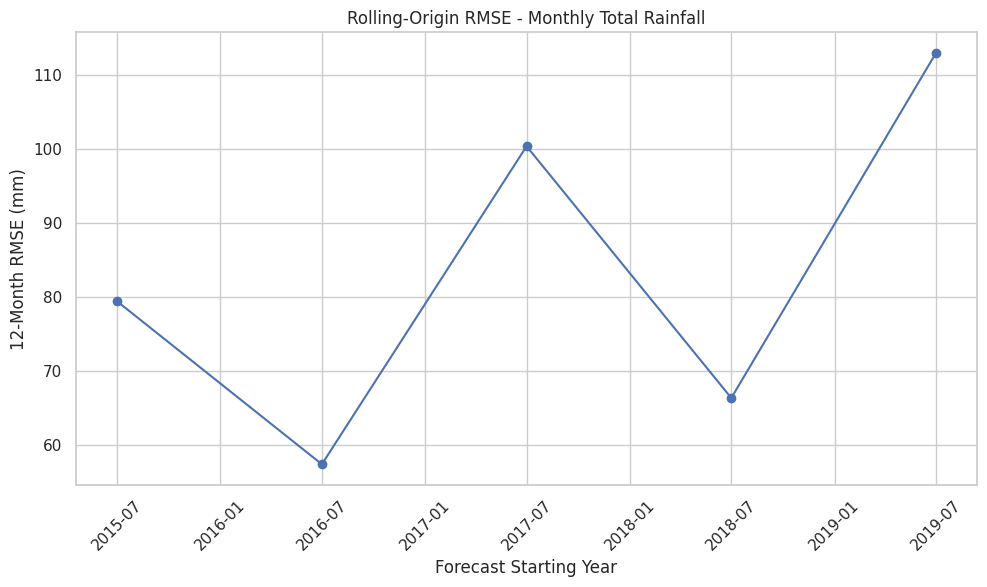

In [228]:
# ---------------------------------------------------------
# STEP 21.10: Rolling RMSE Plot
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    rolling_total_results["Forecast_Start"],
    rolling_total_results["RMSE_mm"],
    marker="o"
)

plt.title(
    "Rolling-Origin RMSE - Monthly Total Rainfall"
)

plt.xlabel("Forecast Starting Year")
plt.ylabel("12-Month RMSE (mm)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [229]:
# ---------------------------------------------------------
# STEP 21.11: Rolling-Origin Evaluation
# Objective 2 - Maximum Daily Rainfall
# ---------------------------------------------------------

rolling_max_results = (
    rolling_origin_sarima_evaluation(
        series=df_ts[
            "maximum_rainfall_in_a_day"
        ].asfreq("MS"),
        forecast_starts=rolling_starts,
        order=(1, 0, 1),
        seasonal_order=(1, 0, 0, 12),
        horizon=12
    )
)

display(
    rolling_max_results.round(2)
)

,Forecast_Start,Forecast_End,Train_Observations,MAE_mm,RMSE_mm
0,2015-07-01,2016-06-01,402,20.65,24.12
1,2016-07-01,2017-06-01,414,16.29,18.01
2,2017-07-01,2018-06-01,426,19.04,22.48
3,2018-07-01,2019-06-01,438,14.74,17.15
4,2019-07-01,2020-06-01,450,21.66,26.15


In [230]:
# ---------------------------------------------------------
# STEP 21.12: Maximum Daily Rainfall Robustness Summary
# ---------------------------------------------------------

print("MAXIMUM DAILY RAINFALL")
print("----------------------")

print(
    "Average MAE:",
    round(
        rolling_max_results[
            "MAE_mm"
        ].mean(),
        2
    ),
    "mm"
)

print(
    "Average RMSE:",
    round(
        rolling_max_results[
            "RMSE_mm"
        ].mean(),
        2
    ),
    "mm"
)

print(
    "RMSE standard deviation:",
    round(
        rolling_max_results[
            "RMSE_mm"
        ].std(),
        2
    ),
    "mm"
)

print(
    "Best rolling RMSE:",
    round(
        rolling_max_results[
            "RMSE_mm"
        ].min(),
        2
    ),
    "mm"
)

print(
    "Worst rolling RMSE:",
    round(
        rolling_max_results[
            "RMSE_mm"
        ].max(),
        2
    ),
    "mm"
)

MAXIMUM DAILY RAINFALL
----------------------
Average MAE: 18.48 mm
Average RMSE: 21.58 mm
RMSE standard deviation: 3.89 mm
Best rolling RMSE: 17.15 mm
Worst rolling RMSE: 26.15 mm


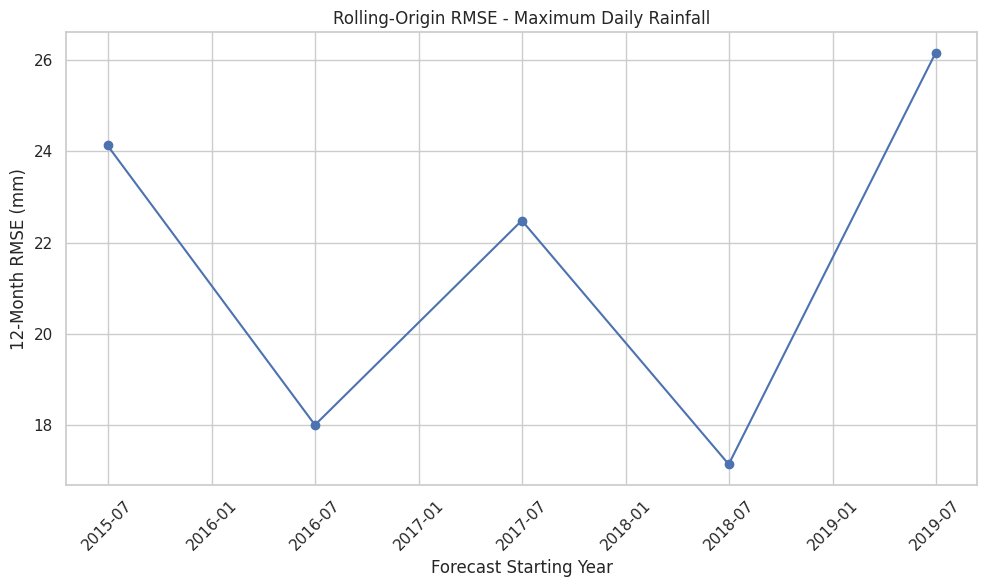

In [231]:
# ---------------------------------------------------------
# STEP 21.13: Rolling RMSE Plot
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    rolling_max_results["Forecast_Start"],
    rolling_max_results["RMSE_mm"],
    marker="o"
)

plt.title(
    "Rolling-Origin RMSE - Maximum Daily Rainfall"
)

plt.xlabel("Forecast Starting Year")
plt.ylabel("12-Month RMSE (mm)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [232]:
# ---------------------------------------------------------
# STEP 21.14: Combined Robustness Summary
# ---------------------------------------------------------

robustness_summary = pd.DataFrame({
    "Target": [
        "Monthly Total Rainfall",
        "Maximum Daily Rainfall"
    ],

    "Average_MAE_mm": [
        rolling_total_results[
            "MAE_mm"
        ].mean(),

        rolling_max_results[
            "MAE_mm"
        ].mean()
    ],

    "Average_RMSE_mm": [
        rolling_total_results[
            "RMSE_mm"
        ].mean(),

        rolling_max_results[
            "RMSE_mm"
        ].mean()
    ],

    "RMSE_Std_mm": [
        rolling_total_results[
            "RMSE_mm"
        ].std(),

        rolling_max_results[
            "RMSE_mm"
        ].std()
    ],

    "Best_RMSE_mm": [
        rolling_total_results[
            "RMSE_mm"
        ].min(),

        rolling_max_results[
            "RMSE_mm"
        ].min()
    ],

    "Worst_RMSE_mm": [
        rolling_total_results[
            "RMSE_mm"
        ].max(),

        rolling_max_results[
            "RMSE_mm"
        ].max()
    ]
})

display(
    robustness_summary.round(2)
)

,Target,Average_MAE_mm,Average_RMSE_mm,RMSE_Std_mm,Best_RMSE_mm,Worst_RMSE_mm
0,Monthly Total Rainfall,68.30,83.28,23.14,57.38,112.93
1,Maximum Daily Rainfall,18.48,21.58,3.89,17.15,26.15


Rolling-Origin Robustness Evaluation

A rolling-origin evaluation was performed to assess the robustness of the selected SARIMA models across five historical 12-month forecasting periods from July 2015–June 2016 through July 2019–June 2020. Each forecast was generated using only information available before its corresponding forecast origin, thereby preserving the chronological structure and preventing temporal leakage.

For monthly total rainfall, the average rolling MAE and RMSE were 68.30 mm and 83.28 mm, respectively. RMSE ranged from 57.38 mm to 112.93 mm, with a standard deviation of 23.14 mm, demonstrating meaningful year-to-year variation in forecast accuracy. This indicates that unusual and extreme rainfall periods remain difficult for the model to predict.

For maximum daily rainfall, the average rolling MAE and RMSE were 18.48 mm and 21.58 mm, respectively. RMSE ranged from 17.15 mm to 26.15 mm, with a standard deviation of 3.89 mm, indicating more consistent performance across the evaluated forecast periods.

Overall, rolling-origin evaluation confirms that the forecasting pipeline generalizes beyond a single validation window, while also revealing important variability in performance. Monthly total rainfall forecasts are particularly sensitive to unusual rainfall events, whereas maximum-daily rainfall forecasting showed comparatively more stable year-to-year performance. A convergence warning occurred during at least one rolling SARIMA fit and is acknowledged as a numerical modeling limitation.

# Final Project Summary:

 Historical rainfall data from January 1982 to June 2020 were analyzed using EDA, decomposition, stationarity testing, ACF/PACF, chronological validation, baseline models, machine-learning models, SARIMA, final holdout testing, and rolling-origin evaluation. SARIMA(1,0,1)(1,0,0,12) provided the strongest validation performance for monthly total rainfall (MAE 52.39 mm, RMSE 66.33 mm). The final July 2020–June 2021 forecast estimated 1908.60 mm total rainfall, with December 2020 having the highest monthly forecast (230.88 mm). For maximum daily rainfall, October 2020 was forecast to have the highest single-day maximum (52.79 mm). Rolling-origin evaluation showed that monthly-total forecast accuracy varies substantially across years, while maximum-daily forecasts were comparatively more stable. Extreme rainfall and wide uncertainty intervals remain key limitations.